In [2]:
import os

project_dir = '/blue/shenhaowang/qingqisong/be-and-active-travel'
os.chdir(project_dir)

In [3]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Device: {torch.cuda.get_device_name(0)}")

# Check if torch.amp has the required functions
try:
    from torch.amp import custom_fwd, custom_bwd
    print("✓ torch.amp.custom_fwd available")
except ImportError as e:
    print(f"✗ torch.amp functions not available: {e}")

PyTorch version: 2.7.1+cu128
CUDA available: True
CUDA version: 12.8
Device: NVIDIA L4
✓ torch.amp.custom_fwd available


In [4]:
import os
import sys



project_dir = '/blue/shenhaowang/qingqisong/be-and-active-travel'
os.chdir(project_dir)

# ============================================================================
# IMPORTS
# ============================================================================

import torch
print(f"PyTorch version: {torch.__version__}")

import torch.utils._pytree
if not hasattr(torch.utils._pytree, 'register_pytree_node'):
    torch.utils._pytree.register_pytree_node = lambda *args, **kwargs: None

import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
import statsmodels.api as sm

try:
    import open_clip
    has_open_clip = True
    print("✓ open_clip")
except:
    has_open_clip = False
    print("✗ open_clip")

try:
    from huggingface_hub import hf_hub_download
    has_hf_hub = True
    print("✓ huggingface_hub")
except:
    has_hf_hub = False
    print("✗ huggingface_hub")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\nDevice: {device}")

# ============================================================================
# CONFIG - WITH LOCAL DINOV3 WEIGHTS
# ============================================================================

class Config:
    DATA_DIR = Path('./')
    TRIP_FILE = DATA_DIR / 'chicago_trip_level_with_embeddings.csv'
    ADAPTIVE_DIR = DATA_DIR / 'satellite_images_adaptive1'
    
    # Local DINOv3 SAT weights (UPDATE THESE PATHS!)
    DINOV3_VITL16_WEIGHTS = DATA_DIR / 'dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth'
    DINOV3_VIT7B16_WEIGHTS = DATA_DIR / 'dinov3_vit7b16_pretrain_sat493m.pth'  # If you have it
    
    # Base models
    FOUNDATION_MODELS = [
        'clip_vitb32',
        'clip_vitl14',
        'remoteclip_rn50',
        'remoteclip_vitb32',
        'remoteclip_vitl14',
        'dinov2_small',
        'dinov2_base',
    ]
    
    # Add DINOv3 SAT if weights exist
    if DINOV3_VITL16_WEIGHTS.exists():
        FOUNDATION_MODELS.append('dinov3_sat_vitl16')
        print(f"✓ Found DINOv3 ViT-L/16 weights: {DINOV3_VITL16_WEIGHTS}")
    else:
        print(f"✗ DINOv3 ViT-L/16 weights not found at: {DINOV3_VITL16_WEIGHTS}")
    
    if DINOV3_VIT7B16_WEIGHTS.exists():
        FOUNDATION_MODELS.append('dinov3_sat_vit7b16')
        print(f"✓ Found DINOv3 ViT-7B/16 weights: {DINOV3_VIT7B16_WEIGHTS}")
    else:
        print(f"ℹ DINOv3 ViT-7B/16 weights not found (optional)")

    PCA_COMPONENTS = 100
    LASSO_C = 0.02
    TEST_SIZE = 0.2
    RANDOM_STATE = 42
    OUTPUT_DIR = DATA_DIR / 'final_foundation_analysis_output2'
    OUTPUT_DIR.mkdir(exist_ok=True)

config = Config()

print(f"\nModels ({len(config.FOUNDATION_MODELS)}):")
for m in config.FOUNDATION_MODELS:
    print(f"  • {m}")

def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    return ''

# ============================================================================
# DATA LOADING
# ============================================================================

print(f"\n{'='*80}")
print("LOADING DATA")
print(f"{'='*80}")

def parse_adaptive_index(image_dir):
    image_dir = Path(image_dir)
    records = []
    for fpath in image_dir.glob('*.png'):
        parts = fpath.stem.split('_')
        try:
            if not parts[0].startswith('point'):
                continue
            point_id = int(parts[0].replace('point', ''))
            if len(parts) >= 4 and parts[1].startswith('tract'):
                tract_id, lat, lon = parts[1].replace('tract', ''), float(parts[2]), float(parts[3])
            else:
                tract_id, lat, lon = None, float(parts[1]), float(parts[2])
            records.append({
                'point_id': point_id,
                'tract_id': tract_id,
                'lat': lat,
                'lon': lon,
                'satellite_image_path': str(fpath)
            })
        except (ValueError, IndexError):
            continue
    return pd.DataFrame(records).sort_values('point_id').reset_index(drop=True)

emb_index = parse_adaptive_index(config.ADAPTIVE_DIR)
print(f"Images: {len(emb_index)}")

trip_df = pd.read_csv(config.TRIP_FILE)
print(f"Trips: {len(trip_df):,}")

person_hh = [c for c in [
    'age', 'Female', 'License', 'Employed', 'Student',
    'White', 'Black', 'Asian', 'Hispanic', 'Bachelor_Above',
    'hhveh', 'Zero_Vehicle_HH', 'hhsize', 'Low_Income', 'High_Income', 'Home_Owner'
] if c in trip_df.columns]

trip_f = [c for c in ['od_dist_mi'] if c in trip_df.columns]
orig_be = [c for c in trip_df.columns if c.startswith('O_') and '_pc' not in c and trip_df[c].notna().mean() > 0.5]
dest_be = [c for c in trip_df.columns if c.startswith('D_') and '_pc' not in c and trip_df[c].notna().mean() > 0.5]
tabular_feats = person_hh + trip_f + orig_be + dest_be

required_cols = tabular_feats + ['is_transit', 'orig_lat', 'orig_lon', 'dest_lat', 'dest_lon']
df = trip_df.dropna(subset=required_cols).copy()
for col in person_hh + trip_f:
    if col in df.columns:
        df = df[df[col] >= 0]

print(f"Clean: {len(df):,}, transit: {df['is_transit'].mean()*100:.1f}%")

coord_to_idx = {(round(r['lat'], 6), round(r['lon'], 6)): i for i, r in emb_index.iterrows()}

df['orig_emb_idx'] = df.apply(lambda r: coord_to_idx.get((round(r['orig_lat'], 6), round(r['orig_lon'], 6)), -1), axis=1)
df['dest_emb_idx'] = df.apply(lambda r: coord_to_idx.get((round(r['dest_lat'], 6), round(r['dest_lon'], 6)), -1), axis=1)
df = df[(df['orig_emb_idx'] >= 0) & (df['dest_emb_idx'] >= 0)].copy()

orig_idx = df['orig_emb_idx'].values.astype(int)
dest_idx = df['dest_emb_idx'].values.astype(int)
y_all = df['is_transit'].values
X_tab_raw = df[tabular_feats].values

train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=config.TEST_SIZE,
    stratify=y_all,
    random_state=config.RANDOM_STATE
)

y_train, y_test = y_all[train_idx], y_all[test_idx]

scaler_tab = StandardScaler()
X_tab_train = scaler_tab.fit_transform(X_tab_raw[train_idx])
X_tab_test = scaler_tab.transform(X_tab_raw[test_idx])

print(f"Train: {len(train_idx):,}, Test: {len(test_idx):,}")

# ============================================================================
# DATASET
# ============================================================================

class SatelliteDataset(Dataset):
    def __init__(self, index_df, transform=None, resize_size=224):
        self.index_df = index_df.reset_index(drop=True)
        self.resize_size = resize_size
        self.transform = transform or transforms.Compose([
            transforms.Resize((resize_size, resize_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.index_df)
    
    def __getitem__(self, idx):
        from PIL import Image
        row = self.index_df.iloc[idx]
        img_path = Path(row['satellite_image_path'])
        
        if img_path.exists():
            img = self.transform(Image.open(img_path).convert('RGB'))
        else:
            img = torch.zeros(3, self.resize_size, self.resize_size)
        
        return {
            'image': img,
            'lat': torch.tensor(row['lat'], dtype=torch.float32),
            'lon': torch.tensor(row['lon'], dtype=torch.float32),
            'point_id': row['point_id']
        }

# ============================================================================
# HELPER: Load DINOv3 with local weights
# ============================================================================

def load_dinov3_local(model_type='vitl16', weights_path=None, device='cuda'):
    """
    Load DINOv3 model with local weights, bypassing PyTorch Hub download.
    
    Args:
        model_type: 'vitl16' or 'vit7b16'
        weights_path: Path to local .pth file
        device: 'cuda' or 'cpu'
    """
    # Load model architecture via PyTorch Hub (without pretrained weights)
    model = torch.hub.load(
        'facebookresearch/dinov3',
        f'dinov3_{model_type}',
        pretrained=False,  # Don't download weights
        source='github',
        verbose=False
    )
    
    # Load local weights
    print(f"    Loading weights from: {weights_path}")
    state_dict = torch.load(weights_path, map_location='cpu')
    
    # Handle different state_dict formats
    if 'model' in state_dict:
        state_dict = state_dict['model']
    elif 'state_dict' in state_dict:
        state_dict = state_dict['state_dict']
    
    # Remove 'module.' prefix if present (from DataParallel)
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    
    # Load weights
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    
    if missing:
        print(f"    Warning: Missing keys: {len(missing)}")
    if unexpected:
        print(f"    Warning: Unexpected keys: {len(unexpected)}")
    
    model = model.to(device).eval()
    return model

# ============================================================================
# EXTRACTOR WITH LOCAL DINOV3
# ============================================================================

class SatelliteEmbeddingExtractor:
    def __init__(self, model_name, device='cuda'):
        self.model_name = model_name
        self.device = device
        self.model = None
        self.transform = None
        self.embed_dim = None
        self._is_clip = False
        self._is_dinov3 = False
        self._resize_size = 224
        self._load()
    
    def _load(self):
        name = self.model_name
        print(f"\n  Loading [{name}]...")
        
        if name == 'clip_vitb32':
            import open_clip
            m, _, prep = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
            self.model, self.transform, self.embed_dim, self._is_clip = m.to(self.device).eval(), prep, 512, True
            print("    ✓ CLIP ViT-B/32 (512-d)")
        
        elif name == 'clip_vitl14':
            import open_clip
            m, _, prep = open_clip.create_model_and_transforms('ViT-L-14', pretrained='openai')
            self.model, self.transform, self.embed_dim, self._is_clip = m.to(self.device).eval(), prep, 768, True
            print("    ✓ CLIP ViT-L/14 (768-d)")
        
        elif name.startswith('remoteclip_'):
            import open_clip
            arch_map = {
                'remoteclip_rn50': ('RN50', 1024),
                'remoteclip_vitb32': ('ViT-B-32', 512),
                'remoteclip_vitl14': ('ViT-L-14', 768)
            }
            arch, dim = arch_map[name]
            ckpt = hf_hub_download(
                "chendelong/RemoteCLIP",
                f"RemoteCLIP-{arch}.pt",
                cache_dir=str(config.DATA_DIR / 'checkpoints')
            )
            m, _, prep = open_clip.create_model_and_transforms(arch)
            m.load_state_dict(torch.load(ckpt, map_location="cpu"))
            self.model, self.transform, self.embed_dim, self._is_clip = m.to(self.device).eval(), prep, dim, True
            print(f"    ✓ RemoteCLIP-{arch} ({dim}-d)")
        
        elif name == 'dinov2_small':
            self.model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False).to(self.device).eval()
            self.embed_dim = 384
            print("    ✓ DINOv2-Small (384-d)")
        
        elif name == 'dinov2_base':
            self.model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14', verbose=False).to(self.device).eval()
            self.embed_dim = 768
            print("    ✓ DINOv2-Base (768-d)")
        
        # ====================================================================
        # DINOv3 SAT with LOCAL weights
        # ====================================================================
        elif name == 'dinov3_sat_vitl16':
            print("    Loading DINOv3 ViT-L/16 SAT with local weights...")
            
            self.model = load_dinov3_local(
                model_type='vitl16',
                weights_path=config.DINOV3_VITL16_WEIGHTS,
                device=self.device
            )
            
            # Satellite imagery transform
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=(0.430, 0.411, 0.296),
                    std=(0.213, 0.156, 0.143)
                )
            ])
            
            self.embed_dim = 1024
            self._is_dinov3 = True
            print(f"    ✓ DINOv3 ViT-L/16 SAT ({self.embed_dim}-d)")
        
        elif name == 'dinov3_sat_vit7b16':
            print("    Loading DINOv3 ViT-7B/16 SAT with local weights...")
            print("    (This is VERY large ~25GB)")
            
            self.model = load_dinov3_local(
                model_type='vit7b16',
                weights_path=config.DINOV3_VIT7B16_WEIGHTS,
                device=self.device
            )
            
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=(0.430, 0.411, 0.296),
                    std=(0.213, 0.156, 0.143)
                )
            ])
            
            self.embed_dim = 6144
            self._is_dinov3 = True
            print(f"    ✓ DINOv3 ViT-7B/16 SAT ({self.embed_dim}-d)")
        
        else:
            raise ValueError(f"Unknown model: {name}")
    
    @torch.no_grad()
    def extract(self, index_df, batch_size=32):
        # Smaller batch for large models
        if 'vit7b' in self.model_name:
            batch_size = 1
            print(f"    Using batch_size=1 for 7B model")
        elif 'dinov3' in self.model_name:
            batch_size = 8
        
        dataset = SatelliteDataset(index_df, self.transform, self._resize_size)
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=(self.device == 'cuda')
        )
        
        all_emb, all_lat, all_lon, all_pid = [], [], [], []
        
        for batch_idx, batch in enumerate(loader):
            if batch_idx % 50 == 0 and batch_idx > 0:
                print(f"    Processed {batch_idx}/{len(loader)} batches...")
            
            imgs = batch['image'].to(self.device).float()
            
            if self._is_clip:
                emb = self.model.encode_image(imgs)
                emb = emb / emb.norm(dim=-1, keepdim=True)
            
            elif 'dinov2' in self.model_name or self._is_dinov3:
                # Both DINOv2 and DINOv3 use same interface
                emb = self.model(imgs)
            
            else:
                raise ValueError(f"Unknown forward pass for {self.model_name}")
            
            if emb.dim() > 2:
                emb = emb.flatten(1)
            
            all_emb.append(emb.cpu().float().numpy())
            all_lat.extend(batch['lat'].tolist())
            all_lon.extend(batch['lon'].tolist())
            all_pid.extend(batch['point_id'].tolist())
        
        return {
            'embeddings': np.vstack(all_emb),
            'lats': np.array(all_lat),
            'lons': np.array(all_lon),
            'point_ids': np.array(all_pid)
        }

# ============================================================================
# EXTRACTION
# ============================================================================

print(f"\n{'='*80}")
print("EXTRACTING EMBEDDINGS")
print(f"{'='*80}")

embeddings_dict = {}

for model_name in config.FOUNDATION_MODELS:
    save_path = config.OUTPUT_DIR / f'embeddings_{model_name}.npy'
    
    if save_path.exists():
        print(f"\n✓ Loading cached: {model_name}")
        emb = np.load(save_path)
        embeddings_dict[model_name] = {
            'embeddings': emb,
            'embed_dim': emb.shape[1],
            'lats': emb_index['lat'].values,
            'lons': emb_index['lon'].values,
            'point_ids': emb_index['point_id'].values
        }
        print(f"  Shape: {emb.shape}")
        continue
    
    try:
        extractor = SatelliteEmbeddingExtractor(model_name, device)
        result = extractor.extract(emb_index)
        
        embeddings_dict[model_name] = {
            'embeddings': result['embeddings'],
            'embed_dim': extractor.embed_dim,
            'lats': result['lats'],
            'lons': result['lons'],
            'point_ids': result['point_ids']
        }
        
        np.save(save_path, result['embeddings'])
        print(f"  ✓ Saved: {save_path}")
        print(f"  Shape: {result['embeddings'].shape}")
        
        # Free memory for large models
        if 'vit7b' in model_name:
            del extractor.model
            torch.cuda.empty_cache()
            print("  ✓ Freed GPU memory")
    
    except Exception as e:
        print(f"  ✗ Failed: {model_name}")
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*80}")
print(f"Successfully loaded {len(embeddings_dict)} models:")
for name, data in embeddings_dict.items():
    print(f"  • {name:<30} {data['embeddings'].shape}")
print(f"{'='*80}")

# ============================================================================
# PCA & POST-LASSO (Same as before - add the code here)
# ============================================================================

def create_model_pca_features(embeddings, n_components, train_idx, test_idx, orig_idx, dest_idx):
    emb_o_train = embeddings[orig_idx[train_idx]]
    emb_d_train = embeddings[dest_idx[train_idx]]
    emb_o_test = embeddings[orig_idx[test_idx]]
    emb_d_test = embeddings[dest_idx[test_idx]]
    
    all_train = np.vstack([emb_o_train, emb_d_train])
    
    scaler = StandardScaler()
    all_train_scaled = scaler.fit_transform(all_train)
    
    max_comp = min(n_components, all_train_scaled.shape[0], all_train_scaled.shape[1])
    
    pca = PCA(n_components=max_comp, random_state=config.RANDOM_STATE)
    pca.fit(all_train_scaled)
    
    var_explained = pca.explained_variance_ratio_.sum() * 100
    
    o_train_pca = pca.transform(scaler.transform(emb_o_train))
    o_test_pca = pca.transform(scaler.transform(emb_o_test))
    d_train_pca = pca.transform(scaler.transform(emb_d_train))
    d_test_pca = pca.transform(scaler.transform(emb_d_test))
    
    X_train_pca = np.column_stack([o_train_pca, d_train_pca])
    X_test_pca = np.column_stack([o_test_pca, d_test_pca])
    
    return X_train_pca, X_test_pca, var_explained, max_comp, pca, scaler

PyTorch version: 2.7.1+cu128
✓ open_clip
✓ huggingface_hub

Device: cuda
✓ Found DINOv3 ViT-L/16 weights: dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth
ℹ DINOv3 ViT-7B/16 weights not found (optional)

Models (8):
  • clip_vitb32
  • clip_vitl14
  • remoteclip_rn50
  • remoteclip_vitb32
  • remoteclip_vitl14
  • dinov2_small
  • dinov2_base
  • dinov3_sat_vitl16

LOADING DATA
Images: 1148
Trips: 20,815
Clean: 13,015, transit: 17.9%
Train: 10,412, Test: 2,603

EXTRACTING EMBEDDINGS

✓ Loading cached: clip_vitb32
  Shape: (1148, 512)

✓ Loading cached: clip_vitl14
  Shape: (1148, 768)

✓ Loading cached: remoteclip_rn50
  Shape: (1148, 1024)

✓ Loading cached: remoteclip_vitb32
  Shape: (1148, 512)

✓ Loading cached: remoteclip_vitl14
  Shape: (1148, 768)

✓ Loading cached: dinov2_small
  Shape: (1148, 384)

✓ Loading cached: dinov2_base
  Shape: (1148, 768)

✓ Loading cached: dinov3_sat_vitl16
  Shape: (1148, 1024)

Successfully loaded 8 models:
  • clip_vitb32                    (1148, 512

In [5]:
# ============================================================================
# POST-LASSO ANALYSIS
# ============================================================================

print(f"\n{'='*80}")
print("POST-LASSO ANALYSIS")
print(f"{'='*80}")

postlasso_results = {}

for model_name, model_data in embeddings_dict.items():
    print(f"\n{'='*80}")
    print(f"POST-LASSO: {model_name.upper()}")
    print(f"{'='*80}")
    
    embeddings = model_data['embeddings']
    embed_dim = model_data['embed_dim']
    
    print(f"  Original embedding dim: {embed_dim}")
    
    print(f"\n  [1] Creating PCA features...")
    X_tr_img, X_te_img, var_exp, n_comp, pca_obj, scaler_obj = create_model_pca_features(
        embeddings, config.PCA_COMPONENTS, train_idx, test_idx, orig_idx, dest_idx
    )
    
    print(f"    PCA components: {n_comp}")
    print(f"    Variance explained: {var_exp:.2f}%")
    
    X_tr_full = np.column_stack([X_tab_train, X_tr_img])
    X_te_full = np.column_stack([X_tab_test, X_te_img])
    
    scaler_full = StandardScaler()
    X_tr_scaled = scaler_full.fit_transform(X_tr_full)
    X_te_scaled = scaler_full.transform(X_te_full)
    
    img_feat_names = (
        [f'O_{model_name}_pc{i+1}' for i in range(n_comp)] +
        [f'D_{model_name}_pc{i+1}' for i in range(n_comp)]
    )
    all_feat_names = tabular_feats + img_feat_names
    
    print(f"\n  [2] Lasso variable selection (C={config.LASSO_C})...")
    lasso = LogisticRegression(
        penalty='l1', C=config.LASSO_C, solver='liblinear',
        max_iter=3000, random_state=config.RANDOM_STATE
    )
    lasso.fit(X_tr_scaled, y_train)
    
    coefs = lasso.coef_[0]
    selected_mask = coefs != 0
    n_selected = selected_mask.sum()
    
    n_tab_selected = sum(1 for i, name in enumerate(all_feat_names)
                         if selected_mask[i] and name in tabular_feats)
    n_img_selected = sum(1 for i, name in enumerate(all_feat_names)
                         if selected_mask[i] and model_name in name)
    
    print(f"    Variables selected: {n_selected}")
    print(f"      Tabular: {n_tab_selected}")
    print(f"      Image: {n_img_selected}")
    
    if n_selected == 0:
        print(f"    ⚠️ No variables selected, skipping")
        continue
    
    print(f"\n  [3] Post-Lasso estimation...")
    selected_indices = np.where(selected_mask)[0]
    selected_names = [all_feat_names[i] for i in selected_indices]
    
    X_tr_selected = X_tr_scaled[:, selected_indices]
    X_te_selected = X_te_scaled[:, selected_indices]
    
    X_tr_sm = sm.add_constant(X_tr_selected, has_constant='add')
    X_te_sm = sm.add_constant(X_te_selected, has_constant='add')
    
    try:
        logit = sm.Logit(y_train, X_tr_sm)
        result = logit.fit(disp=0, maxiter=1000, method='lbfgs')
        
        coef_data = []
        for i, name in enumerate(selected_names):
            idx = i + 1
            
            if name in tabular_feats:
                if name in person_hh:
                    cat = 'Person/HH'
                elif name in trip_f:
                    cat = 'Trip'
                elif name in orig_be or name in dest_be:
                    cat = 'Zone BE'
                else:
                    cat = 'Tabular'
            else:
                cat = model_name
            
            coef_data.append({
                'variable': name,
                'coef': result.params[idx],
                'std_err': result.bse[idx],
                'z': result.tvalues[idx],
                'p_value': result.pvalues[idx],
                'category': cat
            })
        
        coef_df = pd.DataFrame(coef_data)
        coef_df['abs_coef'] = np.abs(coef_df['coef'])
        coef_df['sig'] = coef_df['p_value'].apply(sig_stars)
        
        img_df = coef_df[coef_df['category'] == model_name]
        sig_img = img_df[img_df['p_value'] < 0.05]
        
        print(f"    Image features significant (p<0.05): {len(sig_img)} / {len(img_df)}")
        
        ll_train = result.llf
        ll_null_train = result.llnull
        pseudo_r2_train = result.prsquared
        aic = result.aic
        bic = result.bic
        
        y_prob_test = result.predict(X_te_sm)
        auc_test = roc_auc_score(y_test, y_prob_test)
        acc_test = accuracy_score(y_test, (y_prob_test > 0.5).astype(int))
        
        eps = 1e-15
        y_prob_clipped = np.clip(y_prob_test, eps, 1 - eps)
        ll_test = np.sum(y_test * np.log(y_prob_clipped) + (1 - y_test) * np.log(1 - y_prob_clipped))
        
        p_null = y_train.mean()
        ll_null_test = np.sum(y_test * np.log(p_null) + (1 - y_test) * np.log(1 - p_null))
        pseudo_r2_test = 1 - (ll_test / ll_null_test)
        
        print(f"    Pseudo R² (train): {pseudo_r2_train:.4f}")
        print(f"    Pseudo R² (test):  {pseudo_r2_test:.4f}")
        print(f"    AUC (test): {auc_test:.4f}")
        
        postlasso_results[model_name] = {
            'model_name': model_name,
            'embed_dim': embed_dim,
            'pca_components': n_comp,
            'variance_explained': var_exp,
            'n_selected': n_selected,
            'n_tab_selected': n_tab_selected,
            'n_img_selected': n_img_selected,
            'n_img_significant': len(sig_img),
            'll_train': ll_train,
            'll_test': ll_test,
            'pseudo_r2_train': pseudo_r2_train,
            'pseudo_r2_test': pseudo_r2_test,
            'aic': aic,
            'bic': bic,
            'auc_test': auc_test,
            'acc_test': acc_test,
            'coef_df': coef_df,
            'sig_img_features': sig_img,
            'statsmodels_result': result,
            'pca': pca_obj,
            'scaler': scaler_obj,
            'selected_names': selected_names
        }
        
        print(f"    ✓ Analysis complete")
    
    except Exception as e:
        print(f"    ✗ Error in fitting: {e}")

print(f"\n{'='*80}")
print(f"POST-LASSO COMPLETE: {len(postlasso_results)} models analyzed")
print(f"{'='*80}")

# ============================================================================
# CROSS-MODEL COMPARISON
# ============================================================================

if len(postlasso_results) > 0:
    print(f"\n{'='*80}")
    print("CROSS-MODEL COMPARISON")
    print(f"{'='*80}")
    
    comparison_data = []
    for model_name, res in postlasso_results.items():
        comparison_data.append({
            'Model': model_name,
            'Embed Dim': res['embed_dim'],
            'PCA Comps': res['pca_components'],
            'Var Exp %': f"{res['variance_explained']:.1f}",
            'Total Sel': res['n_selected'],
            'Tab Sel': res['n_tab_selected'],
            'Img Sel': res['n_img_selected'],
            'Img Sig': res['n_img_significant'],
            'ρ² (train)': f"{res['pseudo_r2_train']:.4f}",
            'ρ² (test)': f"{res['pseudo_r2_test']:.4f}",
            'AUC (test)': f"{res['auc_test']:.4f}",
            'AIC': f"{res['aic']:.1f}",
            'BIC': f"{res['bic']:.1f}"
        })
    
    comp_df = pd.DataFrame(comparison_data)
    comp_df['ρ²_test_numeric'] = comp_df['ρ² (test)'].astype(float)
    comp_df = comp_df.sort_values('ρ²_test_numeric', ascending=False)
    comp_df = comp_df.drop(columns=['ρ²_test_numeric'])
    
    print("\n" + comp_df.to_string(index=False))
    
    output_csv = config.OUTPUT_DIR / 'postlasso_model_comparison.csv'
    comp_df.to_csv(output_csv, index=False)
    print(f"\n✓ Saved to: {output_csv}")
    
    best_model = comp_df.iloc[0]['Model']
    best_r2 = comp_df.iloc[0]['ρ² (test)']
    print(f"\n🏆 Best model: {best_model} ({best_r2})")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


POST-LASSO ANALYSIS

POST-LASSO: CLIP_VITB32
  Original embedding dim: 512

  [1] Creating PCA features...
    PCA components: 100
    Variance explained: 95.73%

  [2] Lasso variable selection (C=0.02)...
    Variables selected: 64
      Tabular: 21
      Image: 43

  [3] Post-Lasso estimation...
    Image features significant (p<0.05): 19 / 43
    Pseudo R² (train): 0.3126
    Pseudo R² (test):  0.2658
    AUC (test): 0.8586
    ✓ Analysis complete

POST-LASSO: CLIP_VITL14
  Original embedding dim: 768

  [1] Creating PCA features...
    PCA components: 100
    Variance explained: 94.10%

  [2] Lasso variable selection (C=0.02)...
    Variables selected: 66
      Tabular: 21
      Image: 45

  [3] Post-Lasso estimation...
    Image features significant (p<0.05): 20 / 45
    Pseudo R² (train): 0.3132
    Pseudo R² (test):  0.2660
    AUC (test): 0.8567
    ✓ Analysis complete

POST-LASSO: REMOTECLIP_RN50
  Original embedding dim: 1024

  [1] Creating PCA features...
    PCA component


SUPPLEMENTARY ANALYSIS 1: COEFFICIENT COMPARISON TABLE

COEFFICIENT COMPARISON TABLE
                                   Variable        clip_vitb32        clip_vitl14    remoteclip_rn50  remoteclip_vitb32  remoteclip_vitl14       dinov2_small        dinov2_base  dinov3_sat_vitl16
\nPanel 1: Sociodemographic Characteristics                                                                                                                                                        
                                        age                  —                  —                  —                  —                  —                  —                  —                  —
                                     Female   -0.063*\n(0.032)   -0.064*\n(0.032)   -0.064*\n(0.032)   -0.065*\n(0.032)   -0.059.\n(0.032)   -0.073*\n(0.032)   -0.062*\n(0.032)   -0.062*\n(0.032)
                                    License -0.213***\n(0.039) -0.209***\n(0.039) -0.215***\n(0.039) -0.219***\n(0.039) -0.222***\

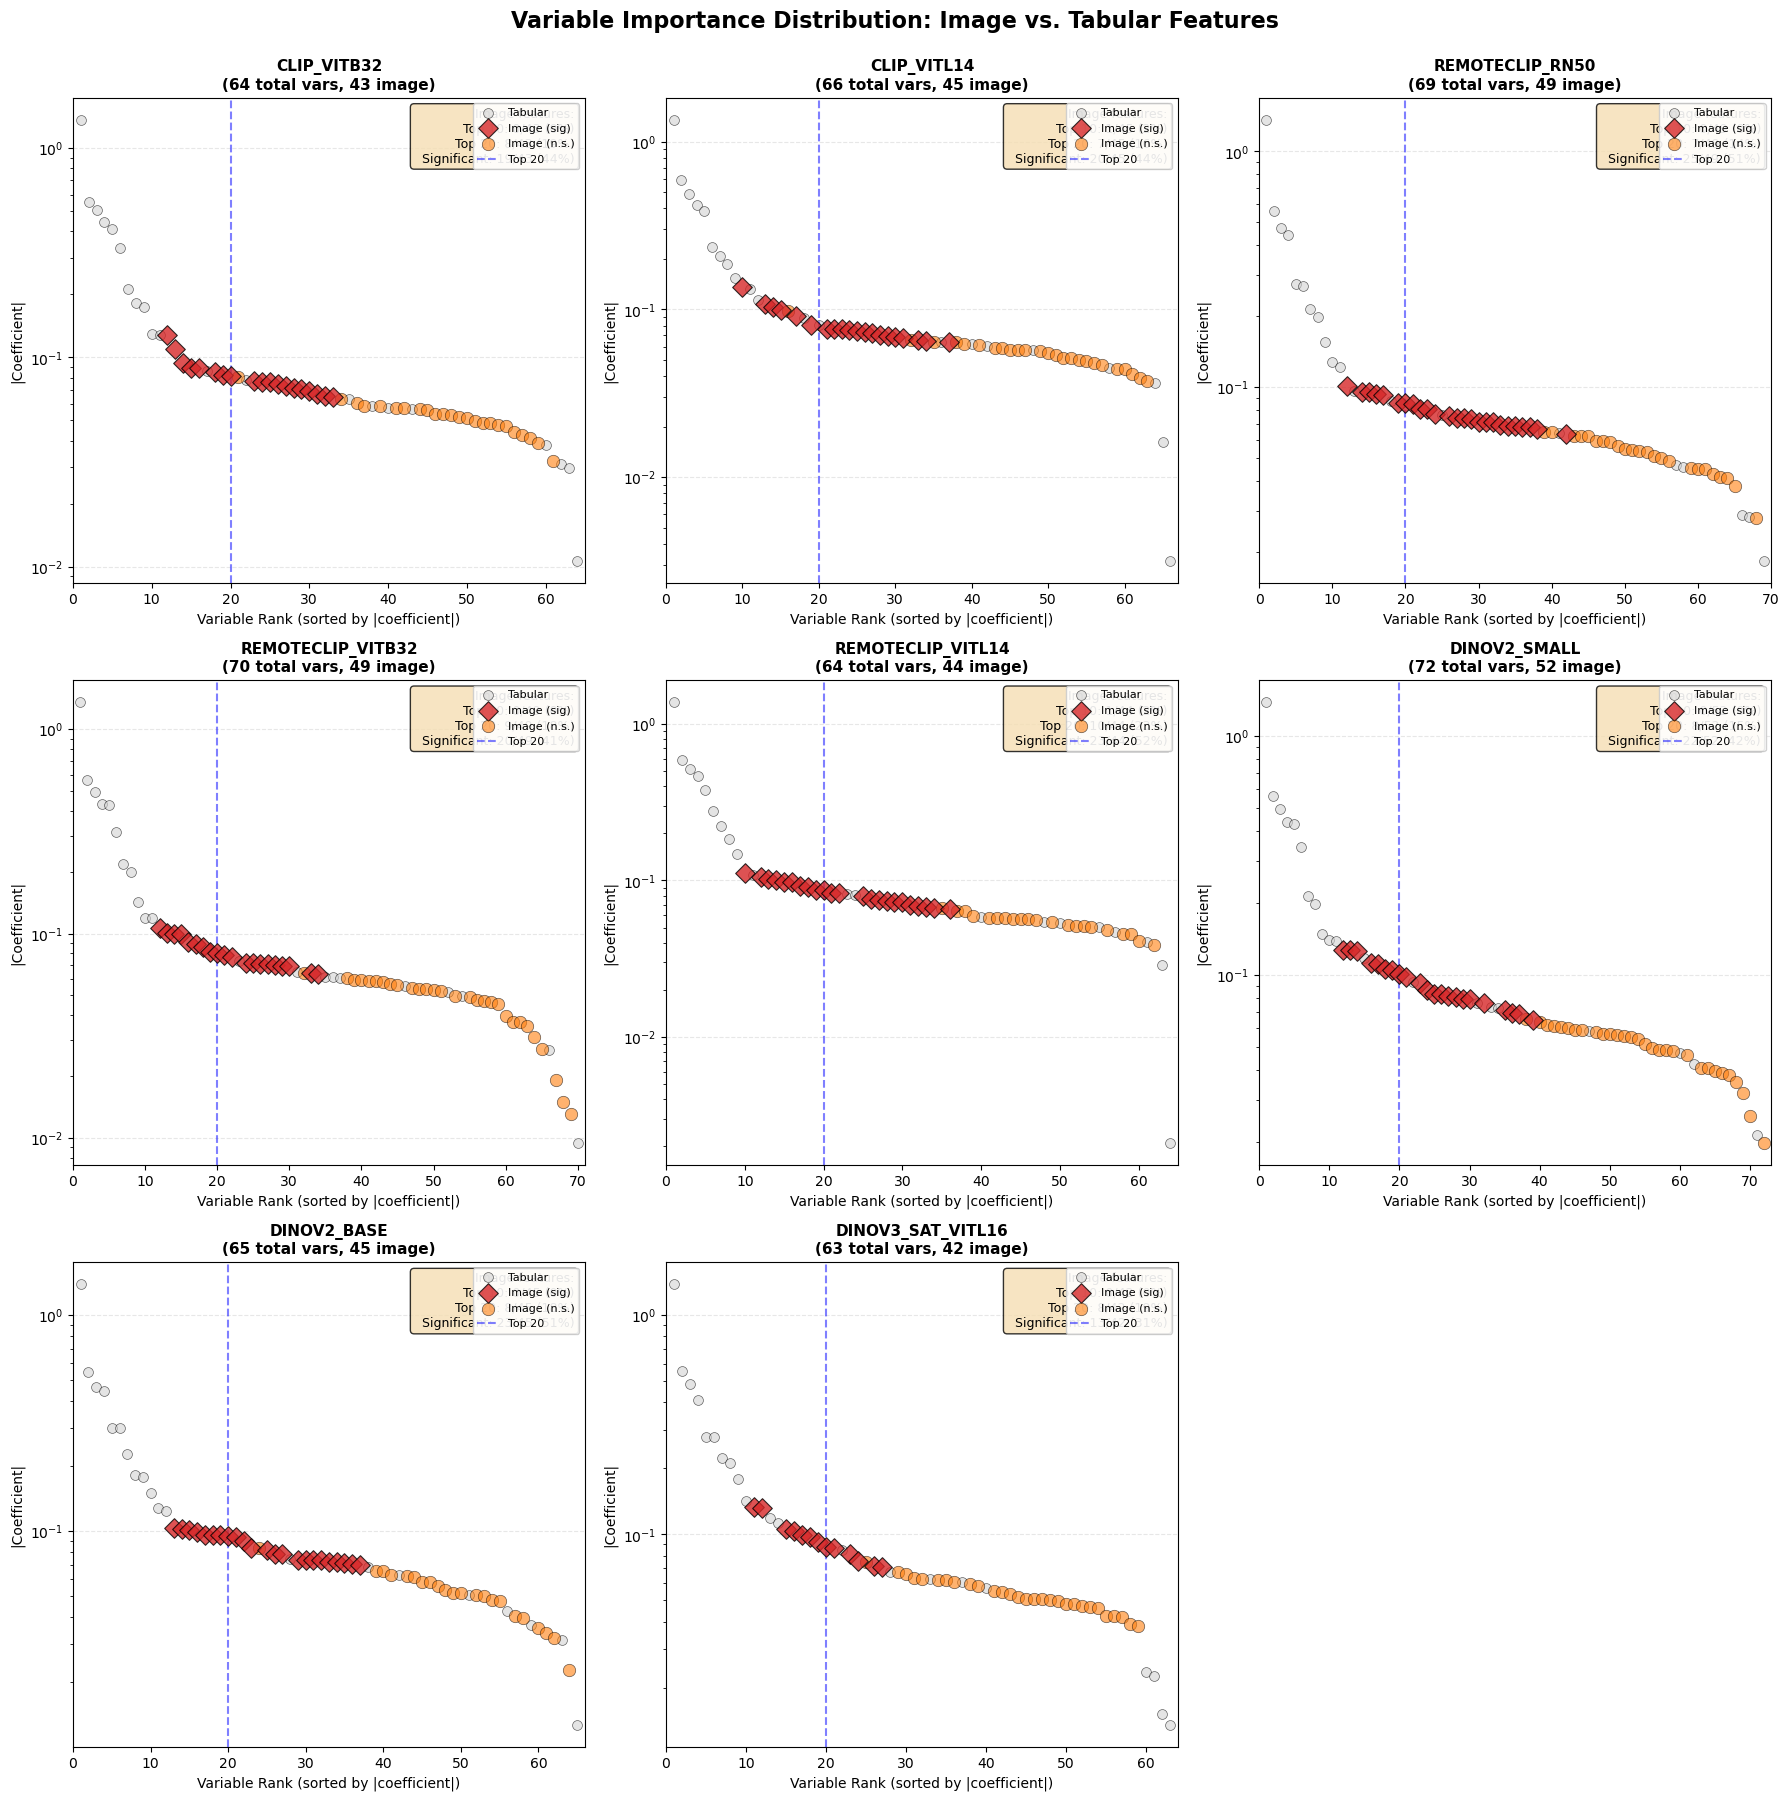


IMAGE FEATURE CONCENTRATION STATISTICS
            Model  Total Vars  Image Vars In Top 5 In Top 10  In Top 20  In Top 30 Median Rank  Highest Rank
      clip_vitb32          64          43 0 (0.0%)  0 (0.0%)  8 (18.6%) 17 (39.5%)  36 (56.2%)            12
      clip_vitl14          66          45 0 (0.0%)  1 (2.2%)  7 (15.6%) 17 (37.8%)  37 (56.1%)            10
  remoteclip_rn50          69          49 0 (0.0%)  0 (0.0%)  7 (14.3%) 16 (32.7%)  39 (56.5%)            12
remoteclip_vitb32          70          49 0 (0.0%)  0 (0.0%)  9 (18.4%) 18 (36.7%)  41 (58.6%)            12
remoteclip_vitl14          64          44 0 (0.0%)  1 (2.3%) 10 (22.7%) 18 (40.9%)  34 (53.9%)            10
     dinov2_small          72          52 0 (0.0%)  0 (0.0%)  8 (15.4%) 17 (32.7%)  42 (59.0%)            12
      dinov2_base          65          45 0 (0.0%)  0 (0.0%)  8 (17.8%) 17 (37.8%)  36 (55.4%)            13
dinov3_sat_vitl16          63          42 0 (0.0%)  0 (0.0%)  8 (19.0%) 16 (38.1%)  37 (

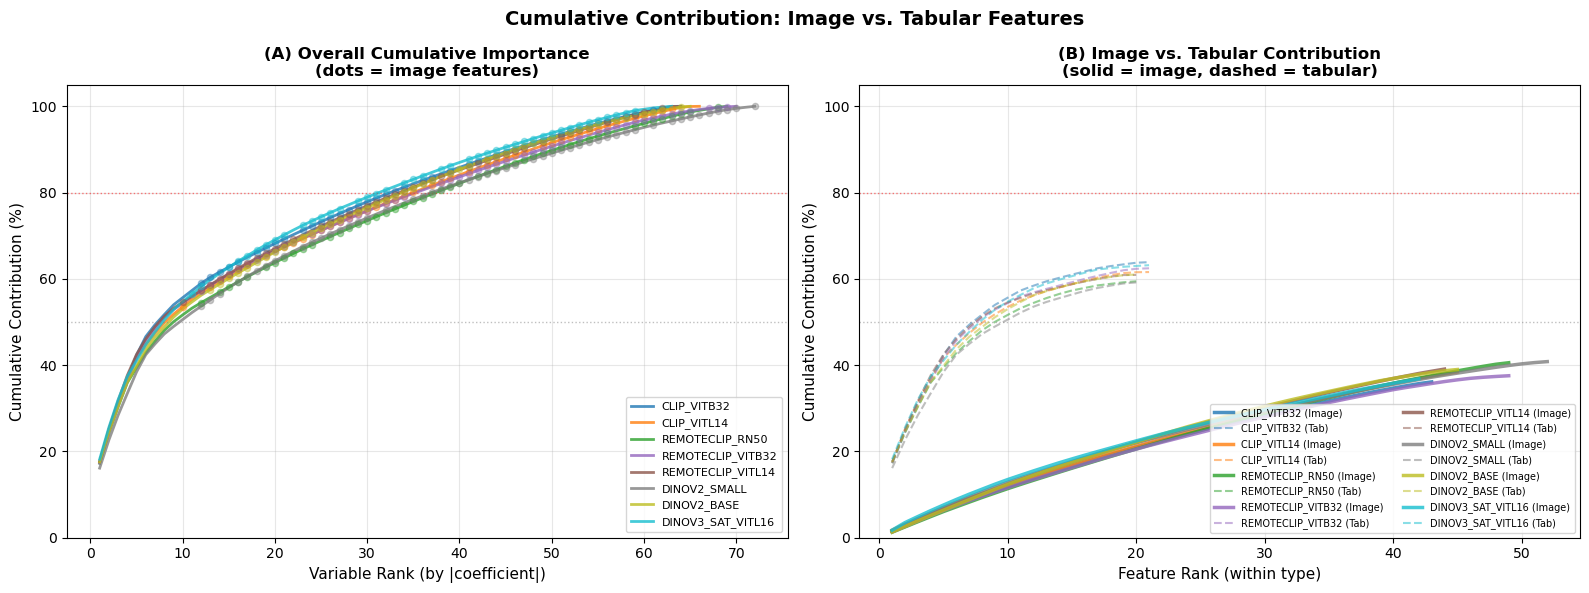


SUPPLEMENTARY ANALYSES COMPLETE

Generated outputs:
  1. Coefficient comparison table (CSV & LaTeX)
     - With image feature summary statistics
  2. Variable importance distribution plot
     - Shows image features concentrated at top ranks
  3. Image feature concentration statistics table
  4. Cumulative importance curves
     - Comparing image vs. tabular contributions

All files saved to: final_foundation_analysis_output2


In [6]:
# ============================================================================
# SUPPLEMENTARY ANALYSIS 1: Cross-Model Coefficient Comparison Table
# ============================================================================

print(f"\n{'='*80}")
print("SUPPLEMENTARY ANALYSIS 1: COEFFICIENT COMPARISON TABLE")
print(f"{'='*80}")

def create_coefficient_comparison_table(postlasso_results, tabular_feats, 
                                         person_hh, trip_f, orig_be, dest_be):
    """
    Create a comprehensive coefficient comparison table across all models.
    Format similar to Table 5 in the reference paper.
    """
    
    # Organize variables into panels
    panels = {
        'Panel 1: Sociodemographic Characteristics': person_hh,
        'Panel 2: Trip Characteristics': trip_f,
        'Panel 3: Built Environment - Origin': orig_be,
        'Panel 4: Built Environment - Destination': dest_be
    }
    
    # Get all models
    model_names = list(postlasso_results.keys())
    
    # Create table data
    table_rows = []
    
    for panel_name, variables in panels.items():
        # Add panel header
        table_rows.append({
            'Variable': f'\n{panel_name}',
            **{model: '' for model in model_names}
        })
        
        for var in variables:
            row_data = {'Variable': var}
            
            for model_name in model_names:
                coef_df = postlasso_results[model_name]['coef_df']
                
                # Find this variable in the coefficient dataframe
                var_row = coef_df[coef_df['variable'] == var]
                
                if len(var_row) > 0:
                    coef = var_row.iloc[0]['coef']
                    std_err = var_row.iloc[0]['std_err']
                    sig = var_row.iloc[0]['sig']
                    
                    # Format: coefficient (std_err) sig
                    row_data[model_name] = f"{coef:.3f}{sig}\n({std_err:.3f})"
                else:
                    row_data[model_name] = '—'
            
            table_rows.append(row_data)
    
    # ========================================================================
    # Panel 5: Imagery Features Summary (UPDATED)
    # ========================================================================
    table_rows.append({
        'Variable': f'\nPanel 5: Imagery Features Summary',
        **{model: '' for model in model_names}
    })
    
    # Total number of selected image features
    row_data = {'Variable': 'Total selected image features'}
    for model_name in model_names:
        n_img = postlasso_results[model_name]['n_img_selected']
        row_data[model_name] = str(n_img)
    table_rows.append(row_data)
    
    # Number of significant image features
    row_data = {'Variable': 'Significant image features (p<0.05)'}
    for model_name in model_names:
        n_sig = postlasso_results[model_name]['n_img_significant']
        n_total = postlasso_results[model_name]['n_img_selected']
        pct = n_sig / n_total * 100 if n_total > 0 else 0
        row_data[model_name] = f"{n_sig} ({pct:.1f}%)"
    table_rows.append(row_data)
    
    # Average absolute coefficient of image features
    row_data = {'Variable': 'Mean |coef| of image features'}
    for model_name in model_names:
        coef_df = postlasso_results[model_name]['coef_df']
        img_features = coef_df[coef_df['category'] == model_name]
        if len(img_features) > 0:
            mean_abs = img_features['abs_coef'].mean()
            row_data[model_name] = f"{mean_abs:.3f}"
        else:
            row_data[model_name] = '—'
    table_rows.append(row_data)
    
    # Max absolute coefficient of image features
    row_data = {'Variable': 'Max |coef| of image features'}
    for model_name in model_names:
        coef_df = postlasso_results[model_name]['coef_df']
        img_features = coef_df[coef_df['category'] == model_name]
        if len(img_features) > 0:
            max_abs = img_features['abs_coef'].max()
            row_data[model_name] = f"{max_abs:.3f}"
        else:
            row_data[model_name] = '—'
    table_rows.append(row_data)
    
    # Percentage of image features in top 20 variables
    row_data = {'Variable': 'Image features in top 20 variables (%)'}
    for model_name in model_names:
        coef_df = postlasso_results[model_name]['coef_df']
        # Get top 20 by absolute coefficient
        top20 = coef_df.nlargest(20, 'abs_coef')
        n_img_top20 = (top20['category'] == model_name).sum()
        pct = n_img_top20 / 20 * 100
        row_data[model_name] = f"{n_img_top20} ({pct:.0f}%)"
    table_rows.append(row_data)
    
    # ========================================================================
    # Top 3 Most Important Image Features (per model)
    # ========================================================================
    table_rows.append({
        'Variable': f'\nPanel 6: Top Image Features by Model',
        **{model: '' for model in model_names}
    })
    
    for model_name in model_names:
        coef_df = postlasso_results[model_name]['coef_df']
        img_features = coef_df[coef_df['category'] == model_name].copy()
        img_features = img_features.sort_values('abs_coef', ascending=False)
        
        if len(img_features) > 0:
            for i, (idx, row_data_item) in enumerate(img_features.head(3).iterrows()):
                var_name = row_data_item['variable']
                coef = row_data_item['coef']
                std_err = row_data_item['std_err']
                sig = row_data_item['sig']
                
                row_data = {'Variable': f'  Top {i+1}: {var_name}'}
                for m in model_names:
                    if m == model_name:
                        row_data[m] = f"{coef:.3f}{sig}\n({std_err:.3f})"
                    else:
                        row_data[m] = '—'
                table_rows.append(row_data)
    
    # ========================================================================
    # Model Fit Statistics
    # ========================================================================
    table_rows.append({
        'Variable': f'\nModel Fit Statistics',
        **{model: '' for model in model_names}
    })
    
    # Log-likelihood
    row_data = {'Variable': 'Log-Likelihood (test)'}
    for model_name in model_names:
        ll = postlasso_results[model_name]['ll_test']
        row_data[model_name] = f"{ll:.2f}"
    table_rows.append(row_data)
    
    # Pseudo R²
    row_data = {'Variable': 'Pseudo R² (test)'}
    for model_name in model_names:
        r2 = postlasso_results[model_name]['pseudo_r2_test']
        row_data[model_name] = f"{r2:.4f}"
    table_rows.append(row_data)
    
    # AUC
    row_data = {'Variable': 'AUC (test)'}
    for model_name in model_names:
        auc = postlasso_results[model_name]['auc_test']
        row_data[model_name] = f"{auc:.4f}"
    table_rows.append(row_data)
    
    # AIC
    row_data = {'Variable': 'AIC'}
    for model_name in model_names:
        aic = postlasso_results[model_name]['aic']
        row_data[model_name] = f"{aic:.1f}"
    table_rows.append(row_data)
    
    # BIC
    row_data = {'Variable': 'BIC'}
    for model_name in model_names:
        bic = postlasso_results[model_name]['bic']
        row_data[model_name] = f"{bic:.1f}"
    table_rows.append(row_data)
    
    # Sample size
    row_data = {'Variable': 'Sample size (test)'}
    for model_name in model_names:
        row_data[model_name] = str(len(y_test))
    table_rows.append(row_data)
    
    # Create DataFrame
    comparison_df = pd.DataFrame(table_rows)
    
    return comparison_df


# Generate the table
coef_comparison_table = create_coefficient_comparison_table(
    postlasso_results, tabular_feats, person_hh, trip_f, orig_be, dest_be
)

# Display the table
print("\nCOEFFICIENT COMPARISON TABLE")
print("="*150)
print(coef_comparison_table.to_string(index=False))
print("="*150)
print("\nNote: *** p < 0.001; ** p < 0.01; * p < 0.05; . p < 0.10")

# Save to CSV
coef_table_csv = config.OUTPUT_DIR / 'coefficient_comparison_table.csv'
coef_comparison_table.to_csv(coef_table_csv, index=False)
print(f"\n✓ Saved coefficient comparison table to: {coef_table_csv}")

# Also save as LaTeX format for publication
latex_output = config.OUTPUT_DIR / 'coefficient_comparison_table.tex'
with open(latex_output, 'w') as f:
    f.write("% Coefficient Comparison Table\n")
    f.write("% Generated from foundation model analysis\n\n")
    f.write(coef_comparison_table.to_latex(index=False, escape=False))
print(f"✓ Saved LaTeX table to: {latex_output}")


# ============================================================================
# SUPPLEMENTARY ANALYSIS 2: Variable Importance Distribution 
# (showing image features concentrated at the top)
# ============================================================================

print(f"\n{'='*80}")
print("SUPPLEMENTARY ANALYSIS 2: VARIABLE IMPORTANCE DISTRIBUTION")
print(f"{'='*80}")

def visualize_variable_importance_distribution(postlasso_results, output_dir):
    """
    Visualize how image features are concentrated among the most important variables.
    
    Key insight: Image features tend to cluster at the top of the importance ranking,
    suggesting they capture high-impact but specific aspects of the built environment.
    """
    
    n_models = len(postlasso_results)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('Variable Importance Distribution: Image vs. Tabular Features', 
                 fontsize=16, fontweight='bold', y=0.998)
    
    for idx, (model_name, result) in enumerate(postlasso_results.items()):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]
        
        # Get all coefficients sorted by absolute value
        coef_df = result['coef_df'].copy()
        coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
        
        # Create rank
        coef_df['rank'] = np.arange(1, len(coef_df) + 1)
        
        # Separate image and tabular features
        img_features = coef_df[coef_df['category'] == model_name]
        tab_features = coef_df[coef_df['category'] != model_name]
        
        # Plot tabular features (gray)
        ax.scatter(tab_features['rank'], tab_features['abs_coef'], 
                  color='lightgray', s=50, alpha=0.6, label='Tabular', 
                  edgecolor='black', linewidth=0.5, zorder=1)
        
        # Plot image features with color by significance
        img_sig = img_features[img_features['p_value'] < 0.05]
        img_nonsig = img_features[img_features['p_value'] >= 0.05]
        
        if len(img_sig) > 0:
            ax.scatter(img_sig['rank'], img_sig['abs_coef'], 
                      color='#d62728', s=100, alpha=0.8, label='Image (sig)', 
                      marker='D', edgecolor='black', linewidth=0.8, zorder=3)
        
        if len(img_nonsig) > 0:
            ax.scatter(img_nonsig['rank'], img_nonsig['abs_coef'], 
                      color='#ff7f0e', s=80, alpha=0.6, label='Image (n.s.)', 
                      marker='o', edgecolor='black', linewidth=0.5, zorder=2)
        
        # Add vertical lines to show top-20 boundary
        ax.axvline(x=20, color='blue', linestyle='--', linewidth=1.5, 
                  alpha=0.5, label='Top 20')
        
        # Calculate statistics
        n_img_top10 = (coef_df.head(10)['category'] == model_name).sum()
        n_img_top20 = (coef_df.head(20)['category'] == model_name).sum()
        n_img_total = len(img_features)
        
        # Add text annotation
        textstr = f'Image features:\n'
        textstr += f'  Top 10: {n_img_top10}/{n_img_total} ({n_img_top10/n_img_total*100:.0f}%)\n'
        textstr += f'  Top 20: {n_img_top20}/{n_img_total} ({n_img_top20/n_img_total*100:.0f}%)\n'
        textstr += f'  Significant: {len(img_sig)}/{n_img_total} ({len(img_sig)/n_img_total*100:.0f}%)'
        
        ax.text(0.98, 0.98, textstr, transform=ax.transAxes, 
               fontsize=9, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # Styling
        ax.set_xlabel('Variable Rank (sorted by |coefficient|)', fontsize=10)
        ax.set_ylabel('|Coefficient|', fontsize=10)
        ax.set_title(f'{model_name.upper()}\n({result["n_selected"]} total vars, '
                    f'{result["n_img_selected"]} image)', 
                    fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_xlim(0, len(coef_df) + 1)
        
        # Log scale for y-axis to better show distribution
        ax.set_yscale('log')
    
    # Hide unused subplots
    for idx in range(n_models, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')
    
    plt.tight_layout()
    
    # Save figure
    output_path = output_dir / 'variable_importance_distribution.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved variable importance distribution to: {output_path}")
    
    output_path_pdf = output_dir / 'variable_importance_distribution.pdf'
    plt.savefig(output_path_pdf, format='pdf', bbox_inches='tight')
    print(f"✓ Saved PDF version to: {output_path_pdf}")
    
    plt.show()
    
    # ========================================================================
    # Create summary statistics table
    # ========================================================================
    
    print("\n" + "="*120)
    print("IMAGE FEATURE CONCENTRATION STATISTICS")
    print("="*120)
    
    concentration_stats = []
    
    for model_name, result in postlasso_results.items():
        coef_df = result['coef_df'].copy()
        coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
        
        n_total_vars = len(coef_df)
        n_img_total = result['n_img_selected']
        
        # Count image features in different top-k groups
        n_img_top5 = (coef_df.head(5)['category'] == model_name).sum()
        n_img_top10 = (coef_df.head(10)['category'] == model_name).sum()
        n_img_top20 = (coef_df.head(20)['category'] == model_name).sum()
        n_img_top30 = (coef_df.head(30)['category'] == model_name).sum()
        
        # Calculate percentages
        pct_top5 = n_img_top5 / n_img_total * 100 if n_img_total > 0 else 0
        pct_top10 = n_img_top10 / n_img_total * 100 if n_img_total > 0 else 0
        pct_top20 = n_img_top20 / n_img_total * 100 if n_img_total > 0 else 0
        pct_top30 = n_img_top30 / n_img_total * 100 if n_img_total > 0 else 0
        
        # Get median rank of image features
        img_ranks = coef_df[coef_df['category'] == model_name].index + 1
        median_rank = np.median(img_ranks) if len(img_ranks) > 0 else 0
        median_rank_pct = median_rank / n_total_vars * 100 if n_total_vars > 0 else 0
        
        concentration_stats.append({
            'Model': model_name,
            'Total Vars': n_total_vars,
            'Image Vars': n_img_total,
            'In Top 5': f"{n_img_top5} ({pct_top5:.1f}%)",
            'In Top 10': f"{n_img_top10} ({pct_top10:.1f}%)",
            'In Top 20': f"{n_img_top20} ({pct_top20:.1f}%)",
            'In Top 30': f"{n_img_top30} ({pct_top30:.1f}%)",
            'Median Rank': f"{median_rank:.0f} ({median_rank_pct:.1f}%)",
            'Highest Rank': int(img_ranks.min()) if len(img_ranks) > 0 else 0
        })
    
    concentration_df = pd.DataFrame(concentration_stats)
    print(concentration_df.to_string(index=False))
    print("="*120)
    print("\nInterpretation:")
    print("  • High percentage in Top 5/10/20 → Image features are among the most important")
    print("  • Low median rank → Image features concentrate at the top of importance ranking")
    print("  • This suggests image features capture high-impact aspects of built environment")
    
    # Save table
    concentration_csv = output_dir / 'image_feature_concentration.csv'
    concentration_df.to_csv(concentration_csv, index=False)
    print(f"\n✓ Saved concentration statistics to: {concentration_csv}")
    
    return concentration_df


# Generate visualization
concentration_stats_df = visualize_variable_importance_distribution(
    postlasso_results, config.OUTPUT_DIR
)


# ============================================================================
# SUPPLEMENTARY ANALYSIS 3: Cumulative Importance Curve
# ============================================================================

print(f"\n{'='*80}")
print("SUPPLEMENTARY ANALYSIS 3: CUMULATIVE IMPORTANCE CURVES")
print(f"{'='*80}")

def create_cumulative_importance_comparison(postlasso_results, output_dir):
    """
    Create cumulative importance curves comparing image vs. tabular features.
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Cumulative Contribution: Image vs. Tabular Features', 
                 fontsize=14, fontweight='bold')
    
    # Color palette
    colors = plt.cm.tab10(np.linspace(0, 1, len(postlasso_results)))
    
    for idx, (model_name, result) in enumerate(postlasso_results.items()):
        coef_df = result['coef_df'].copy()
        coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
        
        # Calculate cumulative contribution
        total_abs = coef_df['abs_coef'].sum()
        cumulative = np.cumsum(coef_df['abs_coef']) / total_abs * 100
        
        # Separate by feature type
        is_image = coef_df['category'] == model_name
        
        # Plot 1: Overall cumulative curve with feature type markers
        x = np.arange(1, len(coef_df) + 1)
        ax1.plot(x, cumulative, linewidth=2, label=model_name.upper(), 
                color=colors[idx], alpha=0.8)
        
        # Mark where image features are
        img_positions = x[is_image]
        img_cumulative = cumulative[is_image]
        ax1.scatter(img_positions, img_cumulative, s=20, color=colors[idx], 
                   alpha=0.4, marker='o', zorder=3)
        
        # Plot 2: Compare cumulative contribution of image vs tabular
        img_features = coef_df[is_image].copy()
        tab_features = coef_df[~is_image].copy()
        
        if len(img_features) > 0:
            img_cumsum = np.cumsum(img_features['abs_coef']) / total_abs * 100
            img_x = np.arange(1, len(img_features) + 1)
            ax2.plot(img_x, img_cumsum, linewidth=2.5, 
                    label=f'{model_name.upper()} (Image)', 
                    color=colors[idx], linestyle='-', alpha=0.8)
        
        if len(tab_features) > 0:
            tab_cumsum = np.cumsum(tab_features['abs_coef']) / total_abs * 100
            tab_x = np.arange(1, len(tab_features) + 1)
            ax2.plot(tab_x, tab_cumsum, linewidth=1.5, 
                    label=f'{model_name.upper()} (Tab)', 
                    color=colors[idx], linestyle='--', alpha=0.5)
    
    # Styling for Plot 1
    ax1.axhline(y=50, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax1.axhline(y=80, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax1.set_xlabel('Variable Rank (by |coefficient|)', fontsize=11)
    ax1.set_ylabel('Cumulative Contribution (%)', fontsize=11)
    ax1.set_title('(A) Overall Cumulative Importance\n(dots = image features)', 
                 fontsize=12, fontweight='bold')
    ax1.legend(fontsize=8, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 105)
    
    # Styling for Plot 2
    ax2.axhline(y=50, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax2.axhline(y=80, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Feature Rank (within type)', fontsize=11)
    ax2.set_ylabel('Cumulative Contribution (%)', fontsize=11)
    ax2.set_title('(B) Image vs. Tabular Contribution\n(solid = image, dashed = tabular)', 
                 fontsize=12, fontweight='bold')
    ax2.legend(fontsize=7, loc='lower right', ncol=2)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 105)
    
    plt.tight_layout()
    
    # Save
    output_path = output_dir / 'cumulative_importance_comparison.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved cumulative importance comparison to: {output_path}")
    
    output_path_pdf = output_dir / 'cumulative_importance_comparison.pdf'
    plt.savefig(output_path_pdf, format='pdf', bbox_inches='tight')
    print(f"✓ Saved PDF version to: {output_path_pdf}")
    
    plt.show()


# Generate cumulative importance comparison
create_cumulative_importance_comparison(postlasso_results, config.OUTPUT_DIR)

print(f"\n{'='*80}")
print("SUPPLEMENTARY ANALYSES COMPLETE")
print(f"{'='*80}")
print(f"\nGenerated outputs:")
print(f"  1. Coefficient comparison table (CSV & LaTeX)")
print(f"     - With image feature summary statistics")
print(f"  2. Variable importance distribution plot")
print(f"     - Shows image features concentrated at top ranks")
print(f"  3. Image feature concentration statistics table")
print(f"  4. Cumulative importance curves")
print(f"     - Comparing image vs. tabular contributions")
print(f"\nAll files saved to: {config.OUTPUT_DIR}")

In [5]:
!pip install --upgrade jinja2

Defaulting to user installation because normal site-packages is not writeable
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)


In [5]:
import matplotlib.pyplot as plt

In [6]:
!pip install open-clip-torch

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 131.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22/22 [open-clip-torch] [open-clip-torch]


In [6]:
# ============================================================================
# CLIP ZERO-SHOT SEMANTIC ALIGNMENT (UPDATED)
# ============================================================================

print(f"\n{'='*80}")
print("STEP 6: CLIP ZERO-SHOT SEMANTIC ALIGNMENT")
print(f"{'='*80}")

if 'clip_vitb32' in embeddings_dict and has_open_clip:
    try:
        import open_clip
        from scipy.stats import pearsonr, ttest_ind
        
        # ====================================================================
        # Load CLIP model
        # ====================================================================
        print(f"\n[6.1] Loading CLIP model for text encoding...")
        model, _, preprocess = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='openai'
        )
        model = model.to(device).eval()
        tokenizer = open_clip.tokenize
        
        # ====================================================================
        # Define hierarchical urban concepts
        # ====================================================================
        print(f"\n[6.2] Defining hierarchical urban planning concepts...")
        
        # Tier 1: Traditional 5D Built Environment Concepts
        tier1_concepts = {
            # Density
            "high_density_urban": "High-density urban fabric, tightly packed multi-story buildings",
            "low_density_suburban": "Low-density suburban sprawl, sparse single-family housing",
            
            # Diversity
            "mixed_use": "Mixed-use neighborhood, integrated retail and residential roofs",
            "single_use": "Homogeneous residential monoculture, uniform housing units",
            
            # Design
            "grid_network": "Grid street network, high intersection density",
            "cul_de_sac": "Cul-de-sac street patterns, fragmented road network",
            
            # Accessibility
            "central_cbd": "Central business district, dense office clusters",
            "remote_fringe": "Remote suburban fringe, isolated from urban centers",
            
            # Distance to Transit
            "tod": "Transit-oriented development near rail station",
            "car_dependent": "Car-dependent landscape, no public transit infrastructure"
        }
        
        # Tier 2: Satellite-Specific Physical Features
        tier2_concepts = {
            # Vegetation
            "dense_tree_canopy": "dense urban tree canopy providing significant shade over streets",
            "barren_landscape": "barren urban landscape with minimal tree cover and vegetation",
            
            # Building Footprint
            "tight_building_footprint": "tight building footprints with high lot coverage and small setbacks",
            "low_lot_coverage": "low building lot coverage with large private yards and open spaces",
            
            # Parking
            "minimal_parking": "minimal surface parking with hidden or underground garages",
            "large_parking_lots": "large expanses of asphalt surface parking lots dominating the view",
            
            # Street Design
            "narrow_streets": "human-scale narrow streets designed for slow traffic",
            "wide_arterial": "oversized wide multi-lane roads and high-speed arterial highways",
            
            # Waterfront
            "accessible_waterfront": "accessible waterfront with public promenades and green parks",
            "industrial_waterfront": "degraded industrial waterfront with no public pedestrian access",
            
            # Infrastructure
            "green_infrastructure": "porous green infrastructure with integrated rain gardens",
            "grey_infrastructure": "solid impervious grey infrastructure with concrete and asphalt"
        }
        
        # Tier 3: Data-Derived Morphological Patterns
        tier3_concepts = {
            "transit_village": "pedestrian-prioritized transit village with compact development",
            "commercial_strip": "automobile-dependent commercial strip with large parking buffers",
            "fine_grain_urban": "fine-grained urban morphology with small blocks and frequent doors",
            "coarse_grain_industrial": "coarse-grained industrial morphology with massive warehouses",
            "active_streetscape": "active urban streetscape with continuous sidewalk networks",
            "passive_suburban": "passive suburban landscape with fragmented or missing sidewalks",
            "tod_high_intensity": "transit-oriented development (TOD) with high-intensity land use",
            "car_centric_sprawl": "car-centric urban sprawl with fragmented natural patches"
        }
        
        # Combine all concepts
        all_concepts = {
            **{f"T1_{k}": v for k, v in tier1_concepts.items()},
            **{f"T2_{k}": v for k, v in tier2_concepts.items()},
            **{f"T3_{k}": v for k, v in tier3_concepts.items()}
        }
        
        concept_names = list(all_concepts.keys())
        concept_texts = list(all_concepts.values())
        
        print(f"  Tier 1 (5D Built Environment): {len(tier1_concepts)} concepts")
        print(f"  Tier 2 (Satellite Features): {len(tier2_concepts)} concepts")
        print(f"  Tier 3 (Morphological Patterns): {len(tier3_concepts)} concepts")
        print(f"  Total concepts: {len(all_concepts)}")
        
        # ====================================================================
        # Encode all concept texts
        # ====================================================================
        print(f"\n[6.3] Encoding text concepts...")
        text_tokens = tokenizer(concept_texts).to(device)
        with torch.no_grad():
            text_features = model.encode_text(text_tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        
        print(f"  Encoded {len(concept_texts)} text concepts")
        
        # ====================================================================
        # Get CLIP embeddings and compute similarities
        # ====================================================================
        print(f"\n[6.4] Computing text-image similarities...")
        clip_embeddings = embeddings_dict['clip_vitb32']['embeddings']
        clip_embeddings_tensor = torch.from_numpy(clip_embeddings).float().to(device)
        clip_embeddings_tensor = clip_embeddings_tensor / clip_embeddings_tensor.norm(
            dim=-1, keepdim=True
        )
        
        # Compute similarities: (N_locations, N_concepts)
        similarities = clip_embeddings_tensor @ text_features.T
        similarities_np = similarities.cpu().numpy()
        
        print(f"  Similarity matrix shape: {similarities_np.shape}")
        
        # ====================================================================
        # Multi-concept assignment for each image
        # ====================================================================
        print(f"\n[6.5] Assigning multiple concepts to each location...")
        
        # For each location, get top-k matching concepts
        top_k = 5  # Number of concepts per image
        
        location_concepts = []
        for loc_idx in range(len(similarities_np)):
            top_indices = np.argsort(similarities_np[loc_idx])[-top_k:][::-1]
            top_concepts = []
            
            for idx in top_indices:
                top_concepts.append({
                    'concept_name': concept_names[idx],
                    'concept_text': concept_texts[idx],
                    'similarity': similarities_np[loc_idx, idx]
                })
            
            location_concepts.append({
                'location_idx': loc_idx,
                'top_concepts': top_concepts
            })
        
        print(f"  Assigned top-{top_k} concepts to {len(location_concepts)} locations")
        
        # ====================================================================
        # Analyze concept-mode choice correlations
        # ====================================================================
        print(f"\n[6.6] Analyzing concept-transit correlations...")
        
        concept_mode_correlations = []
        
        for concept_idx, concept_name in enumerate(concept_names):
            concept_text = concept_texts[concept_idx]
            
            # Origin correlations
            trip_similarities_orig = []
            trip_modes = []
            
            for trip_idx in range(len(df)):
                orig_emb_idx = df.iloc[trip_idx]['orig_emb_idx']
                if 0 <= orig_emb_idx < len(similarities_np):
                    trip_similarities_orig.append(similarities_np[orig_emb_idx, concept_idx])
                    trip_modes.append(df.iloc[trip_idx]['is_transit'])
            
            if len(trip_similarities_orig) < 100:
                continue
            
            # Compute correlation for origins
            corr_orig, p_orig = pearsonr(trip_similarities_orig, trip_modes)
            
            # Destination correlations
            trip_similarities_dest = []
            trip_modes_dest = []
            
            for trip_idx in range(len(df)):
                dest_emb_idx = df.iloc[trip_idx]['dest_emb_idx']
                if 0 <= dest_emb_idx < len(similarities_np):
                    trip_similarities_dest.append(similarities_np[dest_emb_idx, concept_idx])
                    trip_modes_dest.append(df.iloc[trip_idx]['is_transit'])
            
            corr_dest, p_dest = pearsonr(trip_similarities_dest, trip_modes_dest)
            
            # Combined correlation (average)
            corr_combined = (corr_orig + corr_dest) / 2
            
            # Determine tier
            if concept_name.startswith('T1_'):
                tier = 'Tier 1: 5D Built Environment'
            elif concept_name.startswith('T2_'):
                tier = 'Tier 2: Satellite Features'
            else:
                tier = 'Tier 3: Morphological Patterns'
            
            concept_mode_correlations.append({
                'tier': tier,
                'concept_name': concept_name,
                'concept_text': concept_text,
                'corr_origin': corr_orig,
                'p_origin': p_orig,
                'corr_dest': corr_dest,
                'p_dest': p_dest,
                'corr_combined': corr_combined,
                'sig_origin': sig_stars(p_orig),
                'sig_dest': sig_stars(p_dest)
            })
        
        # Create DataFrame
        concept_df = pd.DataFrame(concept_mode_correlations)
        
        # ====================================================================
        # Print results by tier
        # ====================================================================
        print(f"\n{'='*100}")
        print("CONCEPT-TRANSIT CORRELATIONS BY TIER")
        print(f"{'='*100}")
        
        for tier in ['Tier 1: 5D Built Environment', 
                     'Tier 2: Satellite Features', 
                     'Tier 3: Morphological Patterns']:
            tier_df = concept_df[concept_df['tier'] == tier].sort_values(
                'corr_combined', ascending=False
            )
            
            print(f"\n{tier}")
            print(f"{'-'*100}")
            print(f"{'Concept':<40} {'Corr(O)':>10} {'Sig':>5} {'Corr(D)':>10} {'Sig':>5} {'Combined':>10}")
            print(f"{'-'*100}")
            
            for _, row in tier_df.iterrows():
                concept_short = row['concept_name'].replace('T1_', '').replace('T2_', '').replace('T3_', '')
                print(f"{concept_short:<40} {row['corr_origin']:>+10.3f} {row['sig_origin']:>5} "
                      f"{row['corr_dest']:>+10.3f} {row['sig_dest']:>5} {row['corr_combined']:>+10.3f}")
        
        # ====================================================================
        # Summary statistics by tier
        # ====================================================================
        print(f"\n{'='*100}")
        print("SUMMARY STATISTICS BY TIER")
        print(f"{'='*100}")
        
        tier_summary = concept_df.groupby('tier').agg({
            'corr_origin': ['mean', 'std', 'min', 'max'],
            'corr_dest': ['mean', 'std', 'min', 'max'],
            'corr_combined': ['mean', 'std', 'min', 'max']
        }).round(3)
        
        print(tier_summary)
        
        # ====================================================================
        # Top transit-promoting and auto-promoting concepts
        # ====================================================================
        print(f"\n{'='*100}")
        print("TOP TRANSIT-PROMOTING CONCEPTS (across all tiers)")
        print(f"{'='*100}")
        
        top_transit = concept_df.sort_values('corr_combined', ascending=False).head(10)
        
        for i, (_, row) in enumerate(top_transit.iterrows(), 1):
            print(f"\n{i}. {row['concept_name']}")
            print(f"   Text: {row['concept_text']}")
            print(f"   Corr (Origin): {row['corr_origin']:+.3f} {row['sig_origin']}")
            print(f"   Corr (Dest):   {row['corr_dest']:+.3f} {row['sig_dest']}")
            print(f"   Combined:      {row['corr_combined']:+.3f}")
        
        print(f"\n{'='*100}")
        print("TOP AUTO-PROMOTING CONCEPTS (across all tiers)")
        print(f"{'='*100}")
        
        top_auto = concept_df.sort_values('corr_combined', ascending=True).head(10)
        
        for i, (_, row) in enumerate(top_auto.iterrows(), 1):
            print(f"\n{i}. {row['concept_name']}")
            print(f"   Text: {row['concept_text']}")
            print(f"   Corr (Origin): {row['corr_origin']:+.3f} {row['sig_origin']}")
            print(f"   Corr (Dest):   {row['corr_dest']:+.3f} {row['sig_dest']}")
            print(f"   Combined:      {row['corr_combined']:+.3f}")
        
        # ====================================================================
        # Create visualization: Heatmap of concept correlations
        # ====================================================================
        print(f"\n[6.7] Creating visualizations...")
        
        fig, axes = plt.subplots(1, 3, figsize=(20, 8))
        fig.suptitle('CLIP Zero-Shot Concept-Transit Correlations by Tier', 
                     fontsize=16, fontweight='bold')
        
        for idx, tier in enumerate(['Tier 1: 5D Built Environment', 
                                     'Tier 2: Satellite Features', 
                                     'Tier 3: Morphological Patterns']):
            ax = axes[idx]
            tier_df = concept_df[concept_df['tier'] == tier].sort_values('corr_combined')
            
            # Prepare data for heatmap
            concepts = [c.replace('T1_', '').replace('T2_', '').replace('T3_', '')[:30] 
                       for c in tier_df['concept_name']]
            corr_orig = tier_df['corr_origin'].values
            corr_dest = tier_df['corr_dest'].values
            
            # Create grouped bar chart
            y_pos = np.arange(len(concepts))
            width = 0.35
            
            bars1 = ax.barh(y_pos - width/2, corr_orig, width, 
                           label='Origin', alpha=0.8, color='steelblue')
            bars2 = ax.barh(y_pos + width/2, corr_dest, width,
                           label='Destination', alpha=0.8, color='coral')
            
            ax.set_yticks(y_pos)
            ax.set_yticklabels(concepts, fontsize=8)
            ax.set_xlabel('Correlation with Transit Choice', fontsize=10)
            ax.set_title(tier.replace('Tier ', 'T'), fontsize=12, fontweight='bold')
            ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
            ax.grid(axis='x', alpha=0.3, linestyle='--')
            ax.legend(fontsize=9)
        
        plt.tight_layout()
        
        # Save visualization
        viz_path = config.OUTPUT_DIR / 'clip_zeroshot_concept_correlations.png'
        plt.savefig(viz_path, dpi=300, bbox_inches='tight')
        print(f"  ✓ Saved visualization to: {viz_path}")
        plt.close()
        
        # ====================================================================
        # Save detailed results
        # ====================================================================
        
        # Save concept correlations
        clip_csv = config.OUTPUT_DIR / 'clip_zeroshot_concepts_detailed.csv'
        concept_df.to_csv(clip_csv, index=False)
        print(f"  ✓ Saved detailed results to: {clip_csv}")
        
        # Save location-concept assignments
        location_concepts_df = []
        for loc_data in location_concepts[:100]:  # Save first 100 for inspection
            loc_idx = loc_data['location_idx']
            for rank, concept_info in enumerate(loc_data['top_concepts'], 1):
                location_concepts_df.append({
                    'location_idx': loc_idx,
                    'rank': rank,
                    'concept_name': concept_info['concept_name'],
                    'concept_text': concept_info['concept_text'],
                    'similarity': concept_info['similarity']
                })
        
        loc_concepts_csv = config.OUTPUT_DIR / 'location_concept_assignments_sample.csv'
        pd.DataFrame(location_concepts_df).to_csv(loc_concepts_csv, index=False)
        print(f"  ✓ Saved location-concept assignments to: {loc_concepts_csv}")
        
        # ====================================================================
        # Create tier comparison summary table
        # ====================================================================
        tier_comparison = []
        
        for tier in ['Tier 1: 5D Built Environment', 
                     'Tier 2: Satellite Features', 
                     'Tier 3: Morphological Patterns']:
            tier_df = concept_df[concept_df['tier'] == tier]
            
            # Count significant concepts
            sig_orig = (tier_df['p_origin'] < 0.05).sum()
            sig_dest = (tier_df['p_dest'] < 0.05).sum()
            
            # Get strongest pro-transit and pro-auto
            strongest_transit = tier_df.loc[tier_df['corr_combined'].idxmax()]
            strongest_auto = tier_df.loc[tier_df['corr_combined'].idxmin()]
            
            tier_comparison.append({
                'Tier': tier,
                'N Concepts': len(tier_df),
                'Sig at Origin (p<0.05)': sig_orig,
                'Sig at Dest (p<0.05)': sig_dest,
                'Mean |Corr|': tier_df['corr_combined'].abs().mean(),
                'Strongest Pro-Transit': strongest_transit['concept_name'],
                'Pro-Transit Corr': strongest_transit['corr_combined'],
                'Strongest Pro-Auto': strongest_auto['concept_name'],
                'Pro-Auto Corr': strongest_auto['corr_combined']
            })
        
        tier_comp_df = pd.DataFrame(tier_comparison)
        
        print(f"\n{'='*100}")
        print("TIER COMPARISON SUMMARY")
        print(f"{'='*100}")
        print(tier_comp_df.to_string(index=False))
        
        # Save tier comparison
        tier_comp_csv = config.OUTPUT_DIR / 'clip_tier_comparison.csv'
        tier_comp_df.to_csv(tier_comp_csv, index=False)
        print(f"\n  ✓ Saved tier comparison to: {tier_comp_csv}")
        
        print(f"\n{'='*80}")
        print("CLIP ZERO-SHOT ANALYSIS COMPLETE")
        print(f"{'='*80}")
        print(f"\nGenerated outputs:")
        print(f"  • Detailed concept correlations (by tier)")
        print(f"  • Location-concept assignments (top-5 per location)")
        print(f"  • Visualization: correlation heatmap by tier")
        print(f"  • Tier comparison summary table")
        
    except Exception as e:
        print(f"\n  ✗ CLIP zero-shot analysis failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\n  ⚠️ CLIP not available, skipping zero-shot analysis")


STEP 6: CLIP ZERO-SHOT SEMANTIC ALIGNMENT

[6.1] Loading CLIP model for text encoding...

[6.2] Defining hierarchical urban planning concepts...
  Tier 1 (5D Built Environment): 10 concepts
  Tier 2 (Satellite Features): 12 concepts
  Tier 3 (Morphological Patterns): 8 concepts
  Total concepts: 30

[6.3] Encoding text concepts...
  Encoded 30 text concepts

[6.4] Computing text-image similarities...
  Similarity matrix shape: (1148, 30)

[6.5] Assigning multiple concepts to each location...
  Assigned top-5 concepts to 1148 locations

[6.6] Analyzing concept-transit correlations...

CONCEPT-TRANSIT CORRELATIONS BY TIER

Tier 1: 5D Built Environment
----------------------------------------------------------------------------------------------------
Concept                                     Corr(O)   Sig    Corr(D)   Sig   Combined
----------------------------------------------------------------------------------------------------
high_density_urban                           +0.027  

In [9]:
# ADVANCED IMAGE-TEXT INTERPRETATION: LINKING MODEL RESULTS TO SEMANTICS

print(f"\n{'='*80}")
print("STEP 7: ADVANCED IMAGERY-TEXT INTERPRETATION")
print(f"{'='*80}")

if has_open_clip:
    try:
        import open_clip
        from scipy.stats import pearsonr
        from PIL import Image
        import matplotlib.pyplot as plt
        import matplotlib.gridspec as gridspec
        from matplotlib.patches import Rectangle
        import textwrap
        import pandas as pd
        import numpy as np
        import torch
        from torch.utils.data import DataLoader
        from pathlib import Path
        
        # ====================================================================
        # [7.1] Load CLIP model and define concepts
        # ====================================================================
        print(f"\n[7.1] Loading CLIP model for interpretation...")
        
        model, _, preprocess = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='openai'
        )
        model = model.to(device).eval()
        tokenizer = open_clip.tokenize
        
        # Define hierarchical urban concepts
        tier1_concepts = {
            "high_density_urban": "High-density urban fabric, tightly packed multi-story buildings",
            "low_density_suburban": "Low-density suburban sprawl, sparse single-family housing",
            "mixed_use": "Mixed-use neighborhood, integrated retail and residential",
            "single_use": "Homogeneous residential monoculture, uniform housing units",
            "grid_network": "Grid street network, high intersection density",
            "cul_de_sac": "Cul-de-sac street patterns, fragmented road network",
            "central_cbd": "Central business district, dense office clusters",
            "remote_fringe": "Remote suburban fringe, isolated from urban centers",
            "tod": "Transit-oriented development near rail station",
            "car_dependent": "Car-dependent landscape, no public transit infrastructure"
        }
        
        tier2_concepts = {
            "dense_tree_canopy": "Dense urban tree canopy providing significant shade over streets",
            "barren_landscape": "Barren urban landscape with minimal tree cover and vegetation",
            "tight_building_footprint": "Tight building footprints with high lot coverage and small setbacks",
            "low_lot_coverage": "Low building lot coverage with large private yards and open spaces",
            "minimal_parking": "Minimal surface parking with hidden or underground garages",
            "large_parking_lots": "Large expanses of asphalt surface parking lots dominating the view",
            "narrow_streets": "Human-scale narrow streets designed for slow traffic",
            "wide_arterial": "Oversized wide multi-lane roads and high-speed arterial highways",
            "accessible_waterfront": "Accessible waterfront with public promenades and green parks",
            "industrial_waterfront": "Degraded industrial waterfront with no public pedestrian access",
            "green_infrastructure": "Porous green infrastructure with integrated rain gardens",
            "grey_infrastructure": "Solid impervious grey infrastructure with concrete and asphalt"
        }
        
        tier3_concepts = {
            "transit_village": "Pedestrian-prioritized transit village with compact development",
            "commercial_strip": "Automobile-dependent commercial strip with large parking buffers",
            "fine_grain_urban": "Fine-grained urban morphology with small blocks and frequent doors",
            "coarse_grain_industrial": "Coarse-grained industrial morphology with massive warehouses",
            "active_streetscape": "Active urban streetscape with continuous sidewalk networks",
            "passive_suburban": "Passive suburban landscape with fragmented or missing sidewalks",
            "tod_high_intensity": "Transit-oriented development with high-intensity land use",
            "car_centric_sprawl": "Car-centric urban sprawl with fragmented natural patches"
        }
        
        all_concepts = {
            **{f"T1_{k}": v for k, v in tier1_concepts.items()},
            **{f"T2_{k}": v for k, v in tier2_concepts.items()},
            **{f"T3_{k}": v for k, v in tier3_concepts.items()}
        }
        
        concept_names = list(all_concepts.keys())
        concept_texts = list(all_concepts.values())
        
        # Encode text concepts
        text_tokens = tokenizer(concept_texts).to(device)
        with torch.no_grad():
            text_features = model.encode_text(text_tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        
        # ====================================================================
        # [7.2] Select best model and load saved components
        # ====================================================================
        print(f"\n[7.2] Selecting best model and loading components...")
        
        best_model_name = max(
            postlasso_results.keys(),
            key=lambda k: postlasso_results[k]['pseudo_r2_test']
        )
        
        model_results = postlasso_results[best_model_name]
        coef_df = model_results['coef_df'].copy()
        pca_obj = model_results['pca']
        scaler_obj = model_results['scaler']
        embeddings = embeddings_dict[best_model_name]['embeddings']
        
        # Compute CLIP similarities for images
        clip_dataset = SatelliteDataset(emb_index, transform=preprocess)
        clip_loader = DataLoader(clip_dataset, batch_size=32, shuffle=False)
        
        clip_image_features = []
        with torch.no_grad():
            for batch in clip_loader:
                imgs = batch['image'].to(device)
                img_feat = model.encode_image(imgs)
                img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
                clip_image_features.append(img_feat.cpu())
        
        clip_image_features = torch.cat(clip_image_features, dim=0).numpy()
        similarities_np = clip_image_features @ text_features.cpu().numpy().T
        
        # Get significant features
        sig_img_features = coef_df[
            (coef_df['category'] == best_model_name) & (coef_df['p_value'] < 0.05)
        ].copy()
        
        sig_img_features['pc_number'] = sig_img_features['variable'].apply(lambda x: int(x.split('_pc')[-1]))
        sig_img_features['abs_coef'] = sig_img_features['coef'].abs()
        sig_img_features['direction'] = sig_img_features['coef'].apply(lambda x: 'Pro-Transit' if x > 0 else 'Pro-Auto')
        
        # ====================================================================
        # [7.3] Identify exemplar locations for significant PCs
        # ====================================================================
        print(f"\n[7.3] Identifying exemplar locations...")
        
        def get_pc_loadings(embeddings, pca_obj, scaler_obj, pc_index):
            embeddings_scaled = scaler_obj.transform(embeddings)
            embeddings_pca = pca_obj.transform(embeddings_scaled)
            return embeddings_pca[:, pc_index]

        selected_features = pd.concat([
            sig_img_features.nlargest(3, 'coef'),
            sig_img_features.nsmallest(3, 'coef')
        ]).sort_values('abs_coef', ascending=False)
        
        exemplar_analysis = []
        for _, feature_row in selected_features.iterrows():
            pc_num = feature_row['pc_number']
            pc_loadings = get_pc_loadings(embeddings, pca_obj, scaler_obj, pc_num - 1)
            
            top_indices = np.argsort(pc_loadings)[-5:][::-1]
            bottom_indices = np.argsort(pc_loadings)[:5]
            
            exemplar_analysis.append({
                'variable': feature_row['variable'],
                'pc_number': pc_num,
                'coefficient': feature_row['coef'],
                'p_value': feature_row['p_value'],
                'direction': feature_row['direction'],
                'exemplars': {
                    'top_indices': top_indices, 'top_loadings': pc_loadings[top_indices],
                    'bottom_indices': bottom_indices, 'bottom_loadings': pc_loadings[bottom_indices]
                }
            })

        # ====================================================================
        # [7.4] & [7.5] Interpret locations and Generate Narratives
        # ====================================================================
        def interpret_location(loc_idx, similarities_np, names, texts):
            sims = similarities_np[loc_idx]
            top_idx = np.argsort(sims)[-5:][::-1]
            return [{'concept_name': names[i], 'concept_text': texts[i], 
                     'similarity': sims[i], 'tier': names[i].split('_')[0]} for i in top_idx]

        def synthesize_narrative(interpretations):
            t1, t2, t3 = [], [], []
            for interp_set in interpretations:
                for c in interp_set['concepts'][:3]:
                    if c['tier'] == 'T1': t1.append(c['concept_text'])
                    elif c['tier'] == 'T2': t2.append(c['concept_text'])
                    else: t3.append(c['concept_text'])
            parts = []
            if t1: parts.append(f"characterized by {', '.join(list(dict.fromkeys(t1))[:2]).lower()}")
            if t2: parts.append(f"showing {', '.join(list(dict.fromkeys(t2))[:2]).lower()}")
            if t3: parts.append(f"exhibiting {', '.join(list(dict.fromkeys(t3))[:2]).lower()}")
            return ". ".join(parts).capitalize() + "."

        for analysis in exemplar_analysis:
            analysis['top_interpretations'] = [
                {'location_idx': idx, 'loading': analysis['exemplars']['top_loadings'][i],
                 'concepts': interpret_location(idx, similarities_np, concept_names, concept_texts)} 
                for i, idx in enumerate(analysis['exemplars']['top_indices'][:3])
            ]
            analysis['bottom_interpretations'] = [
                {'location_idx': idx, 'loading': analysis['exemplars']['bottom_loadings'][i],
                 'concepts': interpret_location(idx, similarities_np, concept_names, concept_texts)} 
                for i, idx in enumerate(analysis['exemplars']['bottom_indices'][:3])
            ]
            analysis['top_narrative'] = synthesize_narrative(analysis['top_interpretations'])
            analysis['bottom_narrative'] = synthesize_narrative(analysis['bottom_interpretations'])

        # ====================================================================
        # [7.6] Create journal-quality visualization (Merged Logic)
        # ====================================================================
        print(f"\n[7.6] Creating journal-quality figures...")

        def get_image_path(emb_index, loc_idx):
            """Helper to find image path with fallback logic."""
            if loc_idx < 0 or loc_idx >= len(emb_index): return None
            loc_row = emb_index.iloc[loc_idx]
            
            if 'satellite_image_path' in loc_row:
                img_path = Path(loc_row['satellite_image_path'])
                if img_path.exists(): return img_path
            
            point_id, lat, lon = loc_row['point_id'], loc_row['lat'], loc_row['lon']
            image_dir = Path(config.ADAPTIVE_DIR) if hasattr(config, 'ADAPTIVE_DIR') else Path('./satellite_images_points')
            
            # Try Patterns
            p1 = image_dir / f"point{point_id}_{lat}_{lon}.png"
            if p1.exists(): return p1
            
            if 'tract_id' in loc_row and loc_row['tract_id'] is not None:
                p2 = image_dir / f"point{point_id}_tract{loc_row['tract_id']}_{lat}_{lon}.png"
                if p2.exists(): return p2
            return None

        def create_interpretation_figure(analysis_item, emb_index, output_path):
            """Create a publication-quality figure."""
            var_name = analysis_item['variable']
            coef, p_val, direction = analysis_item['coefficient'], analysis_item['p_value'], analysis_item['direction']
            
            fig = plt.figure(figsize=(18, 12))
            gs = gridspec.GridSpec(4, 4, figure=fig, height_ratios=[0.8, 3, 3, 1.5], hspace=0.35, wspace=0.3)
            plt.rcParams['font.family'] = 'sans-serif'
            
            # Title
            ax_title = fig.add_subplot(gs[0, :])
            ax_title.axis('off')
            sig_marker = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*'
            title_text = (f"Imagery Embedding Interpretation: {var_name.replace('_', ' ').upper()}\n"
                          f"Coefficient: β = {coef:.4f} ({direction}) | p-value: {p_val:.4f}{sig_marker}")
            ax_title.text(0.5, 0.5, title_text, ha='center', va='center', fontsize=14, fontweight='bold')
            
            # Rows for High and Low Loadings
            for row_idx, (label, data_key) in enumerate([("HIGH LOADING", 'top_interpretations'), ("LOW LOADING", 'bottom_interpretations')]):
                ax_side = fig.add_subplot(gs[row_idx+1, 0])
                ax_side.axis('off')
                f_color = 'lightgreen' if (coef > 0 and row_idx == 0) or (coef < 0 and row_idx == 1) else 'lightcoral'
                ax_side.text(0.5, 0.5, f"{label}\n({'+' if (coef > 0 and row_idx == 0) or (coef < 0 and row_idx == 1) else '-'} Transit)",
                             ha='center', va='center', fontsize=11, fontweight='bold', rotation=90,
                             bbox=dict(boxstyle='round', facecolor=f_color, alpha=0.3))
                
                for i in range(3):
                    if i >= len(analysis_item[data_key]): continue
                    loc_data = analysis_item[data_key][i]
                    ax_img = fig.add_subplot(gs[row_idx+1, i+1])
                    img_path = get_image_path(emb_index, loc_data['location_idx'])
                    
                    if img_path and img_path.exists():
                        try: ax_img.imshow(Image.open(img_path))
                        except Exception as e: ax_img.text(0.5, 0.5, f'Error\n{str(e)[:15]}', ha='center', va='center')
                    else: ax_img.text(0.5, 0.5, 'Image N/A', ha='center', va='center')
                    
                    ax_img.set_title(f"Location #{loc_data['location_idx']}\nLoading: {loc_data['loading']:.3f}", fontsize=9, fontweight='bold')
                    ax_img.axis('off')
                    concepts_text = "\n".join([f"• {c['concept_text'][:40]}..." for c in loc_data['concepts'][:3]])
                    ax_img.text(0.5, -0.12, concepts_text, ha='center', va='top', fontsize=7, transform=ax_img.transAxes,
                                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

            # Bottom Narrative
            ax_narr = fig.add_subplot(gs[3, :])
            ax_narr.axis('off')
            narr_text = (f"INTERPRETATION:\n\nHigh Loading: {analysis_item['top_narrative']}\n\nLow Loading: {analysis_item['bottom_narrative']}\n\n"
                         f"Transit Implications: This embedding dimension {'promotes' if coef > 0 else 'inhibits'} transit usage.")
            ax_narr.text(0.05, 0.95, "\n".join(textwrap.wrap(narr_text, width=110)), ha='left', va='top', fontsize=9,
                         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.2))
            
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            plt.close(fig)
            print(f"    ✓ Saved: {output_path.name}")

        print(f"  Output directory: {config.OUTPUT_DIR}")
        for i, analysis in enumerate(exemplar_analysis):
            output_path = config.OUTPUT_DIR / f"embedding_interpretation_{i+1}_{analysis['variable']}.png"
            create_interpretation_figure(analysis, emb_index, output_path)

        # ====================================================================
        # [7.7] Create summary comparison figure
        # ====================================================================
        print(f"\n[7.7] Creating summary comparison figure...")
        def create_summary_figure(exemplar_analyses, output_path):
            fig, axes = plt.subplots(3, 2, figsize=(16, 18))
            fig.suptitle('Significant Imagery Embedding Features: Transit Mode Choice Interpretation', fontsize=16, fontweight='bold', y=0.995)
            for idx, analysis in enumerate(exemplar_analyses[:6]):
                ax = axes[idx // 2, idx % 2]
                var_name, coef = analysis['variable'], analysis['coefficient']
                high_c = list(dict.fromkeys([c['concept_name'].replace('T1_','').replace('T2_','').replace('T3_','') 
                                            for interp in analysis['top_interpretations'][:2] for c in interp['concepts'][:2]]))[:5]
                low_c = list(dict.fromkeys([c['concept_name'].replace('T1_','').replace('T2_','').replace('T3_','') 
                                           for interp in analysis['bottom_interpretations'][:2] for c in interp['concepts'][:2]]))[:5]
                
                ax.barh(np.arange(len(high_c)), [-1]*len(high_c), color='green' if coef > 0 else 'red', alpha=0.6)
                ax.barh(np.arange(len(low_c)) + len(high_c) + 0.5, [1]*len(low_c), color='red' if coef > 0 else 'green', alpha=0.6)
                ax.set_yticks(list(range(len(high_c))) + [len(high_c)] + list(range(len(high_c)+1, len(high_c)+1+len(low_c))))
                ax.set_yticklabels([textwrap.fill(c, 20) for c in high_c + [''] + low_c], fontsize=8)
                ax.axvline(0, color='black', lw=1)
                ax.set_title(f"{var_name}\nβ = {coef:+.4f}", fontsize=11, fontweight='bold')
                ax.set_xticks([])
            plt.tight_layout()
            plt.savefig(output_path, dpi=300, bbox_inches='tight')
            plt.close()

        create_summary_figure(exemplar_analysis, config.OUTPUT_DIR / 'embedding_interpretations_summary.png')

        # ====================================================================
        # [7.8] Save textual interpretations
        # ====================================================================
        print(f"\n[7.8] Saving textual interpretations...")
        interpretation_records = [{
            'Variable': a['variable'], 'Coefficient': a['coefficient'], 'P-value': a['p_value'],
            'Direction': a['direction'], 'High Loading Narrative': a['top_narrative'],
            'Low Loading Narrative': a['bottom_narrative']
        } for a in exemplar_analysis]
        
        pd.DataFrame(interpretation_records).to_csv(config.OUTPUT_DIR / 'embedding_interpretations.csv', index=False)
        print(f"\n{'='*80}\nINTERPRETATION COMPLETE. All files saved to {config.OUTPUT_DIR}\n{'='*80}")

    except Exception as e:
        print(f"\n✗ Error: {e}")
        import traceback; traceback.print_exc()
else:
    print("\n⚠️ CLIP not available, skipping interpretation")


STEP 7: ADVANCED IMAGERY-TEXT INTERPRETATION

[7.1] Loading CLIP model for interpretation...

[7.2] Selecting best model and loading components...

[7.3] Identifying exemplar locations...

[7.6] Creating journal-quality figures...
  Output directory: final_foundation_analysis_output2
    ✓ Saved: embedding_interpretation_1_D_dinov3_sat_vitl16_pc13.png
    ✓ Saved: embedding_interpretation_2_O_dinov3_sat_vitl16_pc41.png
    ✓ Saved: embedding_interpretation_3_D_dinov3_sat_vitl16_pc43.png
    ✓ Saved: embedding_interpretation_4_D_dinov3_sat_vitl16_pc29.png
    ✓ Saved: embedding_interpretation_5_D_dinov3_sat_vitl16_pc3.png
    ✓ Saved: embedding_interpretation_6_D_dinov3_sat_vitl16_pc32.png

[7.7] Creating summary comparison figure...

[7.8] Saving textual interpretations...

INTERPRETATION COMPLETE. All files saved to final_foundation_analysis_output2


In [5]:
# ============================================================================
# STEP 7: REMOTECLIP-ViT-B/32 IMAGE-TEXT INTERPRETATION
# 用 RemoteCLIP-ViT-B/32 解释 remoteclip_vitb32 的显著 PCA 特征
# 方法论一致性：图像embedding和文本embedding来自同一个RemoteCLIP模型
# ============================================================================

print(f"\n{'='*80}")
print("STEP 7: REMOTECLIP-ViT-B/32 SEMANTIC INTERPRETATION")
print(f"{'='*80}")

try:
    import torch
    import open_clip
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import textwrap
    import re
    from PIL import Image
    from pathlib import Path
    from torch.utils.data import DataLoader
    from huggingface_hub import hf_hub_download

    # ==========================================================================
    # [7.0] 配置：目标模型 & 解释模型
    # ==========================================================================

    TARGET_MODEL  = 'remoteclip_vitb32'   # 被解释的 Post-Lasso 模型
    RC_ARCH       = 'ViT-B-32'            # RemoteCLIP 官方架构名

    assert TARGET_MODEL in postlasso_results, (
        f"{TARGET_MODEL} not in postlasso_results. "
        f"Available: {list(postlasso_results.keys())}"
    )
    assert TARGET_MODEL in embeddings_dict, (
        f"{TARGET_MODEL} not in embeddings_dict."
    )

    print(f"\n  Target model  : {TARGET_MODEL}")
    print(f"  Interpreter   : RemoteCLIP-{RC_ARCH}")
    print(f"  Consistency   : image & text embeddings from the SAME RemoteCLIP model")

    # ==========================================================================
    # [7.1] 加载 RemoteCLIP-ViT-B/32（完全按照官方代码）
    # ==========================================================================

    print(f"\n[7.1] Loading RemoteCLIP-{RC_ARCH}...")

    # 下载 checkpoint（已缓存则直接读取）
    rc_ckpt_path = hf_hub_download(
        repo_id   = "chendelong/RemoteCLIP",
        filename  = f"RemoteCLIP-{RC_ARCH}.pt",
        cache_dir = str(config.DATA_DIR / 'checkpoints')
    )
    print(f"  Checkpoint: {rc_ckpt_path}")

    # 建立模型结构（官方写法）
    rc_model, _, rc_preprocess = open_clip.create_model_and_transforms(RC_ARCH)
    rc_tokenizer = open_clip.get_tokenizer(RC_ARCH)

    # 加载权重（官方写法）
    ckpt = torch.load(rc_ckpt_path, map_location="cpu")
    # 防御性处理：有些checkpoint包在dict里
    if isinstance(ckpt, dict):
        if 'state_dict' in ckpt:
            ckpt = ckpt['state_dict']
        elif 'model' in ckpt:
            ckpt = ckpt['model']
    # 去掉 DataParallel 前缀
    ckpt = {k.replace('module.', ''): v for k, v in ckpt.items()}

    load_msg = rc_model.load_state_dict(ckpt, strict=False)
    print(f"  Load message  : {load_msg}")

    rc_model = rc_model.cuda().eval()
    print(f"  ✓ RemoteCLIP-{RC_ARCH} ready on GPU")

    # ==========================================================================
    # [7.2] 定义遥感城市语义概念
    #       prompt 格式参考 RemoteCLIP 官方示例：
    #       "Satellite view of ...", "A ... from above"
    # ==========================================================================

    print(f"\n[7.2] Defining remote-sensing urban concepts...")

    tier1_concepts = {
        # ---------- Density ----------
        "high_density_urban":
            "Satellite view of a high-density urban area with tightly packed multi-story buildings.",
        "low_density_suburban":
            "Satellite view of a low-density suburban neighborhood with sparse single-family houses.",

        # ---------- Diversity ----------
        "mixed_use":
            "Aerial view of a mixed-use neighborhood combining retail shops and residential buildings.",
        "single_use_residential":
            "Aerial view of a homogeneous single-use residential neighborhood.",

        # ---------- Street design ----------
        "grid_street_network":
            "Satellite image of a regular grid street network with many intersections.",
        "cul_de_sac_pattern":
            "Satellite image of cul-de-sac suburban street patterns with dead-end roads.",

        # ---------- Centrality ----------
        "central_business_district":
            "Aerial view of a dense central business district with office towers and commercial buildings.",
        "suburban_fringe":
            "Satellite view of remote suburban fringe development with scattered low-rise buildings.",

        # ---------- Transit orientation ----------
        "transit_oriented":
            "Satellite view of transit-oriented development with compact buildings near a rail station.",
        "car_dependent_area":
            "Satellite view of car-dependent suburban sprawl with wide roads and large parking areas.",
    }

    tier2_concepts = {
        # ---------- Vegetation ----------
        "dense_tree_canopy":
            "Satellite image showing a dense urban tree canopy covering streets and rooftops.",
        "barren_land":
            "Satellite image showing barren urban land with little vegetation or green cover.",

        # ---------- Building coverage ----------
        "high_building_coverage":
            "Aerial image showing tight building footprints with high lot coverage and minimal setbacks.",
        "low_building_coverage":
            "Aerial image showing low building lot coverage with large open yards and green spaces.",

        # ---------- Parking ----------
        "minimal_parking":
            "Aerial view showing minimal surface parking lots and compact urban development.",
        "large_surface_parking":
            "Aerial view dominated by large asphalt surface parking lots next to commercial buildings.",

        # ---------- Road width ----------
        "narrow_streets":
            "Aerial view of a compact neighborhood with narrow human-scale streets and small blocks.",
        "wide_arterial_roads":
            "Aerial view of wide multi-lane arterial roads and highway-like urban corridors.",

        # ---------- Waterfront ----------
        "accessible_waterfront":
            "Satellite view of accessible waterfront parks with public promenades along the water.",
        "industrial_waterfront":
            "Satellite view of industrial waterfront with warehouses and freight facilities.",

        # ---------- Surface type ----------
        "green_permeable_surface":
            "Satellite image showing green permeable surfaces, parks, and vegetated open spaces.",
        "impervious_grey_surface":
            "Satellite image showing large impervious grey surfaces of concrete, asphalt, and pavement.",
    }

    tier3_concepts = {
        "pedestrian_priority_zone":
            "Satellite view of a pedestrian-priority zone with wide sidewalks and compact blocks.",
        "commercial_strip_mall":
            "Satellite view of an automobile-dependent commercial strip with big-box stores and parking.",
        "fine_grain_urban_fabric":
            "Aerial image of fine-grained urban fabric with small blocks, frequent parcels, and dense street network.",
        "large_industrial_parcels":
            "Aerial image of large industrial parcels with massive warehouse buildings.",
        "connected_sidewalk_network":
            "Aerial view showing a well-connected sidewalk and pedestrian pathway network.",
        "disconnected_suburban_streets":
            "Aerial view showing disconnected suburban streets with missing sidewalks.",
        "high_intensity_mixed_development":
            "Satellite image of high-intensity mixed-use development with dense transit-accessible land use.",
        "low_intensity_car_centric_sprawl":
            "Satellite image of low-intensity car-centric sprawl with fragmented land parcels.",
    }

    all_concepts = {
        **{f"T1_{k}": v for k, v in tier1_concepts.items()},
        **{f"T2_{k}": v for k, v in tier2_concepts.items()},
        **{f"T3_{k}": v for k, v in tier3_concepts.items()},
    }

    concept_names = list(all_concepts.keys())
    concept_texts = list(all_concepts.values())

    print(f"  Tier 1 (5D Built Environment): {len(tier1_concepts)}")
    print(f"  Tier 2 (Satellite Physical):   {len(tier2_concepts)}")
    print(f"  Tier 3 (Morphological):        {len(tier3_concepts)}")
    print(f"  Total:                         {len(concept_names)}")

    # ==========================================================================
    # [7.3] 文本编码（官方写法 + autocast）
    # ==========================================================================

    print(f"\n[7.3] Encoding text concepts with RemoteCLIP text encoder...")

    text_tokens = rc_tokenizer(concept_texts).cuda()

    with torch.no_grad(), torch.cuda.amp.autocast():
        text_features = rc_model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    # 转到 CPU numpy，后续用于点积
    text_features_np = text_features.cpu().float().numpy()

    print(f"  Text feature shape: {text_features_np.shape}")

    # ==========================================================================
    # [7.4] 图像-文本相似度矩阵
    #
    #  关键：embeddings_dict['remoteclip_vitb32']['embeddings']
    #  本身就是 RemoteCLIP ViT-B/32 的图像向量（在提取阶段已归一化）。
    #  所以直接做 dot product，与官方代码的 image_features @ text_features.T 等价。
    #  不需要重新过一遍图像编码器。
    # ==========================================================================

    print(f"\n[7.4] Computing image-text similarities...")
    print(f"  Using cached remoteclip_vitb32 embeddings directly (same model space)")

    img_emb = embeddings_dict[TARGET_MODEL]['embeddings'].astype(np.float32)

    # 再次归一化（保证单位向量，防止缓存时精度问题）
    img_emb_norm = img_emb / (np.linalg.norm(img_emb, axis=1, keepdims=True) + 1e-8)

    # 余弦相似度矩阵：(N_locations, N_concepts)
    # 对应官方：image_features @ text_features.T
    sim_matrix = img_emb_norm @ text_features_np.T

    print(f"  Image embeddings  : {img_emb_norm.shape}")
    print(f"  Similarity matrix : {sim_matrix.shape}")

    # ==========================================================================
    # [7.5] 提取 Post-Lasso 显著图像 PCA 特征
    # ==========================================================================

    print(f"\n[7.5] Loading Post-Lasso results for {TARGET_MODEL}...")

    model_res  = postlasso_results[TARGET_MODEL]
    coef_df    = model_res['coef_df'].copy()
    pca_obj    = model_res['pca']
    scaler_obj = model_res['scaler']
    raw_emb    = embeddings_dict[TARGET_MODEL]['embeddings']

    # 显著图像特征（p < 0.05）
    sig_img = coef_df[
        (coef_df['category'] == TARGET_MODEL) &
        (coef_df['p_value'] < 0.05)
    ].copy()

    if len(sig_img) == 0:
        print("  ⚠ No features at p<0.05, using top-6 by |coef|")
        sig_img = (
            coef_df[coef_df['category'] == TARGET_MODEL]
            .copy()
            .nlargest(6, 'abs_coef')
        )

    # 解析 PC 编号 & Origin/Destination
    def parse_pc_number(var_name):
        m = re.search(r'_pc(\d+)$', var_name)
        if m is None:
            raise ValueError(f"Cannot parse PC number from: {var_name}")
        return int(m.group(1))

    def parse_od(var_name):
        if var_name.startswith('O_'):
            return 'Origin'
        elif var_name.startswith('D_'):
            return 'Destination'
        return 'Unknown'

    sig_img['pc_number'] = sig_img['variable'].apply(parse_pc_number)
    sig_img['od_side']   = sig_img['variable'].apply(parse_od)
    sig_img['abs_coef']  = sig_img['coef'].abs()
    sig_img['direction'] = sig_img['coef'].apply(
        lambda x: 'Pro-Transit (+)' if x > 0 else 'Pro-Auto (−)'
    )

    print(f"  Significant image features: {len(sig_img)}")
    print(sig_img[['variable','coef','std_err','p_value','direction']].to_string(index=False))

    # 选 top-3 正系数 + top-3 负系数（各方向各取 n_each 个）
    n_each = 3
    selected = pd.concat([
        sig_img.nlargest(n_each,  'coef'),
        sig_img.nsmallest(n_each, 'coef'),
    ]).drop_duplicates(subset=['variable'])
    selected = selected.sort_values('abs_coef', ascending=False)

    print(f"\n  Selected for interpretation ({len(selected)} features):")
    print(selected[['variable','coef','p_value','direction']].to_string(index=False))

    # ==========================================================================
    # [7.6] 为每个显著 PC 找代表性图像（loading 最高/最低的 location）
    # ==========================================================================

    print(f"\n[7.6] Finding exemplar locations per PC...")

    def get_pc_scores(raw_emb, pca_obj, scaler_obj, pc_zero_based):
        """将原始 embedding 投影到 PCA 空间，返回指定 PC 的得分向量。"""
        scaled = scaler_obj.transform(raw_emb)
        projected = pca_obj.transform(scaled)
        return projected[:, pc_zero_based]     # shape: (N_locations,)

    def top_concepts_for_loc(loc_idx, sim_matrix, concept_names, concept_texts, top_k=5):
        """返回某 location 的 top-k 语义概念（按相似度排序）。"""
        sims = sim_matrix[loc_idx]
        top_idx = np.argsort(sims)[-top_k:][::-1]
        return [
            {
                'concept_name': concept_names[i],
                'concept_text': concept_texts[i],
                'similarity':   float(sims[i]),
                'tier':         concept_names[i].split('_')[0],   # T1/T2/T3
            }
            for i in top_idx
        ]

    def make_narrative(interp_list):
        """从多个 exemplar location 的 top 概念中合成一段叙述。"""
        t1, t2, t3 = [], [], []
        for loc_data in interp_list:
            for c in loc_data['concepts'][:3]:
                # 去掉 prompt 模板前缀，保留核心描述
                clean = (
                    c['concept_text']
                    .replace("Satellite view of ", "")
                    .replace("Aerial view of ", "")
                    .replace("Satellite image of ", "")
                    .replace("Satellite image showing ", "")
                    .replace("Aerial image of ", "")
                    .replace("Aerial image showing ", "")
                    .rstrip('.')
                )
                if c['tier'] == 'T1':
                    t1.append(clean)
                elif c['tier'] == 'T2':
                    t2.append(clean)
                elif c['tier'] == 'T3':
                    t3.append(clean)

        # 去重保序
        t1 = list(dict.fromkeys(t1))
        t2 = list(dict.fromkeys(t2))
        t3 = list(dict.fromkeys(t3))

        parts = []
        if t1: parts.append("characterized by " + "; ".join(t1[:2]))
        if t2: parts.append("showing "           + "; ".join(t2[:2]))
        if t3: parts.append("exhibiting "        + "; ".join(t3[:2]))

        if not parts:
            return "No dominant semantic pattern detected."
        narrative = ". ".join(parts)
        return narrative[0].upper() + narrative[1:] + "."

    exemplar_list = []   # 存储所有分析结果

    for _, feat_row in selected.iterrows():
        var    = feat_row['variable']
        pc_num = int(feat_row['pc_number'])
        coef   = float(feat_row['coef'])
        p_val  = float(feat_row['p_value'])

        pc_scores   = get_pc_scores(raw_emb, pca_obj, scaler_obj, pc_num - 1)
        top5_idx    = np.argsort(pc_scores)[-5:][::-1]   # highest loading
        bottom5_idx = np.argsort(pc_scores)[:5]           # lowest loading

        def build_interp(indices):
            return [
                {
                    'location_idx': int(idx),
                    'loading':      float(pc_scores[idx]),
                    'concepts':     top_concepts_for_loc(
                        idx, sim_matrix, concept_names, concept_texts, top_k=5
                    ),
                }
                for idx in indices[:3]
            ]

        top_interp    = build_interp(top5_idx)
        bottom_interp = build_interp(bottom5_idx)

        exemplar_list.append({
            'variable':        var,
            'od_side':         feat_row['od_side'],
            'pc_number':       pc_num,
            'coefficient':     coef,
            'std_err':         float(feat_row['std_err']),
            'p_value':         p_val,
            'direction':       feat_row['direction'],
            'top_interp':      top_interp,
            'bottom_interp':   bottom_interp,
            'top_narrative':   make_narrative(top_interp),
            'bottom_narrative':make_narrative(bottom_interp),
        })

    print(f"  ✓ Exemplar analysis ready for {len(exemplar_list)} PCA features")

    # ==========================================================================
    # [7.7] 辅助：图像路径查找
    # ==========================================================================

    def find_image_path(emb_index, loc_idx):
        if loc_idx < 0 or loc_idx >= len(emb_index):
            return None
        row = emb_index.iloc[loc_idx]

        # 首选：index 里直接有路径
        if 'satellite_image_path' in row:
            p = Path(row['satellite_image_path'])
            if p.exists():
                return p

        # 备选：用 point_id + lat + lon 拼接
        pid      = row.get('point_id', None)
        lat      = row.get('lat',      None)
        lon      = row.get('lon',      None)
        tract_id = row.get('tract_id', None)
        img_dir  = Path(config.ADAPTIVE_DIR)

        candidates = []
        if pid is not None and lat is not None and lon is not None:
            candidates.append(img_dir / f"point{pid}_{lat}_{lon}.png")
            if tract_id and str(tract_id) != 'nan':
                candidates.append(img_dir / f"point{pid}_tract{tract_id}_{lat}_{lon}.png")

        for c in candidates:
            if c.exists():
                return c
        return None

    # ==========================================================================
    # [7.8] 绘图：每个显著 PC 一张详细解释图
    # ==========================================================================

    print(f"\n[7.8] Creating detailed interpretation figures...")

    output_dir = config.OUTPUT_DIR / "remoteclip_vitb32_interpretation"
    output_dir.mkdir(exist_ok=True)

    def sig_label(p):
        if p < 0.001: return '***'
        if p < 0.01:  return '**'
        if p < 0.05:  return '*'
        if p < 0.1:   return '.'
        return ''

    def short_name(concept_name):
        return (
            concept_name
            .replace('T1_','').replace('T2_','').replace('T3_','')
            .replace('_',' ')
        )

    def draw_figure(item, emb_index, save_path):

        coef    = item['coefficient']
        p_val   = item['p_value']
        var     = item['variable']
        od_side = item['od_side']

        fig = plt.figure(figsize=(18, 13))
        gs  = gridspec.GridSpec(
            4, 4, figure=fig,
            height_ratios=[0.75, 3.0, 3.0, 1.8],
            hspace=0.40, wspace=0.28,
        )

        # ---- Title bar ----
        ax_t = fig.add_subplot(gs[0, :])
        ax_t.axis('off')
        ax_t.text(
            0.5, 0.5,
            (f"RemoteCLIP-ViT-B/32 PCA Feature Interpretation\n"
             f"Feature: {var}  |  {od_side}  |  "
             f"β = {coef:+.4f}{sig_label(p_val)},  p = {p_val:.4g}  |  {item['direction']}"),
            ha='center', va='center',
            fontsize=14, fontweight='bold',
        )

        # ---- Two rows: HIGH / LOW PC score ----
        row_specs = [
            ("HIGH PC SCORE", 'top_interp'),
            ("LOW PC SCORE",  'bottom_interp'),
        ]

        for row_i, (row_label, data_key) in enumerate(row_specs):

            # Left label
            ax_lbl = fig.add_subplot(gs[row_i + 1, 0])
            ax_lbl.axis('off')

            # 颜色：高loading是否促进transit取决于系数符号
            if (coef > 0 and row_label == "HIGH PC SCORE") or \
               (coef < 0 and row_label == "LOW PC SCORE"):
                fc  = 'lightgreen'
                tag = '↑ Transit'
            else:
                fc  = 'lightcoral'
                tag = '↓ Transit'

            ax_lbl.text(
                0.5, 0.5,
                f"{row_label}\n\n{tag}",
                ha='center', va='center',
                fontsize=11, fontweight='bold', rotation=90,
                bbox=dict(boxstyle='round', facecolor=fc, alpha=0.4),
            )

            # Three exemplar images
            for col_i in range(3):
                ax_img = fig.add_subplot(gs[row_i + 1, col_i + 1])

                loc_list = item[data_key]
                if col_i >= len(loc_list):
                    ax_img.axis('off')
                    continue

                loc      = loc_list[col_i]
                loc_idx  = loc['location_idx']
                loading  = loc['loading']
                concepts = loc['concepts']

                # 图像
                img_path = find_image_path(emb_index, loc_idx)
                if img_path and img_path.exists():
                    try:
                        ax_img.imshow(Image.open(img_path).convert('RGB'))
                    except Exception as e:
                        ax_img.text(0.5, 0.5, f"Error\n{e}", ha='center', va='center', fontsize=8)
                else:
                    ax_img.text(0.5, 0.5, "Image\nnot found", ha='center', va='center', fontsize=9)

                ax_img.set_title(
                    f"Location #{loc_idx}  |  score = {loading:+.3f}",
                    fontsize=9, fontweight='bold',
                )
                ax_img.axis('off')

                # 图片下方：top-3 概念 + 相似度
                lines = [
                    f"• {short_name(c['concept_name'])} ({c['similarity']:.2f})"
                    for c in concepts[:3]
                ]
                ax_img.text(
                    0.5, -0.14,
                    "\n".join(lines),
                    ha='center', va='top', fontsize=7.5,
                    transform=ax_img.transAxes,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.35),
                )

        # ---- Bottom narrative ----
        ax_n = fig.add_subplot(gs[3, :])
        ax_n.axis('off')

        transit_word = "promotes" if coef > 0 else "inhibits"
        narrative = (
            f"INTERPRETATION  (RemoteCLIP-ViT-B/32 text-image similarity)\n\n"
            f"High PC-score locations: {item['top_narrative']}\n\n"
            f"Low PC-score locations:  {item['bottom_narrative']}\n\n"
            f"Transit implication: A higher score on this dimension {transit_word} transit choice "
            f"(β = {coef:+.4f}{sig_label(p_val)}).  "
            f"Note: both the PCA features and this semantic labelling derive from the same "
            f"RemoteCLIP ViT-B/32 image-text space, ensuring internal consistency."
        )
        ax_n.text(
            0.02, 0.98,
            "\n".join(textwrap.wrap(narrative, width=148)),
            ha='left', va='top', fontsize=9.5,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.18),
        )

        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.close(fig)

    for rank, item in enumerate(exemplar_list, 1):
        safe_var = item['variable'].replace('/', '_')
        out_path = output_dir / f"rc_vitb32_interp_{rank:02d}_{safe_var}.png"
        draw_figure(item, emb_index, out_path)
        print(f"  ✓ Saved: {out_path.name}")

    # ==========================================================================
    # [7.9] 汇总图：所有显著特征的语义对比
    # ==========================================================================

    print(f"\n[7.9] Creating summary figure...")

    def draw_summary(exemplar_list, save_path):

        n_feat = min(len(exemplar_list), 6)
        if n_feat == 0:
            print("  ⚠ Nothing to summarize.")
            return

        fig, axes = plt.subplots(3, 2, figsize=(16, 18))
        axes      = axes.flatten()

        fig.suptitle(
            "RemoteCLIP-ViT-B/32 — Significant PCA Features: Semantic Summary",
            fontsize=15, fontweight='bold', y=0.997,
        )

        for idx in range(6):
            ax = axes[idx]
            if idx >= n_feat:
                ax.axis('off')
                continue

            item = exemplar_list[idx]
            coef = item['coefficient']
            p_val= item['p_value']

            # 收集高/低 loading 的代表概念
            high_c = list(dict.fromkeys([
                short_name(c['concept_name'])
                for loc in item['top_interp'][:2]
                for c in loc['concepts'][:2]
            ]))[:5]

            low_c = list(dict.fromkeys([
                short_name(c['concept_name'])
                for loc in item['bottom_interp'][:2]
                for c in loc['concepts'][:2]
            ]))[:5]

            labels = (
                [f"High: {x}" for x in high_c] +
                [""] +
                [f"Low:  {x}" for x in low_c]
            )
            values = [1]*len(high_c) + [0] + [-1]*len(low_c)
            colors = (
                (['seagreen' if coef > 0 else 'indianred'] * len(high_c)) +
                ['white'] +
                (['indianred' if coef > 0 else 'seagreen'] * len(low_c))
            )

            y_pos = np.arange(len(labels))
            ax.barh(y_pos, values, color=colors, alpha=0.75, edgecolor='grey', linewidth=0.4)
            ax.set_yticks(y_pos)
            ax.set_yticklabels([textwrap.fill(l, 32) for l in labels], fontsize=8)
            ax.axvline(0, color='black', linewidth=0.8)
            ax.set_xlim(-1.3, 1.3)
            ax.set_xticks([])
            ax.invert_yaxis()
            ax.grid(axis='x', alpha=0.2, linestyle='--')

            ax.set_title(
                f"{item['variable']}\nβ = {coef:+.3f}{sig_label(p_val)},  p = {p_val:.3g}  |  {item['direction']}",
                fontsize=10, fontweight='bold',
            )

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        print(f"  ✓ Saved: {save_path.name}")

    draw_summary(exemplar_list, output_dir / "rc_vitb32_interpretation_summary.png")

    # ==========================================================================
    # [7.10] 保存文字解释表格
    # ==========================================================================

    print(f"\n[7.10] Saving interpretation tables...")

    # ---- 主表：每个 PC 一行 ----
    main_records = []
    for item in exemplar_list:
        # 高/低 loading 各取 top-10 概念字符串
        def top_concept_str(interp_list, n_locs=3, n_per_loc=3):
            seen = {}
            for loc in interp_list[:n_locs]:
                for c in loc['concepts'][:n_per_loc]:
                    k = c['concept_name']
                    if k not in seen:
                        seen[k] = c['similarity']
            return "; ".join(f"{k}({v:.3f})" for k, v in list(seen.items())[:8])

        main_records.append({
            'target_model':        TARGET_MODEL,
            'interpreter_model':   f"RemoteCLIP-{RC_ARCH}",
            'variable':            item['variable'],
            'od_side':             item['od_side'],
            'pc_number':           item['pc_number'],
            'coefficient':         item['coefficient'],
            'std_err':             item['std_err'],
            'p_value':             item['p_value'],
            'direction':           item['direction'],
            'high_score_narrative':item['top_narrative'],
            'low_score_narrative': item['bottom_narrative'],
            'high_score_concepts': top_concept_str(item['top_interp']),
            'low_score_concepts':  top_concept_str(item['bottom_interp']),
        })

    main_df = pd.DataFrame(main_records)
    main_csv = output_dir / "rc_vitb32_interpretation_main.csv"
    main_df.to_csv(main_csv, index=False)
    print(f"  ✓ {main_csv.name}")

    # ---- 细节表：每个概念分配一行 ----
    detail_records = []
    for item in exemplar_list:
        for side_label, data_key in [('high_pc_score','top_interp'),
                                      ('low_pc_score', 'bottom_interp')]:
            for loc_rank, loc in enumerate(item[data_key], 1):
                for c_rank, c in enumerate(loc['concepts'], 1):
                    detail_records.append({
                        'variable':      item['variable'],
                        'coefficient':   item['coefficient'],
                        'side':          side_label,
                        'loc_rank':      loc_rank,
                        'location_idx':  loc['location_idx'],
                        'pc_score':      loc['loading'],
                        'concept_rank':  c_rank,
                        'concept_name':  c['concept_name'],
                        'concept_text':  c['concept_text'],
                        'similarity':    c['similarity'],
                        'tier':          c['tier'],
                    })

    detail_df = pd.DataFrame(detail_records)
    detail_csv = output_dir / "rc_vitb32_interpretation_details.csv"
    detail_df.to_csv(detail_csv, index=False)
    print(f"  ✓ {detail_csv.name}")

    # ==========================================================================
    # [7.11] 打印解释摘要
    # ==========================================================================

    print(f"\n{'='*100}")
    print("REMOTECLIP-ViT-B/32 INTERPRETATION SUMMARY")
    print(f"{'='*100}")

    for item in exemplar_list:
        sl = sig_label(item['p_value'])
        print(f"\n  {item['variable']:<40}  β = {item['coefficient']:+.4f}{sl}"
              f"  p = {item['p_value']:.4g}  |  {item['direction']}")
        print(f"    High score  → {item['top_narrative']}")
        print(f"    Low score   → {item['bottom_narrative']}")

    print(f"\n{'='*80}")
    print("STEP 7 COMPLETE")
    print(f"{'='*80}")
    print(f"\n  All outputs saved to: {output_dir}")
    print(f"    • rc_vitb32_interp_XX_<variable>.png  (per-feature figures)")
    print(f"    • rc_vitb32_interpretation_summary.png")
    print(f"    • rc_vitb32_interpretation_main.csv")
    print(f"    • rc_vitb32_interpretation_details.csv")

except Exception as e:
    print(f"\n✗ Step 7 failed: {e}")
    import traceback
    traceback.print_exc()


STEP 7: REMOTECLIP-ViT-B/32 SEMANTIC INTERPRETATION

  Target model  : remoteclip_vitb32
  Interpreter   : RemoteCLIP-ViT-B-32
  Consistency   : image & text embeddings from the SAME RemoteCLIP model

[7.1] Loading RemoteCLIP-ViT-B-32...
  Checkpoint: checkpoints/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-ViT-B-32.pt


  Load message  : <All keys matched successfully>
  ✓ RemoteCLIP-ViT-B-32 ready on GPU

[7.2] Defining remote-sensing urban concepts...
  Tier 1 (5D Built Environment): 10
  Tier 2 (Satellite Physical):   12
  Tier 3 (Morphological):        8
  Total:                         30

[7.3] Encoding text concepts with RemoteCLIP text encoder...
  Text feature shape: (30, 512)

[7.4] Computing image-text similarities...
  Using cached remoteclip_vitb32 embeddings directly (same model space)
  Image embeddings  : (1148, 512)
  Similarity matrix : (1148, 30)

[7.5] Loading Post-Lasso results for remoteclip_vitb32...
  Significant image features: 20
                 variable      coef  std_err  p_value       direction
  O_remoteclip_vitb32_pc3 -0.100170 0.038571 0.009404    Pro-Auto (−)
  O_remoteclip_vitb32_pc6  0.069752 0.032628 0.032532 Pro-Transit (+)
 O_remoteclip_vitb32_pc18 -0.069145 0.032568 0.033746    Pro-Auto (−)
 O_remoteclip_vitb32_pc22  0.063695 0.031466 0.042944 Pro-Transit (+)
 O

In [6]:
# ============================================================================
# STEP 7 (UPDATED): REMOTECLIP-ViT-B/32 INTERPRETATION
# 更新内容：
#   1. 使用100个更新后的概念（Tier1=20, Tier2=20, Tier3=60）
#   2. 修复子图间距（行间重叠问题）
#   3. 结构化narrative生成（更有解释力）
# ============================================================================

print(f"\n{'='*80}")
print("STEP 7 (UPDATED): REMOTECLIP-ViT-B/32 SEMANTIC INTERPRETATION")
print(f"{'='*80}")

try:
    import torch
    import open_clip
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import textwrap
    import re
    from PIL import Image
    from pathlib import Path
    from torch.utils.data import DataLoader
    from huggingface_hub import hf_hub_download

    # ==========================================================================
    # [7.0] 配置
    # ==========================================================================

    TARGET_MODEL = 'remoteclip_vitb32'
    RC_ARCH      = 'ViT-B-32'

    assert TARGET_MODEL in postlasso_results, \
        f"{TARGET_MODEL} not in postlasso_results"
    assert TARGET_MODEL in embeddings_dict, \
        f"{TARGET_MODEL} not in embeddings_dict"

    print(f"  Target model : {TARGET_MODEL}")
    print(f"  Interpreter  : RemoteCLIP-{RC_ARCH}")

    # ==========================================================================
    # [7.1] 加载 RemoteCLIP
    # ==========================================================================

    print(f"\n[7.1] Loading RemoteCLIP-{RC_ARCH}...")

    rc_ckpt_path = hf_hub_download(
        repo_id   = "chendelong/RemoteCLIP",
        filename  = f"RemoteCLIP-{RC_ARCH}.pt",
        cache_dir = str(config.DATA_DIR / 'checkpoints')
    )

    rc_model, _, rc_preprocess = open_clip.create_model_and_transforms(RC_ARCH)
    rc_tokenizer = open_clip.get_tokenizer(RC_ARCH)

    ckpt = torch.load(rc_ckpt_path, map_location="cpu")
    if isinstance(ckpt, dict):
        ckpt = ckpt.get('state_dict', ckpt.get('model', ckpt))
    ckpt = {k.replace('module.', ''): v for k, v in ckpt.items()}
    rc_model.load_state_dict(ckpt, strict=False)
    rc_model = rc_model.cuda().eval()
    print(f"  ✓ RemoteCLIP-{RC_ARCH} ready")

    # ==========================================================================
    # [7.2] 定义100个概念
    # ==========================================================================

    print(f"\n[7.2] Loading 100 updated concepts...")

    # ---- Tier 1: 20个 (5D Built Environment) ----
    tier1_concepts_raw = [
        # Density
        "Dense urban fabric with high-rise commercial towers and minimal setbacks",
        "Low-density residential sprawl with large private yards and scattered houses",
        "Massive apartment complexes with high floor-area ratio",
        "Vast undeveloped open space between isolated single-family homes",
        # Diversity
        "Vibrant mixed-use block combining retail storefronts and residential rooftops",
        "Homogeneous residential monoculture with identical suburban housing tracts",
        "Integration of institutional buildings, parks, and commercial zones",
        "Vast industrial estate consisting solely of large-scale warehouses",
        # Design
        "Highly connected grid street network with frequent small-block intersections",
        "Fragmented cul-de-sac street patterns with disconnected dead-ends",
        "Pedestrian-oriented streetscape with visible sidewalks and tree-lined paths",
        "Dominant multi-lane arterial roads with wide asphalt lanes and no sidewalks",
        # Accessibility
        "Strategic urban core located at the confluence of major transit corridors",
        "Isolated residential enclave far from regional employment centers",
        "Proximity to central business district with dense office clusters",
        "Peripheral fringe development surrounded by agricultural land or forests",
        # Distance to Transit
        "Transit-oriented development clustered around a rail or subway station",
        "Transit desert with no visible bus stops or rail infrastructure",
        "Urban corridor with dedicated bus rapid transit lanes",
        "Car-dependent landscape dominated by high-speed highway interchanges",
    ]

    # 转成 dict 格式（key = 简短名称）
    tier1_subtitles = [
        "high_density_towers", "low_density_sprawl",
        "high_far_apartments", "open_space_isolated_homes",
        "mixed_use_retail_residential", "homogeneous_suburban_tracts",
        "institutional_park_commercial_mix", "industrial_warehouse_estate",
        "grid_network_small_blocks", "cul_de_sac_disconnected",
        "pedestrian_sidewalk_trees", "arterial_roads_no_sidewalk",
        "urban_core_transit_hub", "isolated_residential_enclave",
        "cbd_dense_offices", "peripheral_fringe_agriculture",
        "tod_rail_station", "transit_desert",
        "brt_corridor", "car_dependent_highway",
    ]

    tier1_concepts = {
        k: v for k, v in zip(tier1_subtitles, tier1_concepts_raw)
    }

    # ---- Tier 2: 20个 (Satellite Physical Features) ----
    tier2_concepts = {
        "dense_residential_area":
            "Extensive clusters of small building roofs and narrow local streets with high building density.",
        "industrial_complex_zone":
            "Large-scale factory buildings with vast, flat rooftops, often located in suburban fringes.",
        "urban_green_space":
            "Large patches of managed grass, parks, or vegetation integrated into the city layout.",
        "commercial_industrial_belt":
            "A mix of large warehouses, distribution centers, and commercial blocks with expansive footprints.",
        "major_transportation_artery":
            "Primary multi-lane highways or main roads that cut through the urban fabric.",
        "forested_urban_margin":
            "Significant woodland or groups of trees bordering developed urban or suburban areas.",
        "airport_infrastructure":
            "Large-scale paved surfaces including runways, taxiways, and terminal aprons.",
        "port_and_harbor_area":
            "Deep-water coastal or riverside zones with piers, docks, and large-scale shipping facilities.",
        "railway_corridor":
            "Long, linear transportation corridors dedicated to rail tracks, often spanning the entire image.",
        "water_body_network":
            "Rivers, canals, or large urban lakes characterized by dark, uniform spectral signatures.",
        "bare_land_development":
            "Large tracts of cleared earth or soil, typically representing construction sites or fallow land.",
        "extensive_parking_lots":
            "Large, open paved areas dedicated to vehicle storage, appearing as textured grey blocks.",
        "suburban_sprawl_pattern":
            "Lower-density housing developments characterized by more visible vegetation between structures.",
        "highway_interchange_hub":
            "Large-scale road junctions with complex looping ramps and multi-level crossings.",
        "coastal_shoreline_zone":
            "The interface between land and sea, featuring beaches, embankments, or natural coastlines.",
        "bridge_infrastructure":
            "Significant structures carrying roads or rails over water bodies or other transport lines.",
        "farmland_urban_fringe":
            "Large rectangular patches of agricultural land located at the edge of suburban areas.",
        "dense_tree_canopy":
            "Continuous stretches of tree cover that obscure the ground, common in older suburban neighborhoods.",
        "educational_medical_campus":
            "Large, organized complexes of buildings with interconnected courtyards and green spaces.",
        "logistics_storage_yard":
            "Open-air areas used for stacking containers, heavy equipment, or raw materials near industrial hubs.",
    }

    # ---- Tier 3: 60个 (Data-Driven from LLaVA) ----
    tier3_concepts = {
        "present_organized_urban_planning":
            "Satellite view of an urban area characterized by organized urban planning, with visible thoughtful urban planning, residential neighborhood.",
        "absent_organized_urban_planning":
            "Satellite view of an urban area with minimal or no organized urban planning, lacking visible thoughtful urban planning, residential neighborhood.",
        "high_thoughtful_urban_planning":
            "Aerial image showing high concentration of thoughtful urban planning throughout the visible urban fabric, with prominent thoughtful urban planning.",
        "low_residential_neighborhood":
            "Aerial image showing absence of residential neighborhood in the urban fabric, with no visible thoughtful urban planning.",
        "present_residential_neighborhood":
            "Satellite view of an urban area characterized by residential neighborhood, with visible recreational facility urban, recreational amenity.",
        "absent_residential_neighborhood":
            "Satellite view of an urban area with minimal or no residential neighborhood, lacking visible recreational facility urban, recreational amenity.",
        "high_recreational_facility_urban":
            "Aerial image showing high concentration of recreational facility urban throughout the visible urban fabric, with prominent recreational facility urban.",
        "low_recreational_amenity":
            "Aerial image showing absence of recreational amenity in the urban fabric, with no visible recreational facility urban.",
        "present_residential_and_commercial":
            "Satellite view of an urban area characterized by residential and commercial, with visible grid like street layout, rectangular structure.",
        "absent_residential_and_commercial":
            "Satellite view of an urban area with minimal or no residential and commercial, lacking visible grid like street layout, rectangular structure.",
        "high_grid_like_street_layout":
            "Aerial image showing high concentration of grid like street layout throughout the visible urban fabric, with prominent grid like street layout.",
        "low_rectangular_structure":
            "Aerial image showing absence of rectangular structure in the urban fabric, with no visible grid like street layout.",
        "high_building_commercial_activity":
            "Aerial image showing high concentration of building commercial activity throughout the visible urban fabric, with prominent building commercial activity.",
        "low_arrangement_urban_planning":
            "Aerial image showing absence of arrangement urban planning in the urban fabric, with no visible building commercial activity.",
        "high_commercial_zone_large_building":
            "Aerial image showing high concentration of commercial zone large building throughout the visible urban fabric, with prominent commercial zone large building.",
        "high_community":
            "Aerial image showing high concentration of community throughout the visible urban fabric, with prominent community.",
        "low_commercial_or_institutional":
            "Aerial image showing absence of commercial or institutional in the urban fabric, with no visible community.",
        "low_recreational_facility_urban":
            "Aerial image showing absence of recreational facility urban in the urban fabric, with no visible grid like street layout.",
        "present_clear_demarcation_residential":
            "Satellite view of an urban area characterized by clear demarcation residential, with visible industrial or commercial, recreational component.",
        "high_industrial_or_commercial":
            "Aerial image showing high concentration of industrial or commercial throughout the visible urban fabric, with prominent industrial or commercial.",
        "low_recreational_component":
            "Aerial image showing absence of recreational component in the urban fabric, with no visible industrial or commercial.",
        "present_city":
            "Satellite view of an urban area characterized by city, with visible urban design, recreational space urban.",
        "high_urban_design":
            "Aerial image showing high concentration of urban design throughout the visible urban fabric, with prominent urban design.",
        "low_recreational_space_urban":
            "Aerial image showing absence of recreational space urban in the urban fabric, with no visible urban design.",
        "present_transportation_infrastructure":
            "Satellite view of an urban area characterized by transportation infrastructure, with visible residential and commercial zone, industrial or commercial.",
        "absent_transportation_infrastructure":
            "Satellite view of an urban area with minimal or no transportation infrastructure, lacking visible residential and commercial zone, industrial or commercial.",
        "high_residential_structure":
            "Aerial image showing high concentration of residential structure throughout the visible urban fabric, with prominent residential structure.",
        "present_institutional_building":
            "Satellite view of an urban area characterized by institutional building, with visible neighborhood, urban planning residential.",
        "high_neighborhood":
            "Aerial image showing high concentration of neighborhood throughout the visible urban fabric, with prominent neighborhood.",
        "present_commercial_or_institutional":
            "Satellite view of an urban area characterized by commercial or institutional, with visible institutional or commercial, residential and commercial zone.",
        "high_institutional_or_commercial":
            "Aerial image showing high concentration of institutional or commercial throughout the visible urban fabric, with prominent institutional or commercial.",
        "present_residential_neighborhood_alt":
            "Satellite view of an urban area characterized by residential neighborhood, with visible suburban neighborhood, residential zone open space.",
        "absent_residential_neighborhood_alt":
            "Satellite view of an urban area with minimal or no residential neighborhood, lacking visible suburban neighborhood, residential zone open space.",
        "high_suburban_neighborhood":
            "Aerial image showing high concentration of suburban neighborhood throughout the visible urban fabric, with prominent suburban neighborhood.",
        "low_residential_zone_open_space":
            "Aerial image showing absence of residential zone open space in the urban fabric, with no visible suburban neighborhood.",
        "low_development":
            "Aerial image showing absence of development in the urban fabric, with no visible industrial or commercial.",
        "present_residential_block":
            "Satellite view of an urban area with prominent residential block visible in the built environment.",
        "absent_residential_block":
            "Satellite view of an urban area with no visible residential block in the built environment.",
        "present_green_space":
            "Satellite view of an urban area with prominent green space visible in the built environment.",
        "absent_green_space":
            "Satellite view of an urban area with no visible green space in the built environment.",
        "present_large_structure":
            "Satellite view of an urban area with prominent large structure visible in the built environment.",
        "absent_large_structure":
            "Satellite view of an urban area with no visible large structure in the built environment.",
        "present_build_environment":
            "Satellite view of an urban area with prominent build environment visible in the built environment.",
        "absent_build_environment":
            "Satellite view of an urban area with no visible build environment in the built environment.",
        "present_urban_development":
            "Satellite view of an urban area with prominent urban development visible in the built environment.",
        "absent_urban_development":
            "Satellite view of an urban area with no visible urban development in the built environment.",
        "present_urban_layout":
            "Satellite view of an urban area with prominent urban layout visible in the built environment.",
        "absent_urban_layout":
            "Satellite view of an urban area with no visible urban layout in the built environment.",
        "present_commercial_building":
            "Satellite view of an urban area with prominent commercial building visible in the built environment.",
        "absent_commercial_building":
            "Satellite view of an urban area with no visible commercial building in the built environment.",
        "present_parking_lot":
            "Satellite view of an urban area with prominent parking lot visible in the built environment.",
        "absent_parking_lot":
            "Satellite view of an urban area with no visible parking lot in the built environment.",
        "present_urban_environment":
            "Satellite view of an urban area with prominent urban environment visible in the built environment.",
        "absent_urban_environment":
            "Satellite view of an urban area with no visible urban environment in the built environment.",
        "present_major_road":
            "Satellite view of an urban area with prominent major road visible in the built environment.",
        "absent_major_road":
            "Satellite view of an urban area with no visible major road in the built environment.",
        "present_urban_grid":
            "Satellite view of an urban area with prominent urban grid visible in the built environment.",
        "absent_urban_grid":
            "Satellite view of an urban area with no visible urban grid in the built environment.",
        "present_flat_roof":
            "Satellite view of an urban area with prominent flat roof visible in the built environment.",
        "absent_flat_roof":
            "Satellite view of an urban area with no visible flat roof in the built environment.",
    }

    # 合并所有概念
    all_concepts = {}
    for k, v in tier1_concepts.items():
        all_concepts[f"T1_{k}"] = v
    for k, v in tier2_concepts.items():
        all_concepts[f"T2_{k}"] = v
    for k, v in tier3_concepts.items():
        all_concepts[f"T3_{k}"] = v

    concept_names = list(all_concepts.keys())
    concept_texts = list(all_concepts.values())
    n_concepts    = len(concept_names)

    print(f"  Tier 1: {len(tier1_concepts)}")
    print(f"  Tier 2: {len(tier2_concepts)}")
    print(f"  Tier 3: {len(tier3_concepts)}")
    print(f"  Total : {n_concepts}")
    assert n_concepts == 100, f"Expected 100, got {n_concepts}"

    # ==========================================================================
    # [7.3] 文本编码
    # ==========================================================================

    print(f"\n[7.3] Encoding 100 concepts with RemoteCLIP text encoder...")

    text_tokens = rc_tokenizer(concept_texts).cuda()
    with torch.no_grad(), torch.cuda.amp.autocast():
        text_features = rc_model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    text_features_np = text_features.cpu().float().numpy()
    print(f"  Text features shape: {text_features_np.shape}")

    # ==========================================================================
    # [7.4] 图像-文本相似度（直接用缓存embedding）
    # ==========================================================================

    print(f"\n[7.4] Computing similarity matrix...")

    img_emb      = embeddings_dict[TARGET_MODEL]['embeddings'].astype(np.float32)
    img_emb_norm = img_emb / (np.linalg.norm(img_emb, axis=1, keepdims=True) + 1e-8)
    sim_matrix   = img_emb_norm @ text_features_np.T   # (N_loc, 100)

    print(f"  Similarity matrix: {sim_matrix.shape}")

    # ==========================================================================
    # [7.5] Post-Lasso 显著图像特征
    # ==========================================================================

    print(f"\n[7.5] Loading Post-Lasso PCA results for {TARGET_MODEL}...")

    model_res  = postlasso_results[TARGET_MODEL]
    coef_df    = model_res['coef_df'].copy()
    pca_obj    = model_res['pca']
    scaler_obj = model_res['scaler']
    raw_emb    = embeddings_dict[TARGET_MODEL]['embeddings']

    sig_img = coef_df[
        (coef_df['category'] == TARGET_MODEL) &
        (coef_df['p_value'] < 0.05)
    ].copy()

    if len(sig_img) == 0:
        print("  ⚠ No p<0.05 features, using top-6 by |coef|")
        sig_img = (
            coef_df[coef_df['category'] == TARGET_MODEL]
            .nlargest(6, 'abs_coef')
            .copy()
        )

    def parse_pc_num(name):
        m = re.search(r'_pc(\d+)$', name)
        return int(m.group(1)) if m else 0

    def parse_od(name):
        return 'Origin' if name.startswith('O_') else 'Destination'

    sig_img['pc_number'] = sig_img['variable'].apply(parse_pc_num)
    sig_img['od_side']   = sig_img['variable'].apply(parse_od)
    sig_img['abs_coef']  = sig_img['coef'].abs()
    sig_img['direction'] = sig_img['coef'].apply(
        lambda x: 'Pro-Transit (+)' if x > 0 else 'Pro-Auto (−)'
    )

    # 选 top-3 正 + top-3 负
    selected = pd.concat([
        sig_img.nlargest(3, 'coef'),
        sig_img.nsmallest(3, 'coef'),
    ]).drop_duplicates('variable').sort_values('abs_coef', ascending=False)

    print(f"  Significant features: {len(sig_img)}")
    print(f"  Selected for viz:     {len(selected)}")

    # ==========================================================================
    # [7.6] PC得分 + exemplar locations
    # ==========================================================================

    print(f"\n[7.6] Finding exemplar locations per PC...")

    def get_pc_scores(raw_emb, pca_obj, scaler_obj, pc_zero):
        scaled    = scaler_obj.transform(raw_emb)
        projected = pca_obj.transform(scaled)
        return projected[:, pc_zero]

    def top_concepts_for_loc(loc_idx, sim_matrix, concept_names,
                              concept_texts, top_k=5):
        sims    = sim_matrix[loc_idx]
        top_idx = np.argsort(sims)[-top_k:][::-1]
        return [
            {
                'concept_name': concept_names[i],
                'concept_text': concept_texts[i],
                'similarity':   float(sims[i]),
                'tier':         concept_names[i].split('_')[0],
            }
            for i in top_idx
        ]

    # ==========================================================================
    # [7.7] 结构化 Narrative 生成（更有解释力）
    # ==========================================================================

    def build_structured_narrative(interp_list, coef, direction, var_name):
        """
        生成结构化、有解释力的 narrative。
        格式：
          [Physical Description] → [Planning Interpretation] → [Transit Implication]
        """

        # 收集所有概念，按tier分组
        t1_high, t2_high, t3_high = [], [], []

        for loc_data in interp_list:
            for c in loc_data['concepts'][:3]:
                text_clean = (
                    c['concept_text']
                    .replace("Satellite view of an urban area characterized by ", "")
                    .replace("Satellite view of an urban area with ", "")
                    .replace("Aerial image showing high concentration of ", "")
                    .replace("Aerial image showing absence of ", "no ")
                    .replace(" throughout the visible urban fabric, with prominent ", ": ")
                    .replace(" in the urban fabric, with no visible ", " absent, no ")
                    .replace(" visible in the built environment.", "")
                    .replace(" in the built environment.", "")
                    .rstrip('.')
                )
                tier = c['tier']
                if tier == 'T1' and text_clean not in t1_high:
                    t1_high.append(text_clean)
                elif tier == 'T2' and text_clean not in t2_high:
                    t2_high.append(text_clean)
                elif tier == 'T3' and text_clean not in t3_high:
                    t3_high.append(text_clean)

        # ---- 物理描述层（T2 主导） ----
        if t2_high:
            physical = (
                "Physically, these locations are marked by "
                + "; ".join(t2_high[:2]) + "."
            )
        else:
            physical = "Physical features are heterogeneous across these locations."

        # ---- 规划特征层（T1 主导） ----
        if t1_high:
            planning = (
                "In terms of urban form, they exhibit "
                + "; ".join(t1_high[:2]) + "."
            )
        else:
            planning = "Urban planning characteristics are mixed."

        # ---- 形态学层（T3 主导） ----
        if t3_high:
            morphology = (
                "Morphologically, the built environment shows "
                + "; ".join(t3_high[:2]) + "."
            )
        else:
            morphology = ""

        # ---- Transit 解释层 ----
        pc_label = var_name.split('_pc')[0].replace('O_', 'Origin ').replace('D_', 'Destination ')
        transit_word = "promotes" if coef > 0 else "inhibits"
        strength     = "strongly" if abs(coef) > 0.3 else "moderately"

        transit = (
            f"This built environment pattern {strength} {transit_word} transit use "
            f"(β = {coef:+.3f}). "
        )

        if coef > 0:
            transit += (
                "Locations with these characteristics tend to generate higher transit ridership, "
                "consistent with compact, walkable, and transit-accessible urban environments."
            )
        else:
            transit += (
                "Locations with these characteristics tend to generate lower transit ridership, "
                "consistent with auto-oriented, low-density, or poorly connected built environments."
            )

        # 组合
        parts = [physical, planning]
        if morphology:
            parts.append(morphology)
        parts.append(transit)

        return " ".join(parts)

    # 构建exemplar分析
    exemplar_list = []

    for _, feat_row in selected.iterrows():
        var    = feat_row['variable']
        pc_num = int(feat_row['pc_number'])
        coef   = float(feat_row['coef'])
        p_val  = float(feat_row['p_value'])

        pc_scores   = get_pc_scores(raw_emb, pca_obj, scaler_obj, pc_num - 1)
        top5_idx    = np.argsort(pc_scores)[-5:][::-1]
        bottom5_idx = np.argsort(pc_scores)[:5]

        def build_interp(indices):
            return [
                {
                    'location_idx': int(idx),
                    'loading':      float(pc_scores[idx]),
                    'concepts':     top_concepts_for_loc(
                        idx, sim_matrix, concept_names, concept_texts
                    ),
                }
                for idx in indices[:3]
            ]

        top_interp    = build_interp(top5_idx)
        bottom_interp = build_interp(bottom5_idx)

        # 结构化 narrative
        top_narrative    = build_structured_narrative(
            top_interp, coef, feat_row['direction'], var
        )
        bottom_narrative = build_structured_narrative(
            bottom_interp, -coef, feat_row['direction'], var
        )

        exemplar_list.append({
            'variable':        var,
            'od_side':         feat_row['od_side'],
            'pc_number':       pc_num,
            'coefficient':     coef,
            'std_err':         float(feat_row['std_err']),
            'p_value':         p_val,
            'direction':       feat_row['direction'],
            'top_interp':      top_interp,
            'bottom_interp':   bottom_interp,
            'top_narrative':   top_narrative,
            'bottom_narrative':bottom_narrative,
        })

    print(f"  ✓ Exemplar analysis ready: {len(exemplar_list)} PCA features")

    # ==========================================================================
    # [7.8] 图像路径查找
    # ==========================================================================

    def find_image_path(emb_index, loc_idx):
        if loc_idx < 0 or loc_idx >= len(emb_index):
            return None
        row = emb_index.iloc[loc_idx]

        if 'satellite_image_path' in row:
            p = Path(row['satellite_image_path'])
            if p.exists():
                return p

        pid      = row.get('point_id', None)
        lat      = row.get('lat', None)
        lon      = row.get('lon', None)
        tract_id = row.get('tract_id', None)
        img_dir  = Path(config.ADAPTIVE_DIR)

        candidates = []
        if pid is not None and lat is not None and lon is not None:
            candidates.append(img_dir / f"point{pid}_{lat}_{lon}.png")
            if tract_id and str(tract_id) != 'nan':
                candidates.append(
                    img_dir / f"point{pid}_tract{tract_id}_{lat}_{lon}.png"
                )
        for c in candidates:
            if c.exists():
                return c
        return None

    # ==========================================================================
    # [7.9] 绘图（修复间距问题）
    # ==========================================================================

    print(f"\n[7.9] Creating interpretation figures (fixed spacing)...")

    output_dir = config.OUTPUT_DIR / "remoteclip_vitb32_interpretation_v2"
    output_dir.mkdir(exist_ok=True)

    def sig_label(p):
        if p < 0.001: return '***'
        if p < 0.01:  return '**'
        if p < 0.05:  return '*'
        if p < 0.1:   return '.'
        return ''

    def short_name(cname):
        return (
            cname.replace('T1_','[T1] ')
                 .replace('T2_','[T2] ')
                 .replace('T3_','[T3] ')
                 .replace('_',' ')
        )

    def draw_interpretation_figure(item, emb_index, save_path):
        """
        修复版：
        - 图片行高充足
        - 底部 narrative 面板有足够空间
        - 行间无重叠
        """
        coef    = item['coefficient']
        p_val   = item['p_value']
        var     = item['variable']
        od_side = item['od_side']

        # ------------------------------------------------------------------
        # 布局设计（关键参数）
        # 总高度 = 标题 + 图片行1 + 间距 + 图片行2 + 间距 + narrative
        # 使用 figure-level 绝对坐标，避免 GridSpec 行间重叠
        # ------------------------------------------------------------------
        fig = plt.figure(figsize=(20, 16))

        # 行的垂直位置（从上到下，figure坐标0-1）
        # figure height = 16 inches
        # 标题区：top=1.0 ~ 0.935
        # 图像行1：0.935 ~ 0.560
        # 图像行2：0.535 ~ 0.160
        # narrative：0.135 ~ 0.00

        ROW_HEIGHTS = {
            'title_top':    0.970,
            'title_bot':    0.920,
            'row1_top':     0.910,
            'row1_bot':     0.500,
            'row2_top':     0.480,
            'row2_bot':     0.075,
            'narr_top':     0.068,
            'narr_bot':     0.005,
        }

        # 列的水平位置
        COL_X = {
            'label_left':  0.00,
            'label_right': 0.09,
            'img1_left':   0.10,
            'img1_right':  0.37,
            'img2_left':   0.38,
            'img2_right':  0.65,
            'img3_left':   0.66,
            'img3_right':  0.93,
        }

        # ---- 标题 ----
        ax_title = fig.add_axes([
            0.0,
            ROW_HEIGHTS['title_bot'],
            1.0,
            ROW_HEIGHTS['title_top'] - ROW_HEIGHTS['title_bot'],
        ])
        ax_title.axis('off')

        sl = sig_label(p_val)
        ax_title.text(
            0.5, 0.5,
            (f"RemoteCLIP-ViT-B/32 PCA Feature Interpretation  "
             f"[100 Concepts: T1×20 + T2×20 + T3×60]\n"
             f"Feature: {var}  |  {od_side}  |  "
             f"β = {coef:+.4f}{sl},  p = {p_val:.4g}  |  {item['direction']}"),
            ha='center', va='center',
            fontsize=13, fontweight='bold',
        )

        # ---- 绘制两行图像（HIGH / LOW）----
        row_specs = [
            ("HIGH PC SCORE", 'top_interp',
             ROW_HEIGHTS['row1_top'], ROW_HEIGHTS['row1_bot']),
            ("LOW PC SCORE",  'bottom_interp',
             ROW_HEIGHTS['row2_top'], ROW_HEIGHTS['row2_bot']),
        ]

        for row_label, data_key, row_top, row_bot in row_specs:

            row_h = row_top - row_bot

            # --- 左侧标签 ---
            ax_lbl = fig.add_axes([
                COL_X['label_left'],
                row_bot,
                COL_X['label_right'] - COL_X['label_left'],
                row_h,
            ])
            ax_lbl.axis('off')

            if (coef > 0 and row_label == "HIGH PC SCORE") or \
               (coef < 0 and row_label == "LOW PC SCORE"):
                fc  = '#c8e6c9'    # 浅绿
                tag = '↑ Transit'
            else:
                fc  = '#ffcdd2'    # 浅红
                tag = '↓ Transit'

            ax_lbl.text(
                0.5, 0.5,
                f"{row_label}\n\n{tag}",
                ha='center', va='center',
                fontsize=10, fontweight='bold', rotation=90,
                bbox=dict(boxstyle='round', facecolor=fc, alpha=0.8),
                transform=ax_lbl.transAxes,
            )

            # --- 三张图像 ---
            img_col_pairs = [
                (COL_X['img1_left'], COL_X['img1_right']),
                (COL_X['img2_left'], COL_X['img2_right']),
                (COL_X['img3_left'], COL_X['img3_right']),
            ]

            loc_list = item[data_key]

            for col_i, (col_left, col_right) in enumerate(img_col_pairs):
                col_w = col_right - col_left

                if col_i >= len(loc_list):
                    continue

                loc      = loc_list[col_i]
                loc_idx  = loc['location_idx']
                loading  = loc['loading']
                concepts = loc['concepts']

                # 图像区（上70%的行高用于显示图像）
                img_panel_h = row_h * 0.65
                img_ax = fig.add_axes([
                    col_left,
                    row_bot + row_h * 0.33,
                    col_w,
                    img_panel_h,
                ])

                img_path = find_image_path(emb_index, loc_idx)
                if img_path and img_path.exists():
                    try:
                        img_ax.imshow(Image.open(img_path).convert('RGB'))
                    except Exception as e:
                        img_ax.text(0.5, 0.5, f"Error\n{str(e)[:20]}",
                                    ha='center', va='center', fontsize=8)
                else:
                    img_ax.text(0.5, 0.5, 'Image not found',
                                ha='center', va='center', fontsize=9,
                                color='grey')

                img_ax.set_title(
                    f"Location #{loc_idx}  |  PC score = {loading:+.3f}",
                    fontsize=9, fontweight='bold', pad=4,
                )
                img_ax.axis('off')

                # 概念标签区（下30%的行高）
                txt_ax = fig.add_axes([
                    col_left,
                    row_bot,
                    col_w,
                    row_h * 0.30,
                ])
                txt_ax.axis('off')

                lines = []
                for c in concepts[:4]:
                    cshort = short_name(c['concept_name'])
                    sim    = c['similarity']
                    lines.append(f"• {cshort} ({sim:.2f})")

                txt_ax.text(
                    0.5, 0.95,
                    "\n".join(lines),
                    ha='center', va='top',
                    fontsize=7.5,
                    transform=txt_ax.transAxes,
                    bbox=dict(boxstyle='round', facecolor='#fff9c4',
                              alpha=0.85, edgecolor='#f0e040', linewidth=0.8),
                )

        # ---- Narrative 面板 ----
        narr_h = ROW_HEIGHTS['narr_top'] - ROW_HEIGHTS['narr_bot']
        ax_n   = fig.add_axes([0.01, ROW_HEIGHTS['narr_bot'], 0.98, narr_h])
        ax_n.axis('off')

        # 结构化 narrative：分段显示
        narr_high = item['top_narrative']
        narr_low  = item['bottom_narrative']

        full_narr = (
            f"HIGH PC SCORE LOCATIONS → {narr_high}\n\n"
            f"LOW PC SCORE LOCATIONS  → {narr_low}"
        )

        ax_n.text(
            0.01, 0.98,
            full_narr,
            ha='left', va='top',
            fontsize=8.5,
            transform=ax_n.transAxes,
            wrap=True,
            bbox=dict(
                boxstyle='round',
                facecolor='#e3f2fd',
                alpha=0.85,
                edgecolor='#90caf9',
                linewidth=1.0,
            ),
        )

        plt.savefig(save_path, dpi=300, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        plt.close(fig)

    # 批量生成图
    for rank, item in enumerate(exemplar_list, 1):
        safe_var  = item['variable'].replace('/', '_')
        out_path  = output_dir / f"rc_vitb32_v2_{rank:02d}_{safe_var}.png"
        draw_interpretation_figure(item, emb_index, out_path)
        print(f"  ✓ {out_path.name}")

    # ==========================================================================
    # [7.10] 汇总图（6个特征一张图，修复间距）
    # ==========================================================================

    print(f"\n[7.10] Creating summary figure...")

    def draw_summary_figure(exemplar_list, save_path):

        n = min(len(exemplar_list), 6)
        if n == 0:
            return

        # 使用 constrained_layout 自动处理间距
        fig, axes = plt.subplots(
            3, 2,
            figsize=(18, 22),
            constrained_layout=True,
        )
        axes_flat = axes.flatten()

        fig.suptitle(
            "RemoteCLIP-ViT-B/32 — Significant PCA Features: Semantic Interpretation\n"
            "(100 Concepts: 20 Tier1 + 20 Tier2 + 60 Tier3)",
            fontsize=14, fontweight='bold',
        )

        tier_colors = {'T1': '#1565c0', 'T2': '#e65100', 'T3': '#4a148c'}

        for idx in range(6):
            ax = axes_flat[idx]

            if idx >= n:
                ax.axis('off')
                continue

            item  = exemplar_list[idx]
            coef  = item['coefficient']
            p_val = item['p_value']
            var   = item['variable']

            # 收集高/低loading的top概念
            def get_unique_concepts(interp_list, n_locs=2, n_per=3):
                seen = {}
                for loc in interp_list[:n_locs]:
                    for c in loc['concepts'][:n_per]:
                        k = c['concept_name']
                        if k not in seen:
                            seen[k] = (c['similarity'], c['tier'])
                return list(seen.items())[:6]

            high_c = get_unique_concepts(item['top_interp'])
            low_c  = get_unique_concepts(item['bottom_interp'])

            # 绘制水平条形
            all_items   = high_c + [('---separator---', (0, ''))] + low_c
            y_labels    = []
            bar_values  = []
            bar_colors  = []

            for cname, (sim_or_zero, tier) in all_items:
                if cname == '---separator---':
                    y_labels.append('')
                    bar_values.append(0)
                    bar_colors.append('white')
                    continue

                short  = short_name(cname)[:35]
                is_high = any(cname == c[0] for c in high_c)

                if is_high:
                    val   = sim_or_zero
                    color = '#2e7d32' if coef > 0 else '#c62828'
                else:
                    val   = -sim_or_zero
                    color = '#c62828' if coef > 0 else '#2e7d32'

                y_labels.append(f"[{tier}] {short}")
                bar_values.append(val)
                bar_colors.append(color)

            y_pos = np.arange(len(y_labels))
            bars  = ax.barh(
                y_pos, bar_values,
                color=bar_colors, alpha=0.78,
                edgecolor='grey', linewidth=0.4,
            )

            ax.set_yticks(y_pos)
            ax.set_yticklabels(y_labels, fontsize=7.5)
            ax.axvline(0, color='black', linewidth=0.8)
            ax.set_xlim(-0.7, 0.7)
            ax.set_xlabel("← Low loading score  |  High loading score →",
                          fontsize=8)
            ax.invert_yaxis()
            ax.grid(axis='x', alpha=0.2, linestyle='--')

            # 在条形末端标注相似度
            for bar, val in zip(bars, bar_values):
                if abs(val) > 0.05:
                    ax.text(
                        val + (0.01 if val > 0 else -0.01),
                        bar.get_y() + bar.get_height() / 2,
                        f"{abs(val):.2f}",
                        va='center',
                        ha='left' if val > 0 else 'right',
                        fontsize=6.5,
                    )

            sl = sig_label(p_val)
            ax.set_title(
                f"{var}\nβ = {coef:+.3f}{sl},  p = {p_val:.3g}  |  {item['direction']}",
                fontsize=9.5, fontweight='bold',
            )

            # 添加分隔线标注（HIGH / LOW）
            n_high = len(high_c)
            ax.axhline(n_high - 0.5, color='grey',
                       linewidth=0.8, linestyle='--', alpha=0.5)
            ax.text(0.35, n_high - 0.5,
                    '▲ High PC Score', va='center', fontsize=7,
                    color='grey', transform=ax.get_yaxis_transform())

        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        print(f"  ✓ Summary figure saved: {save_path.name}")

    draw_summary_figure(
        exemplar_list,
        output_dir / "rc_vitb32_v2_summary.png"
    )

    # ==========================================================================
    # [7.11] 保存CSV
    # ==========================================================================

    print(f"\n[7.11] Saving output tables...")

    main_records = []
    for item in exemplar_list:
        def fmt_concepts(interp_list):
            seen = {}
            for loc in interp_list[:3]:
                for c in loc['concepts'][:3]:
                    if c['concept_name'] not in seen:
                        seen[c['concept_name']] = c['similarity']
            return "; ".join(f"{k}({v:.3f})" for k,v in list(seen.items())[:8])

        main_records.append({
            'model':            TARGET_MODEL,
            'interpreter':      f"RemoteCLIP-{RC_ARCH}",
            'n_concepts':       n_concepts,
            'variable':         item['variable'],
            'od_side':          item['od_side'],
            'pc_number':        item['pc_number'],
            'coefficient':      item['coefficient'],
            'std_err':          item['std_err'],
            'p_value':          item['p_value'],
            'direction':        item['direction'],
            'high_score_narrative': item['top_narrative'],
            'low_score_narrative':  item['bottom_narrative'],
            'high_score_concepts':  fmt_concepts(item['top_interp']),
            'low_score_concepts':   fmt_concepts(item['bottom_interp']),
        })

    main_df = pd.DataFrame(main_records)
    main_df.to_csv(output_dir / "rc_vitb32_v2_interpretation.csv", index=False)
    print(f"  ✓ Saved: rc_vitb32_v2_interpretation.csv")

    # ==========================================================================
    # [7.12] 打印摘要
    # ==========================================================================

    print(f"\n{'='*100}")
    print("STEP 7 (UPDATED) INTERPRETATION SUMMARY")
    print(f"{'='*100}")

    for item in exemplar_list:
        sl = sig_label(item['p_value'])
        print(f"\n  {'='*90}")
        print(f"  Variable : {item['variable']}")
        print(f"  β = {item['coefficient']:+.4f}{sl},  p = {item['p_value']:.4g}  |  {item['direction']}")
        print(f"\n  HIGH PC SCORE:")
        for line in textwrap.wrap(item['top_narrative'], width=90):
            print(f"    {line}")
        print(f"\n  LOW PC SCORE:")
        for line in textwrap.wrap(item['bottom_narrative'], width=90):
            print(f"    {line}")

    print(f"\n{'='*80}")
    print("STEP 7 (UPDATED) COMPLETE")
    print(f"{'='*80}")
    print(f"\n  Outputs in: {output_dir}")
    print(f"    • rc_vitb32_v2_XX_<variable>.png  (detailed figures, fixed spacing)")
    print(f"    • rc_vitb32_v2_summary.png         (6-panel summary)")
    print(f"    • rc_vitb32_v2_interpretation.csv  (full narrative table)")

except Exception as e:
    print(f"\n✗ Step 7 failed: {e}")
    import traceback
    traceback.print_exc()


STEP 7 (UPDATED): REMOTECLIP-ViT-B/32 SEMANTIC INTERPRETATION
  Target model : remoteclip_vitb32
  Interpreter  : RemoteCLIP-ViT-B-32

[7.1] Loading RemoteCLIP-ViT-B-32...


  ✓ RemoteCLIP-ViT-B-32 ready

[7.2] Loading 100 updated concepts...
  Tier 1: 20
  Tier 2: 20
  Tier 3: 60
  Total : 100

[7.3] Encoding 100 concepts with RemoteCLIP text encoder...
  Text features shape: (100, 512)

[7.4] Computing similarity matrix...
  Similarity matrix: (1148, 100)

[7.5] Loading Post-Lasso PCA results for remoteclip_vitb32...
  Significant features: 20
  Selected for viz:     6

[7.6] Finding exemplar locations per PC...
  ✓ Exemplar analysis ready: 6 PCA features

[7.9] Creating interpretation figures (fixed spacing)...
  ✓ rc_vitb32_v2_01_D_remoteclip_vitb32_pc100.png
  ✓ rc_vitb32_v2_02_O_remoteclip_vitb32_pc3.png
  ✓ rc_vitb32_v2_03_D_remoteclip_vitb32_pc29.png
  ✓ rc_vitb32_v2_04_D_remoteclip_vitb32_pc35.png
  ✓ rc_vitb32_v2_05_D_remoteclip_vitb32_pc47.png
  ✓ rc_vitb32_v2_06_O_remoteclip_vitb32_pc72.png

[7.10] Creating summary figure...
  ✓ Summary figure saved: rc_vitb32_v2_summary.png

[7.11] Saving output tables...
  ✓ Saved: rc_vitb32_v2_interpretation


STEP 8: IMAGE-TEXT JOINT SPACE VISUALIZATION
  ⚠ UMAP not available, using PCA for dimensionality reduction

[8.1] Loading RemoteCLIP-ViT-B-32...


  ✓ RemoteCLIP-ViT-B-32 ready

[8.2] Defining concepts and encoding texts...
  Text feature matrix : (26, 512)

[8.3] Loading image embeddings and computing similarity matrix...
  Image embeddings    : (1148, 512)
  Similarity matrix   : (1148, 26)

[8.4] Computing per-location transit rates (Origin & Destination)...
  Locations with origin trips : 776 / 1148
  Locations with dest trips   : 801 / 1148
  Mean transit rate (origin)  : 0.155
  Mean transit rate (dest)    : 0.163

[8.5] Dimensionality reduction on similarity matrix...
  Reduction method : PCA
  Output shape     : (1148, 2)

[8.6] Projecting text features into the same 2D space...

[8.7] Drawing main visualization...

✗ Step 8 failed: name 'v' is not defined


Traceback (most recent call last):
  File "/scratch/local/32593954/ipykernel_2419526/2201229374.py", line 435, in <module>
    k: (v, tier_labels[k]) for k in tier_colors
        ^
NameError: name 'v' is not defined


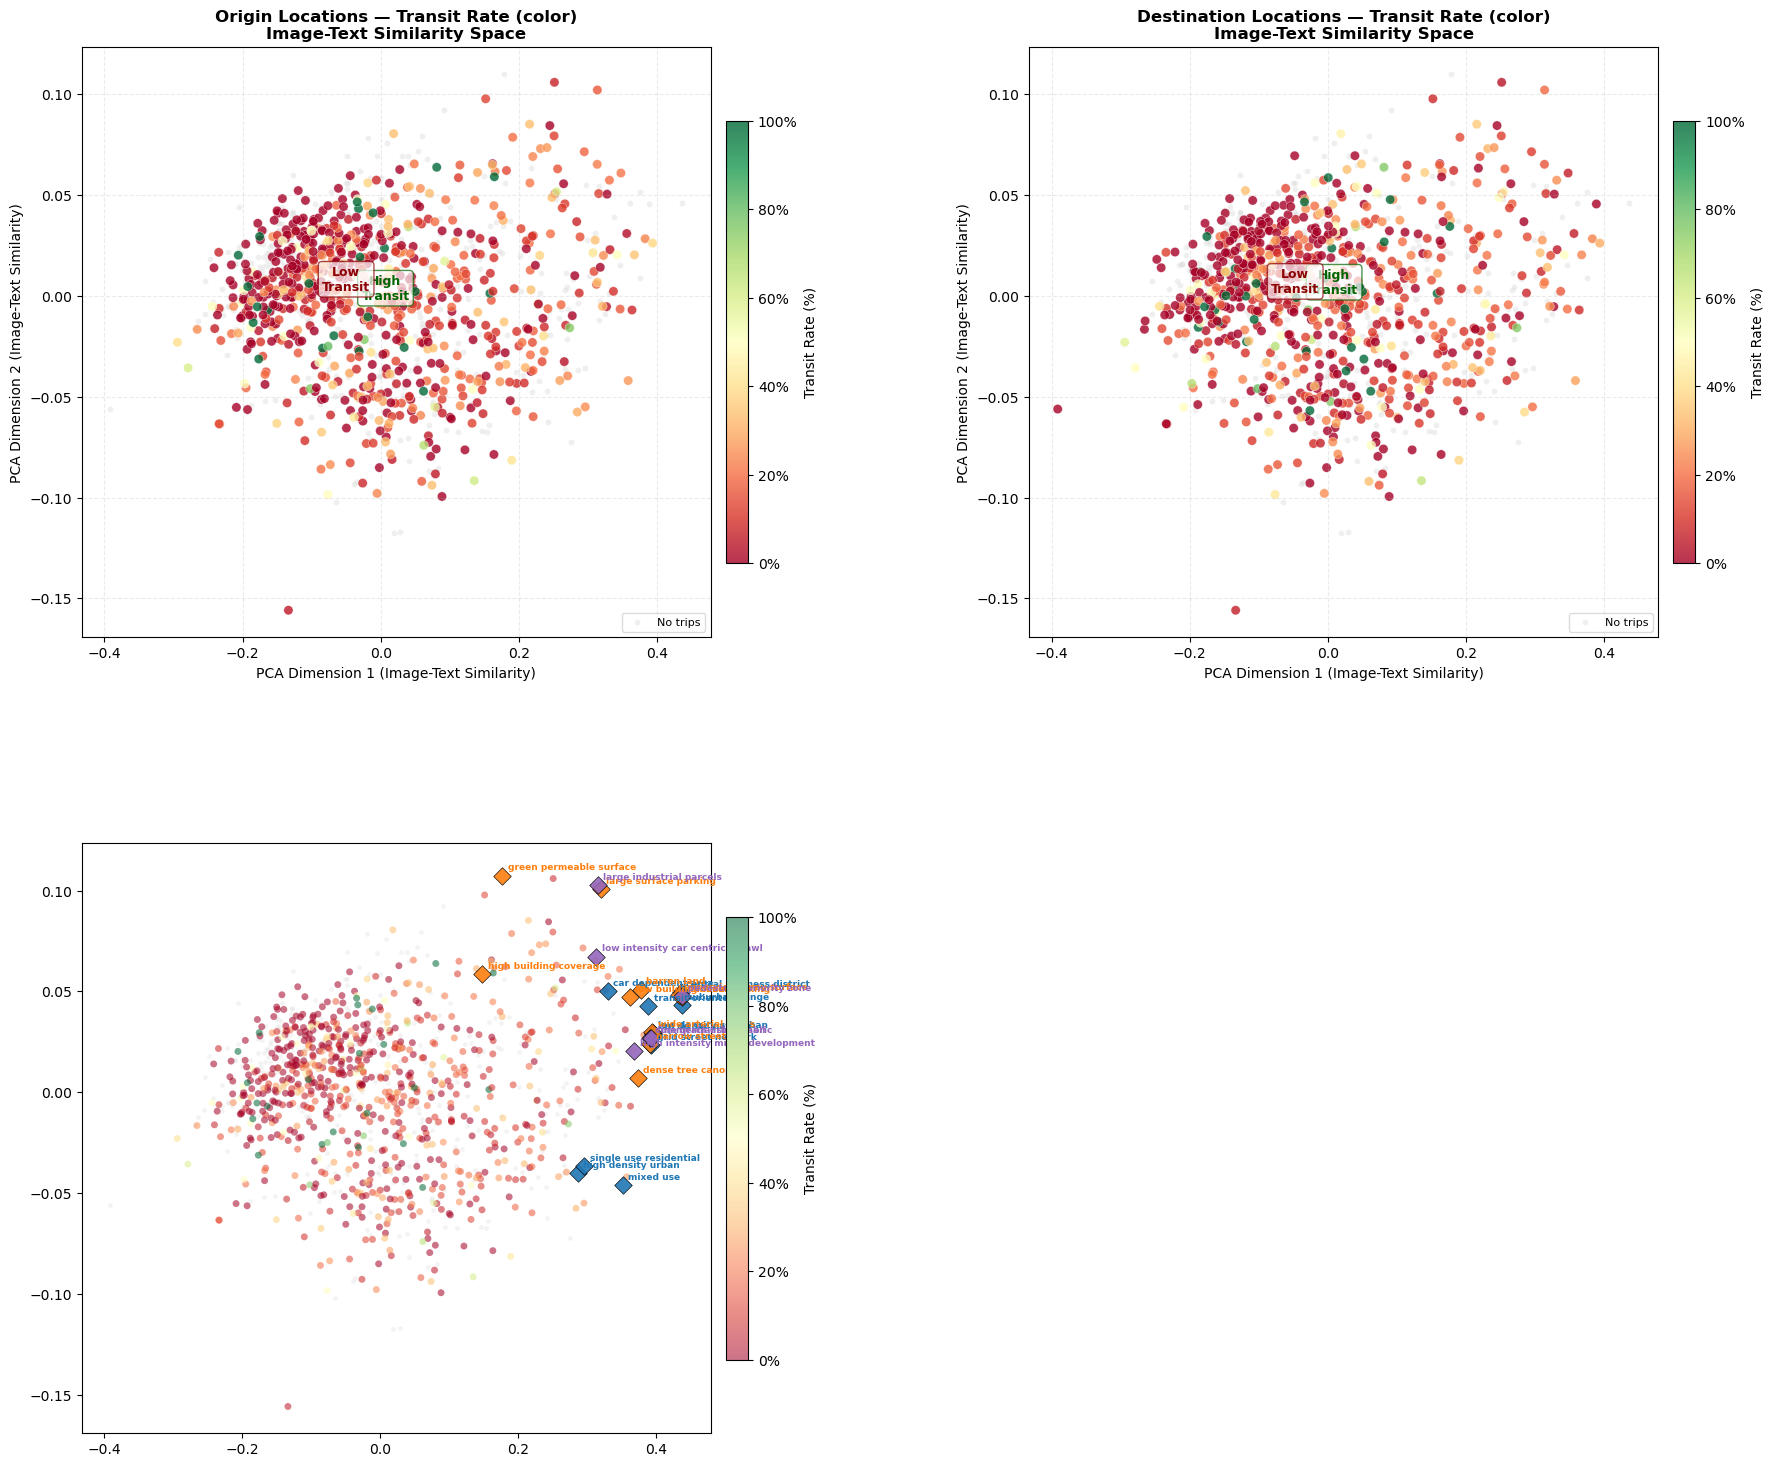

In [6]:
# ============================================================================
# STEP 8: IMAGE-TEXT JOINT SPACE VISUALIZATION
# RemoteCLIP-ViT-B/32 对齐空间内的图像-文本联合分布
# x轴/y轴 = 降维后的联合特征坐标
# 颜色     = 该 location 的 transit 使用率（作为O或D）
# ============================================================================

print(f"\n{'='*80}")
print("STEP 8: IMAGE-TEXT JOINT SPACE VISUALIZATION")
print(f"{'='*80}")

try:
    import torch
    import open_clip
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.lines import Line2D
    from matplotlib.colorbar import ColorbarBase
    import matplotlib.gridspec as gridspec
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    from huggingface_hub import hf_hub_download
    from pathlib import Path

    # 尝试加载 UMAP（更好的非线性降维），fallback 到 PCA
    try:
        import umap
        HAS_UMAP = True
        print("  ✓ UMAP available")
    except ImportError:
        HAS_UMAP = False
        print("  ⚠ UMAP not available, using PCA for dimensionality reduction")

    RC_ARCH      = 'ViT-B-32'
    TARGET_MODEL = 'remoteclip_vitb32'

    # ==========================================================================
    # [8.1] 加载 RemoteCLIP（复用或重新加载）
    # ==========================================================================

    print(f"\n[8.1] Loading RemoteCLIP-{RC_ARCH}...")

    rc_ckpt_path = hf_hub_download(
        repo_id   = "chendelong/RemoteCLIP",
        filename  = f"RemoteCLIP-{RC_ARCH}.pt",
        cache_dir = str(config.DATA_DIR / 'checkpoints')
    )

    rc_model, _, rc_preprocess = open_clip.create_model_and_transforms(RC_ARCH)
    rc_tokenizer = open_clip.get_tokenizer(RC_ARCH)

    ckpt = torch.load(rc_ckpt_path, map_location="cpu")
    if isinstance(ckpt, dict):
        ckpt = ckpt.get('state_dict', ckpt.get('model', ckpt))
    ckpt = {k.replace('module.', ''): v for k, v in ckpt.items()}
    rc_model.load_state_dict(ckpt, strict=False)
    rc_model = rc_model.cuda().eval()

    print(f"  ✓ RemoteCLIP-{RC_ARCH} ready")

    # ==========================================================================
    # [8.2] 文本概念（与 Step 7 保持一致）
    # ==========================================================================

    print(f"\n[8.2] Defining concepts and encoding texts...")

    tier1_concepts = {
        "high_density_urban":
            "Satellite view of a high-density urban area with tightly packed multi-story buildings.",
        "low_density_suburban":
            "Satellite view of a low-density suburban neighborhood with sparse single-family houses.",
        "mixed_use":
            "Aerial view of a mixed-use neighborhood combining retail shops and residential buildings.",
        "single_use_residential":
            "Aerial view of a homogeneous single-use residential neighborhood.",
        "grid_street_network":
            "Satellite image of a regular grid street network with many intersections.",
        "cul_de_sac_pattern":
            "Satellite image of cul-de-sac suburban street patterns with dead-end roads.",
        "central_business_district":
            "Aerial view of a dense central business district with office towers.",
        "suburban_fringe":
            "Satellite view of remote suburban fringe development with scattered low-rise buildings.",
        "transit_oriented":
            "Satellite view of transit-oriented development near a rail station.",
        "car_dependent_area":
            "Satellite view of car-dependent suburban sprawl with wide roads and large parking areas.",
    }

    tier2_concepts = {
        "dense_tree_canopy":
            "Satellite image showing a dense urban tree canopy covering streets and rooftops.",
        "barren_land":
            "Satellite image showing barren urban land with little vegetation or green cover.",
        "high_building_coverage":
            "Aerial image showing tight building footprints with high lot coverage.",
        "low_building_coverage":
            "Aerial image showing low building lot coverage with large open yards.",
        "minimal_parking":
            "Aerial view showing minimal surface parking lots and compact urban development.",
        "large_surface_parking":
            "Aerial view dominated by large asphalt surface parking lots.",
        "narrow_streets":
            "Aerial view of a compact neighborhood with narrow human-scale streets.",
        "wide_arterial_roads":
            "Aerial view of wide multi-lane arterial roads and highway-like corridors.",
        "green_permeable_surface":
            "Satellite image showing green permeable surfaces, parks, and vegetated open spaces.",
        "impervious_grey_surface":
            "Satellite image showing large impervious grey surfaces of concrete and asphalt.",
    }

    tier3_concepts = {
        "pedestrian_priority_zone":
            "Satellite view of a pedestrian-priority zone with wide sidewalks and compact blocks.",
        "commercial_strip_mall":
            "Satellite view of an automobile-dependent commercial strip with big-box stores.",
        "fine_grain_urban_fabric":
            "Aerial image of fine-grained urban fabric with small blocks and dense street network.",
        "large_industrial_parcels":
            "Aerial image of large industrial parcels with massive warehouse buildings.",
        "high_intensity_mixed_development":
            "Satellite image of high-intensity mixed-use development near transit.",
        "low_intensity_car_centric_sprawl":
            "Satellite image of low-intensity car-centric sprawl with fragmented land parcels.",
    }

    all_concepts = {
        **{f"T1_{k}": v for k, v in tier1_concepts.items()},
        **{f"T2_{k}": v for k, v in tier2_concepts.items()},
        **{f"T3_{k}": v for k, v in tier3_concepts.items()},
    }

    concept_names = list(all_concepts.keys())
    concept_texts = list(all_concepts.values())
    n_concepts    = len(concept_names)

    # 文本编码（官方写法）
    text_tokens = rc_tokenizer(concept_texts).cuda()
    with torch.no_grad(), torch.cuda.amp.autocast():
        text_features = rc_model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    text_features_np = text_features.cpu().float().numpy()  # (N_concepts, 512)

    print(f"  Text feature matrix : {text_features_np.shape}")

    # ==========================================================================
    # [8.3] 图像特征 & 相似度矩阵
    # ==========================================================================

    print(f"\n[8.3] Loading image embeddings and computing similarity matrix...")

    img_emb = embeddings_dict[TARGET_MODEL]['embeddings'].astype(np.float32)
    img_emb_norm = img_emb / (np.linalg.norm(img_emb, axis=1, keepdims=True) + 1e-8)

    # sim_matrix[i, j] = cosine similarity between image i and concept j
    sim_matrix = img_emb_norm @ text_features_np.T   # (N_locations, N_concepts)

    N_loc      = sim_matrix.shape[0]
    N_concepts = sim_matrix.shape[1]

    print(f"  Image embeddings    : {img_emb_norm.shape}")
    print(f"  Similarity matrix   : {sim_matrix.shape}")

    # ==========================================================================
    # [8.4] 计算每个 location 的 transit 使用率（O 和 D 分开）
    # ==========================================================================

    print(f"\n[8.4] Computing per-location transit rates (Origin & Destination)...")

    # 对每个 location，统计作为出行起点时的 transit 使用率
    transit_rate_origin = np.full(N_loc, np.nan)
    transit_rate_dest   = np.full(N_loc, np.nan)
    trip_count_origin   = np.zeros(N_loc, dtype=int)
    trip_count_dest     = np.zeros(N_loc, dtype=int)

    # df 里每行是一次出行
    for trip_i in range(len(df)):
        o_idx     = int(df.iloc[trip_i]['orig_emb_idx'])
        d_idx     = int(df.iloc[trip_i]['dest_emb_idx'])
        is_trans  = int(df.iloc[trip_i]['is_transit'])

        if 0 <= o_idx < N_loc:
            if np.isnan(transit_rate_origin[o_idx]):
                transit_rate_origin[o_idx] = 0.0
            transit_rate_origin[o_idx] += is_trans
            trip_count_origin[o_idx]   += 1

        if 0 <= d_idx < N_loc:
            if np.isnan(transit_rate_dest[d_idx]):
                transit_rate_dest[d_idx] = 0.0
            transit_rate_dest[d_idx] += is_trans
            trip_count_dest[d_idx]   += 1

    # 转为比率
    mask_o = trip_count_origin > 0
    mask_d = trip_count_dest   > 0
    transit_rate_origin[mask_o] /= trip_count_origin[mask_o]
    transit_rate_dest[mask_d]   /= trip_count_dest[mask_d]

    print(f"  Locations with origin trips : {mask_o.sum()} / {N_loc}")
    print(f"  Locations with dest trips   : {mask_d.sum()} / {N_loc}")
    print(f"  Mean transit rate (origin)  : {np.nanmean(transit_rate_origin):.3f}")
    print(f"  Mean transit rate (dest)    : {np.nanmean(transit_rate_dest):.3f}")

    # ==========================================================================
    # [8.5] 降维：在 image-text 联合空间里
    #
    # 策略：
    #   X 轴 = 图像在文本概念空间里的第1主方向（sim_matrix 的 PC1）
    #   Y 轴 = 第2主方向（PC2）
    #
    # 也可以理解为：把每张图对所有概念的相似度向量
    # （长度 = N_concepts）投影到2D
    #
    # 如果有 UMAP 则用 UMAP（保留局部结构更好）
    # ==========================================================================

    print(f"\n[8.5] Dimensionality reduction on similarity matrix...")

    # 先做一步 PCA 到 min(N_concepts, 50) 维，再给 UMAP 用
    n_pca_pre = min(n_concepts, 50, N_loc - 1)
    pca_pre   = PCA(n_components=n_pca_pre, random_state=42)
    sim_pca   = pca_pre.fit_transform(sim_matrix)   # (N_loc, n_pca_pre)

    if HAS_UMAP:
        reducer = umap.UMAP(
            n_components  = 2,
            n_neighbors   = 20,
            min_dist      = 0.1,
            metric        = 'cosine',
            random_state  = 42,
        )
        coords_2d = reducer.fit_transform(sim_pca)   # (N_loc, 2)
        method_label = "UMAP"
    else:
        pca_2d    = PCA(n_components=2, random_state=42)
        coords_2d = pca_2d.fit_transform(sim_pca)
        method_label = "PCA"

    print(f"  Reduction method : {method_label}")
    print(f"  Output shape     : {coords_2d.shape}")

    # ==========================================================================
    # [8.6] 同样对 text features 降维（投影到同一空间，用于标注）
    # ==========================================================================

    print(f"\n[8.6] Projecting text features into the same 2D space...")

    # text features 先用同一个 pca_pre 变换（它们不在 sim_matrix 空间，
    # 所以用另一种方式：把文本特征矩阵的行投影）
    # 更直接的方式：用 sim_matrix 的每列最大值对应的图像位置来近似文本位置
    # 即：text_j 的坐标 = sim_matrix[:, j] 最大的图像的坐标

    text_coords_2d = np.zeros((n_concepts, 2))
    for j in range(n_concepts):
        best_img_idx         = np.argmax(sim_matrix[:, j])
        text_coords_2d[j]    = coords_2d[best_img_idx]

    # 加一点随机扰动避免重叠
    rng = np.random.default_rng(42)
    text_coords_2d += rng.normal(0, 0.03 * coords_2d.std(), text_coords_2d.shape)

    # ==========================================================================
    # [8.7] 主可视化：O 和 D 分开，共 4 个子图
    #
    # 布局：
    #   左列 = Origin
    #   右列 = Destination
    #   上行 = 仅图像点（颜色=transit率）
    #   下行 = 图像点 + 文本概念标签
    # ==========================================================================

    print(f"\n[8.7] Drawing main visualization...")

    cmap    = plt.cm.RdYlGn        # 红(低transit) → 黄 → 绿(高transit)
    vmin, vmax = 0.0, 1.0

    # 概念点的标记颜色（按 tier）
    tier_colors = {'T1': '#1f77b4', 'T2': '#ff7f0e', 'T3': '#9467bd'}
    tier_labels = {
        'T1': 'Tier 1: 5D Built Env.',
        'T2': 'Tier 2: Satellite Physical',
        'T3': 'Tier 3: Morphological',
    }

    def short_concept_label(name):
        return (
            name.replace('T1_','').replace('T2_','').replace('T3_','')
                .replace('_',' ')
        )

    fig = plt.figure(figsize=(22, 18))
    gs  = gridspec.GridSpec(
        2, 2, figure=fig,
        hspace=0.35, wspace=0.25,
    )

    axes_specs = [
        (gs[0, 0], 'Origin',      transit_rate_origin, mask_o,
         "Origin Locations — Transit Rate (color)\nImage-Text Similarity Space"),
        (gs[0, 1], 'Destination', transit_rate_dest,   mask_d,
         "Destination Locations — Transit Rate (color)\nImage-Text Similarity Space"),
        (gs[1, 0], 'Origin + Text','origin',           mask_o,
         "Origin Locations + Text Concept Labels"),
        (gs[1, 1], 'Dest + Text',  'dest',             mask_d,
         "Destination Locations + Text Concept Labels"),
    ]

    # 保存 axes 对象供后续加 colorbar
    saved_sc = {}

    for spec in axes_specs:
        gs_cell, panel_label, transit_arr, mask, title = spec

        ax = fig.add_subplot(gs_cell)

        # --- 上行：纯图像点 ---
        if panel_label in ('Origin', 'Destination'):

            # 有 transit 数据的点
            x_valid = coords_2d[mask, 0]
            y_valid = coords_2d[mask, 1]
            c_valid = transit_arr[mask]

            # 没有 transit 数据的点（灰色背景）
            mask_no = ~mask
            ax.scatter(
                coords_2d[mask_no, 0], coords_2d[mask_no, 1],
                c='lightgrey', s=18, alpha=0.35, linewidths=0,
                label='No trips',
            )

            sc = ax.scatter(
                x_valid, y_valid,
                c=c_valid, cmap=cmap, vmin=vmin, vmax=vmax,
                s=45, alpha=0.80, linewidths=0.3, edgecolors='white',
            )
            saved_sc[panel_label] = sc

            # Colorbar
            cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
            cb.set_label('Transit Rate (%)', fontsize=10)
            cb.ax.yaxis.set_major_formatter(
                plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%")
            )

            # 标出高/低 transit 区域
            if mask.sum() > 0:
                high_thresh = np.nanpercentile(c_valid, 80)
                low_thresh  = np.nanpercentile(c_valid, 20)

                high_mask = c_valid >= high_thresh
                low_mask  = c_valid <= low_thresh

                # 椭圆标注（用 convex hull 中心近似）
                if high_mask.sum() > 3:
                    cx, cy = x_valid[high_mask].mean(), y_valid[high_mask].mean()
                    ax.annotate(
                        'High\nTransit', xy=(cx, cy),
                        fontsize=9, fontweight='bold', color='darkgreen',
                        ha='center',
                        bbox=dict(boxstyle='round,pad=0.3',
                                  facecolor='white', alpha=0.7, edgecolor='darkgreen'),
                    )

                if low_mask.sum() > 3:
                    cx, cy = x_valid[low_mask].mean(), y_valid[low_mask].mean()
                    ax.annotate(
                        'Low\nTransit', xy=(cx, cy),
                        fontsize=9, fontweight='bold', color='darkred',
                        ha='center',
                        bbox=dict(boxstyle='round,pad=0.3',
                                  facecolor='white', alpha=0.7, edgecolor='darkred'),
                    )

            ax.legend(fontsize=8, loc='lower right', framealpha=0.7)

        # --- 下行：图像点 + 文本概念 ---
        else:
            if panel_label == 'Origin + Text':
                transit_arr_row = transit_rate_origin
                mask_row        = mask_o
            else:
                transit_arr_row = transit_rate_dest
                mask_row        = mask_d

            # 图像点（半透明）
            mask_no = ~mask_row
            ax.scatter(
                coords_2d[mask_no, 0], coords_2d[mask_no, 1],
                c='lightgrey', s=12, alpha=0.25, linewidths=0,
            )
            sc2 = ax.scatter(
                coords_2d[mask_row, 0], coords_2d[mask_row, 1],
                c=transit_arr_row[mask_row],
                cmap=cmap, vmin=vmin, vmax=vmax,
                s=25, alpha=0.55, linewidths=0,
            )

            cb2 = plt.colorbar(sc2, ax=ax, shrink=0.75, pad=0.02)
            cb2.set_label('Transit Rate (%)', fontsize=10)
            cb2.ax.yaxis.set_major_formatter(
                plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%")
            )

            # 文本概念点 & 标签
            for j, cname in enumerate(concept_names):
                tier     = cname.split('_')[0]
                tc       = tier_colors.get(tier, 'black')
                tx, ty   = text_coords_2d[j]
                short    = short_concept_label(cname)

                ax.scatter(
                    tx, ty,
                    marker='D', s=80, color=tc,
                    alpha=0.90, linewidths=0.5, edgecolors='black',
                    zorder=5,
                )
                ax.annotate(
                    short, xy=(tx, ty),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=6.5, color=tc, fontweight='bold',
                    zorder=6,
                )

            # Tier legend
            legend_elements = [
                Line2D([0],[0], marker='D', color='w',
                       markerfacecolor=tc, markersize=8, label=tl)
                for tier, (tc, tl) in {
                    k: (v, tier_labels[k]) for k in tier_colors
                }.items()
            ]
            ax.legend(handles=legend_elements, fontsize=8,
                      loc='lower right', framealpha=0.8)

        ax.set_xlabel(f"{method_label} Dimension 1 (Image-Text Similarity)", fontsize=10)
        ax.set_ylabel(f"{method_label} Dimension 2 (Image-Text Similarity)", fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.25, linestyle='--')

    fig.suptitle(
        "RemoteCLIP-ViT-B/32 Image-Text Joint Space\n"
        "Each point = satellite image location  |  Color = Transit usage rate",
        fontsize=15, fontweight='bold', y=0.995,
    )

    out_main = config.OUTPUT_DIR / "rc_vitb32_imagespace_transit.png"
    plt.savefig(out_main, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f"  ✓ Saved: {out_main.name}")

    # ==========================================================================
    # [8.8] 补充图：最相关文本概念 vs transit 率（散点 + 回归线）
    #       X 轴 = 某概念的相似度（逐 location）
    #       Y 轴 = transit 率
    #       O 和 D 分开
    # ==========================================================================

    print(f"\n[8.8] Drawing concept-transit scatter plots...")

    from scipy.stats import pearsonr

    # 选相关系数绝对值最大的 top-6 概念（基于 Origin）
    corrs_o = []
    corrs_d = []

    for j in range(n_concepts):
        sims_o = sim_matrix[mask_o, j]
        rate_o = transit_rate_origin[mask_o]
        r_o, p_o = pearsonr(sims_o, rate_o) if len(sims_o) > 5 else (0, 1)

        sims_d = sim_matrix[mask_d, j]
        rate_d = transit_rate_dest[mask_d]
        r_d, p_d = pearsonr(sims_d, rate_d) if len(sims_d) > 5 else (0, 1)

        corrs_o.append((j, r_o, p_o))
        corrs_d.append((j, r_d, p_d))

    # 按 origin 相关系数的绝对值排序，取 top-6
    corrs_o_sorted = sorted(corrs_o, key=lambda x: abs(x[1]), reverse=True)
    top6_indices   = [x[0] for x in corrs_o_sorted[:6]]

    fig2, axes2 = plt.subplots(3, 4, figsize=(22, 14))
    # 3行 4列：每行一个概念，左2列=Origin，右2列=Destination
    # 但我们有6个概念，每个概念O和D各一列 → 6×2=12个子图，排成3×4

    fig2.suptitle(
        "Top Concepts: Similarity vs Transit Rate\n"
        "RemoteCLIP-ViT-B/32 | Left = Origin, Right = Destination",
        fontsize=14, fontweight='bold',
    )

    axes2_flat = axes2.flatten()

    for plot_i, concept_j in enumerate(top6_indices):
        cname     = concept_names[concept_j]
        short     = short_concept_label(cname)
        tier      = cname.split('_')[0]
        tc        = tier_colors.get(tier, 'grey')

        for od_i, (od_label, sim_vals, rate_vals, mask_od) in enumerate([
            ('Origin',      sim_matrix[:, concept_j], transit_rate_origin, mask_o),
            ('Destination', sim_matrix[:, concept_j], transit_rate_dest,   mask_d),
        ]):
            ax_idx = plot_i * 2 + od_i
            if ax_idx >= len(axes2_flat):
                break
            ax = axes2_flat[ax_idx]

            x = sim_vals[mask_od]
            y = rate_vals[mask_od]

            if len(x) < 5:
                ax.axis('off')
                continue

            r, p = pearsonr(x, y)

            # 散点，颜色=transit率
            sc = ax.scatter(
                x, y,
                c=y, cmap=cmap, vmin=0, vmax=1,
                s=35, alpha=0.70, linewidths=0.3, edgecolors='white',
            )

            # 回归线
            z   = np.polyfit(x, y, 1)
            p_  = np.poly1d(z)
            xline = np.linspace(x.min(), x.max(), 100)
            ax.plot(
                xline, p_(xline),
                color='black', linewidth=1.8,
                linestyle='--', alpha=0.8,
                label=f"r = {r:+.3f}",
            )

            # p值标记
            if p < 0.001:   sig = '***'
            elif p < 0.01:  sig = '**'
            elif p < 0.05:  sig = '*'
            elif p < 0.1:   sig = '.'
            else:           sig = 'n.s.'

            ax.set_xlabel(f"Similarity to concept", fontsize=9)
            ax.set_ylabel("Transit Rate", fontsize=9)
            ax.yaxis.set_major_formatter(
                plt.FuncFormatter(lambda val, _: f"{val*100:.0f}%")
            )
            ax.set_title(
                f"[{tier}] {short[:28]}\n{od_label} | r = {r:+.3f} {sig}",
                fontsize=9, fontweight='bold', color=tc,
            )
            ax.legend(fontsize=8, loc='upper left')
            ax.grid(True, alpha=0.25, linestyle='--')

            plt.colorbar(sc, ax=ax).set_label('Transit Rate', fontsize=8)

    plt.tight_layout()

    out_scatter = config.OUTPUT_DIR / "rc_vitb32_concept_transit_scatter.png"
    plt.savefig(out_scatter, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig2)
    print(f"  ✓ Saved: {out_scatter.name}")

    # ==========================================================================
    # [8.9] 数据表：每个 location 的坐标 + transit 率
    # ==========================================================================

    print(f"\n[8.9] Saving location data table...")

    # 每个 location 的主导概念
    dominant_concept = [concept_names[np.argmax(sim_matrix[i])] for i in range(N_loc)]
    dominant_sim     = [float(sim_matrix[i].max()) for i in range(N_loc)]

    loc_df = pd.DataFrame({
        'location_idx':       np.arange(N_loc),
        'point_id':           emb_index['point_id'].values,
        'lat':                emb_index['lat'].values,
        'lon':                emb_index['lon'].values,
        f'{method_label}_dim1': coords_2d[:, 0],
        f'{method_label}_dim2': coords_2d[:, 1],
        'transit_rate_origin': transit_rate_origin,
        'transit_rate_dest':   transit_rate_dest,
        'trip_count_origin':   trip_count_origin,
        'trip_count_dest':     trip_count_dest,
        'dominant_concept':    dominant_concept,
        'dominant_similarity': dominant_sim,
    })

    # 加上每个概念的相似度（供后续分析）
    for j, cname in enumerate(concept_names):
        loc_df[f'sim_{cname}'] = sim_matrix[:, j]

    loc_csv = config.OUTPUT_DIR / "rc_vitb32_location_imagespace.csv"
    loc_df.to_csv(loc_csv, index=False)
    print(f"  ✓ Saved location table: {loc_csv.name}")

    # ==========================================================================
    # [8.10] 打印汇总统计
    # ==========================================================================

    print(f"\n{'='*100}")
    print("CONCEPT-TRANSIT CORRELATION SUMMARY (RemoteCLIP-ViT-B/32)")
    print(f"{'='*100}")
    print(f"\n  {'Concept':<45} {'r (Origin)':>12} {'r (Dest)':>10}  {'Sig(O)':>6}  {'Sig(D)':>6}")
    print(f"  {'-'*90}")

    all_corr_rows = []
    for j in range(n_concepts):
        cname  = concept_names[j]
        r_o, p_o = corrs_o[j][1], corrs_o[j][2]
        r_d, p_d = corrs_d[j][1], corrs_d[j][2]

        def sig(p):
            if p < 0.001: return '***'
            if p < 0.01:  return '**'
            if p < 0.05:  return '*'
            if p < 0.1:   return '.'
            return 'n.s.'

        short = short_concept_label(cname)
        print(f"  {short:<45} {r_o:>+12.4f} {r_d:>+10.4f}  {sig(p_o):>6}  {sig(p_d):>6}")
        all_corr_rows.append({
            'concept_name':   cname,
            'concept_text':   concept_texts[j],
            'tier':           cname.split('_')[0],
            'r_origin':       r_o,
            'p_origin':       p_o,
            'r_dest':         r_d,
            'p_dest':         p_d,
        })

    corr_df = pd.DataFrame(all_corr_rows).sort_values('r_origin', ascending=False)
    corr_csv = config.OUTPUT_DIR / "rc_vitb32_concept_transit_correlations.csv"
    corr_df.to_csv(corr_csv, index=False)
    print(f"\n  ✓ Saved correlation table: {corr_csv.name}")

    print(f"\n{'='*80}")
    print("STEP 8 COMPLETE")
    print(f"{'='*80}")
    print(f"\n  Outputs:")
    print(f"    • rc_vitb32_imagespace_transit.png   — main 4-panel visualization")
    print(f"    • rc_vitb32_concept_transit_scatter.png — concept×transit scatter")
    print(f"    • rc_vitb32_location_imagespace.csv  — location data with coords")
    print(f"    • rc_vitb32_concept_transit_correlations.csv")

except Exception as e:
    print(f"\n✗ Step 8 failed: {e}")
    import traceback
    traceback.print_exc()

In [7]:
# ============================================================================
# STEP 8 (UPDATED): IMAGE-TEXT JOINT SPACE VISUALIZATION
# 更新内容：
#   1. 使用100个更新后的概念（T1×20 + T2×20 + T3×60）
#   2. 修复 name 'v' is not defined bug
#   3. O 和 D 分开，颜色=transit率
# ============================================================================

print(f"\n{'='*80}")
print("STEP 8 (UPDATED): IMAGE-TEXT JOINT SPACE VISUALIZATION")
print(f"{'='*80}")

try:
    import torch
    import open_clip
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from matplotlib.lines import Line2D
    from scipy.stats import pearsonr
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import normalize
    from huggingface_hub import hf_hub_download
    from pathlib import Path

    try:
        import umap
        HAS_UMAP = True
        print("  ✓ UMAP available")
    except ImportError:
        HAS_UMAP = False
        print("  ⚠ UMAP not available, using PCA")

    RC_ARCH      = 'ViT-B-32'
    TARGET_MODEL = 'remoteclip_vitb32'

    # ==========================================================================
    # [8.1] 加载 RemoteCLIP
    # ==========================================================================

    print(f"\n[8.1] Loading RemoteCLIP-{RC_ARCH}...")

    rc_ckpt_path = hf_hub_download(
        repo_id   = "chendelong/RemoteCLIP",
        filename  = f"RemoteCLIP-{RC_ARCH}.pt",
        cache_dir = str(config.DATA_DIR / 'checkpoints')
    )

    rc_model, _, rc_preprocess = open_clip.create_model_and_transforms(RC_ARCH)
    rc_tokenizer = open_clip.get_tokenizer(RC_ARCH)

    ckpt = torch.load(rc_ckpt_path, map_location="cpu")
    if isinstance(ckpt, dict):
        ckpt = ckpt.get('state_dict', ckpt.get('model', ckpt))
    ckpt = {k.replace('module.', ''): v for k, v in ckpt.items()}
    rc_model.load_state_dict(ckpt, strict=False)
    rc_model = rc_model.cuda().eval()
    print(f"  ✓ RemoteCLIP-{RC_ARCH} ready")

    # ==========================================================================
    # [8.2] 100个概念（与Step 7保持完全一致）
    # ==========================================================================

    print(f"\n[8.2] Loading 100 updated concepts...")

    # ---- Tier 1: 20个 ----
    tier1_names = [
        "high_density_towers",
        "low_density_sprawl",
        "high_far_apartments",
        "open_space_isolated_homes",
        "mixed_use_retail_residential",
        "homogeneous_suburban_tracts",
        "institutional_park_commercial_mix",
        "industrial_warehouse_estate",
        "grid_network_small_blocks",
        "cul_de_sac_disconnected",
        "pedestrian_sidewalk_trees",
        "arterial_roads_no_sidewalk",
        "urban_core_transit_hub",
        "isolated_residential_enclave",
        "cbd_dense_offices",
        "peripheral_fringe_agriculture",
        "tod_rail_station",
        "transit_desert",
        "brt_corridor",
        "car_dependent_highway",
    ]
    tier1_texts = [
        "Dense urban fabric with high-rise commercial towers and minimal setbacks",
        "Low-density residential sprawl with large private yards and scattered houses",
        "Massive apartment complexes with high floor-area ratio",
        "Vast undeveloped open space between isolated single-family homes",
        "Vibrant mixed-use block combining retail storefronts and residential rooftops",
        "Homogeneous residential monoculture with identical suburban housing tracts",
        "Integration of institutional buildings, parks, and commercial zones",
        "Vast industrial estate consisting solely of large-scale warehouses",
        "Highly connected grid street network with frequent small-block intersections",
        "Fragmented cul-de-sac street patterns with disconnected dead-ends",
        "Pedestrian-oriented streetscape with visible sidewalks and tree-lined paths",
        "Dominant multi-lane arterial roads with wide asphalt lanes and no sidewalks",
        "Strategic urban core located at the confluence of major transit corridors",
        "Isolated residential enclave far from regional employment centers",
        "Proximity to central business district with dense office clusters",
        "Peripheral fringe development surrounded by agricultural land or forests",
        "Transit-oriented development clustered around a rail or subway station",
        "Transit desert with no visible bus stops or rail infrastructure",
        "Urban corridor with dedicated bus rapid transit lanes",
        "Car-dependent landscape dominated by high-speed highway interchanges",
    ]

    # ---- Tier 2: 20个 ----
    tier2_names = [
        "dense_residential_area",
        "industrial_complex_zone",
        "urban_green_space",
        "commercial_industrial_belt",
        "major_transportation_artery",
        "forested_urban_margin",
        "airport_infrastructure",
        "port_and_harbor_area",
        "railway_corridor",
        "water_body_network",
        "bare_land_development",
        "extensive_parking_lots",
        "suburban_sprawl_pattern",
        "highway_interchange_hub",
        "coastal_shoreline_zone",
        "bridge_infrastructure",
        "farmland_urban_fringe",
        "dense_tree_canopy",
        "educational_medical_campus",
        "logistics_storage_yard",
    ]
    tier2_texts = [
        "Extensive clusters of small building roofs and narrow local streets with high building density.",
        "Large-scale factory buildings with vast, flat rooftops, often located in suburban fringes.",
        "Large patches of managed grass, parks, or vegetation integrated into the city layout.",
        "A mix of large warehouses, distribution centers, and commercial blocks with expansive footprints.",
        "Primary multi-lane highways or main roads that cut through the urban fabric.",
        "Significant woodland or groups of trees bordering developed urban or suburban areas.",
        "Large-scale paved surfaces including runways, taxiways, and terminal aprons.",
        "Deep-water coastal or riverside zones with piers, docks, and large-scale shipping facilities.",
        "Long, linear transportation corridors dedicated to rail tracks, often spanning the entire image.",
        "Rivers, canals, or large urban lakes characterized by dark, uniform spectral signatures.",
        "Large tracts of cleared earth or soil, typically representing construction sites or fallow land.",
        "Large, open paved areas dedicated to vehicle storage, appearing as textured grey blocks.",
        "Lower-density housing developments characterized by more visible vegetation between structures.",
        "Large-scale road junctions with complex looping ramps and multi-level crossings.",
        "The interface between land and sea, featuring beaches, embankments, or natural coastlines.",
        "Significant structures carrying roads or rails over water bodies or other transport lines.",
        "Large rectangular patches of agricultural land located at the edge of suburban areas.",
        "Continuous stretches of tree cover that obscure the ground, common in older suburban neighborhoods.",
        "Large, organized complexes of buildings with interconnected courtyards and green spaces.",
        "Open-air areas used for stacking containers, heavy equipment, or raw materials near industrial hubs.",
    ]

    # ---- Tier 3: 60个 ----
    tier3_names = [
        "present_organized_urban_planning",
        "absent_organized_urban_planning",
        "high_thoughtful_urban_planning",
        "low_residential_neighborhood",
        "present_residential_neighborhood",
        "absent_residential_neighborhood",
        "high_recreational_facility_urban",
        "low_recreational_amenity",
        "present_residential_and_commercial",
        "absent_residential_and_commercial",
        "high_grid_like_street_layout",
        "low_rectangular_structure",
        "high_building_commercial_activity",
        "low_arrangement_urban_planning",
        "high_commercial_zone_large_building",
        "high_community",
        "low_commercial_or_institutional",
        "low_recreational_facility_urban",
        "present_clear_demarcation_residential",
        "high_industrial_or_commercial",
        "low_recreational_component",
        "present_city",
        "high_urban_design",
        "low_recreational_space_urban",
        "present_transportation_infrastructure",
        "absent_transportation_infrastructure",
        "high_residential_structure",
        "present_institutional_building",
        "high_neighborhood",
        "present_commercial_or_institutional",
        "high_institutional_or_commercial",
        "present_residential_neighborhood_alt",
        "absent_residential_neighborhood_alt",
        "high_suburban_neighborhood",
        "low_residential_zone_open_space",
        "low_development",
        "present_residential_block",
        "absent_residential_block",
        "present_green_space",
        "absent_green_space",
        "present_large_structure",
        "absent_large_structure",
        "present_build_environment",
        "absent_build_environment",
        "present_urban_development",
        "absent_urban_development",
        "present_urban_layout",
        "absent_urban_layout",
        "present_commercial_building",
        "absent_commercial_building",
        "present_parking_lot",
        "absent_parking_lot",
        "present_urban_environment",
        "absent_urban_environment",
        "present_major_road",
        "absent_major_road",
        "present_urban_grid",
        "absent_urban_grid",
        "present_flat_roof",
        "absent_flat_roof",
    ]
    tier3_texts = [
        "Satellite view of an urban area characterized by organized urban planning, with visible thoughtful urban planning, residential neighborhood.",
        "Satellite view of an urban area with minimal or no organized urban planning, lacking visible thoughtful urban planning, residential neighborhood.",
        "Aerial image showing high concentration of thoughtful urban planning throughout the visible urban fabric, with prominent thoughtful urban planning.",
        "Aerial image showing absence of residential neighborhood in the urban fabric, with no visible thoughtful urban planning.",
        "Satellite view of an urban area characterized by residential neighborhood, with visible recreational facility urban, recreational amenity.",
        "Satellite view of an urban area with minimal or no residential neighborhood, lacking visible recreational facility urban, recreational amenity.",
        "Aerial image showing high concentration of recreational facility urban throughout the visible urban fabric, with prominent recreational facility urban.",
        "Aerial image showing absence of recreational amenity in the urban fabric, with no visible recreational facility urban.",
        "Satellite view of an urban area characterized by residential and commercial, with visible grid like street layout, rectangular structure.",
        "Satellite view of an urban area with minimal or no residential and commercial, lacking visible grid like street layout, rectangular structure.",
        "Aerial image showing high concentration of grid like street layout throughout the visible urban fabric, with prominent grid like street layout.",
        "Aerial image showing absence of rectangular structure in the urban fabric, with no visible grid like street layout.",
        "Aerial image showing high concentration of building commercial activity throughout the visible urban fabric, with prominent building commercial activity.",
        "Aerial image showing absence of arrangement urban planning in the urban fabric, with no visible building commercial activity.",
        "Aerial image showing high concentration of commercial zone large building throughout the visible urban fabric, with prominent commercial zone large building.",
        "Aerial image showing high concentration of community throughout the visible urban fabric, with prominent community.",
        "Aerial image showing absence of commercial or institutional in the urban fabric, with no visible community.",
        "Aerial image showing absence of recreational facility urban in the urban fabric, with no visible grid like street layout.",
        "Satellite view of an urban area characterized by clear demarcation residential, with visible industrial or commercial, recreational component.",
        "Aerial image showing high concentration of industrial or commercial throughout the visible urban fabric, with prominent industrial or commercial.",
        "Aerial image showing absence of recreational component in the urban fabric, with no visible industrial or commercial.",
        "Satellite view of an urban area characterized by city, with visible urban design, recreational space urban.",
        "Aerial image showing high concentration of urban design throughout the visible urban fabric, with prominent urban design.",
        "Aerial image showing absence of recreational space urban in the urban fabric, with no visible urban design.",
        "Satellite view of an urban area characterized by transportation infrastructure, with visible residential and commercial zone, industrial or commercial.",
        "Satellite view of an urban area with minimal or no transportation infrastructure, lacking visible residential and commercial zone, industrial or commercial.",
        "Aerial image showing high concentration of residential structure throughout the visible urban fabric, with prominent residential structure.",
        "Satellite view of an urban area characterized by institutional building, with visible neighborhood, urban planning residential.",
        "Aerial image showing high concentration of neighborhood throughout the visible urban fabric, with prominent neighborhood.",
        "Satellite view of an urban area characterized by commercial or institutional, with visible institutional or commercial, residential and commercial zone.",
        "Aerial image showing high concentration of institutional or commercial throughout the visible urban fabric, with prominent institutional or commercial.",
        "Satellite view of an urban area characterized by residential neighborhood, with visible suburban neighborhood, residential zone open space.",
        "Satellite view of an urban area with minimal or no residential neighborhood, lacking visible suburban neighborhood, residential zone open space.",
        "Aerial image showing high concentration of suburban neighborhood throughout the visible urban fabric, with prominent suburban neighborhood.",
        "Aerial image showing absence of residential zone open space in the urban fabric, with no visible suburban neighborhood.",
        "Aerial image showing absence of development in the urban fabric, with no visible industrial or commercial.",
        "Satellite view of an urban area with prominent residential block visible in the built environment.",
        "Satellite view of an urban area with no visible residential block in the built environment.",
        "Satellite view of an urban area with prominent green space visible in the built environment.",
        "Satellite view of an urban area with no visible green space in the built environment.",
        "Satellite view of an urban area with prominent large structure visible in the built environment.",
        "Satellite view of an urban area with no visible large structure in the built environment.",
        "Satellite view of an urban area with prominent build environment visible in the built environment.",
        "Satellite view of an urban area with no visible build environment in the built environment.",
        "Satellite view of an urban area with prominent urban development visible in the built environment.",
        "Satellite view of an urban area with no visible urban development in the built environment.",
        "Satellite view of an urban area with prominent urban layout visible in the built environment.",
        "Satellite view of an urban area with no visible urban layout in the built environment.",
        "Satellite view of an urban area with prominent commercial building visible in the built environment.",
        "Satellite view of an urban area with no visible commercial building in the built environment.",
        "Satellite view of an urban area with prominent parking lot visible in the built environment.",
        "Satellite view of an urban area with no visible parking lot in the built environment.",
        "Satellite view of an urban area with prominent urban environment visible in the built environment.",
        "Satellite view of an urban area with no visible urban environment in the built environment.",
        "Satellite view of an urban area with prominent major road visible in the built environment.",
        "Satellite view of an urban area with no visible major road in the built environment.",
        "Satellite view of an urban area with prominent urban grid visible in the built environment.",
        "Satellite view of an urban area with no visible urban grid in the built environment.",
        "Satellite view of an urban area with prominent flat roof visible in the built environment.",
        "Satellite view of an urban area with no visible flat roof in the built environment.",
    ]

    assert len(tier3_names) == 60, f"Tier3 names: {len(tier3_names)}"
    assert len(tier3_texts) == 60, f"Tier3 texts: {len(tier3_texts)}"

    # 合并成统一的 lists（不用dict推导避免变量名冲突）
    concept_names = (
        [f"T1_{n}" for n in tier1_names] +
        [f"T2_{n}" for n in tier2_names] +
        [f"T3_{n}" for n in tier3_names]
    )
    concept_texts = tier1_texts + tier2_texts + tier3_texts

    assert len(concept_names) == 100
    assert len(concept_texts) == 100

    print(f"  Tier 1: {len(tier1_names)}")
    print(f"  Tier 2: {len(tier2_names)}")
    print(f"  Tier 3: {len(tier3_names)}")
    print(f"  Total : {len(concept_names)}")

    # ==========================================================================
    # [8.3] 文本编码
    # ==========================================================================

    print(f"\n[8.3] Encoding 100 concepts with RemoteCLIP...")

    text_tokens = rc_tokenizer(concept_texts).cuda()
    with torch.no_grad(), torch.cuda.amp.autocast():
        text_features = rc_model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    text_features_np = text_features.cpu().float().numpy()
    print(f"  Text features: {text_features_np.shape}")

    # ==========================================================================
    # [8.4] 图像-文本相似度矩阵
    # ==========================================================================

    print(f"\n[8.4] Computing similarity matrix...")

    img_emb      = embeddings_dict[TARGET_MODEL]['embeddings'].astype(np.float32)
    img_emb_norm = img_emb / (np.linalg.norm(img_emb, axis=1, keepdims=True) + 1e-8)
    sim_matrix   = img_emb_norm @ text_features_np.T   # (N_loc, 100)

    N_loc = sim_matrix.shape[0]
    print(f"  Image embeddings: {img_emb_norm.shape}")
    print(f"  Sim matrix      : {sim_matrix.shape}")

    # ==========================================================================
    # [8.5] 每个location的transit率（O和D分开）
    # ==========================================================================

    print(f"\n[8.5] Computing per-location transit rates...")

    transit_rate_o = np.full(N_loc, np.nan)
    transit_rate_d = np.full(N_loc, np.nan)
    count_o        = np.zeros(N_loc, dtype=int)
    count_d        = np.zeros(N_loc, dtype=int)

    for i in range(len(df)):
        o_idx    = int(df.iloc[i]['orig_emb_idx'])
        d_idx    = int(df.iloc[i]['dest_emb_idx'])
        is_trans = int(df.iloc[i]['is_transit'])

        if 0 <= o_idx < N_loc:
            if np.isnan(transit_rate_o[o_idx]):
                transit_rate_o[o_idx] = 0.0
            transit_rate_o[o_idx] += is_trans
            count_o[o_idx] += 1

        if 0 <= d_idx < N_loc:
            if np.isnan(transit_rate_d[d_idx]):
                transit_rate_d[d_idx] = 0.0
            transit_rate_d[d_idx] += is_trans
            count_d[d_idx] += 1

    mask_o = count_o > 0
    mask_d = count_d > 0
    transit_rate_o[mask_o] /= count_o[mask_o]
    transit_rate_d[mask_d] /= count_d[mask_d]

    print(f"  Origin locations with trips : {mask_o.sum()} / {N_loc}")
    print(f"  Dest   locations with trips : {mask_d.sum()} / {N_loc}")
    print(f"  Mean transit rate (O)       : {np.nanmean(transit_rate_o):.3f}")
    print(f"  Mean transit rate (D)       : {np.nanmean(transit_rate_d):.3f}")

    # ==========================================================================
    # [8.6] 相关系数：每个概念 × transit率（O和D分开）
    # ==========================================================================

    print(f"\n[8.6] Computing concept-transit correlations...")

    corr_records = []
    for j in range(len(concept_names)):
        cname = concept_names[j]
        tier  = cname.split('_')[0]

        # Origin
        sims_o = sim_matrix[mask_o, j]
        rate_o = transit_rate_o[mask_o]
        if len(sims_o) > 5:
            r_o, p_o = pearsonr(sims_o, rate_o)
        else:
            r_o, p_o = 0.0, 1.0

        # Destination
        sims_d = sim_matrix[mask_d, j]
        rate_d = transit_rate_d[mask_d]
        if len(sims_d) > 5:
            r_d, p_d = pearsonr(sims_d, rate_d)
        else:
            r_d, p_d = 0.0, 1.0

        corr_records.append({
            'concept_idx':  j,
            'concept_name': cname,
            'concept_text': concept_texts[j],
            'tier':         tier,
            'r_origin':     r_o,
            'p_origin':     p_o,
            'r_dest':       r_d,
            'p_dest':       p_d,
            'r_mean':       (r_o + r_d) / 2,
            'abs_r_mean':   abs((r_o + r_d) / 2),
        })

    corr_df = pd.DataFrame(corr_records)
    corr_df_sorted = corr_df.sort_values('r_mean', ascending=False)

    def sig_label(p):
        if p < 0.001: return '***'
        if p < 0.01:  return '**'
        if p < 0.05:  return '*'
        if p < 0.1:   return '.'
        return 'n.s.'

    def short_label(cname):
        return (
            cname.replace('T1_','').replace('T2_','').replace('T3_','')
                 .replace('_',' ')
        )

    # 打印相关系数表
    print(f"\n  {'Concept':<45} {'Tier':>4} {'r(O)':>8} {'r(D)':>8} {'r_mean':>8}")
    print(f"  {'-'*80}")
    for _, row in corr_df_sorted.iterrows():
        print(
            f"  {short_label(row['concept_name']):<45} "
            f"{row['tier']:>4} "
            f"{row['r_origin']:>+8.4f}{sig_label(row['p_origin']):<3} "
            f"{row['r_dest']:>+8.4f}{sig_label(row['p_dest']):<3} "
            f"{row['r_mean']:>+8.4f}"
        )

    # ==========================================================================
    # [8.7] 降维（UMAP/PCA on similarity matrix）
    # ==========================================================================

    print(f"\n[8.7] Dimensionality reduction on similarity matrix...")

    n_pca_pre = min(50, len(concept_names) - 1, N_loc - 1)
    pca_pre   = PCA(n_components=n_pca_pre, random_state=42)
    sim_pca   = pca_pre.fit_transform(sim_matrix)

    if HAS_UMAP:
        import umap as umap_module
        reducer   = umap_module.UMAP(
            n_components = 2,
            n_neighbors  = 20,
            min_dist     = 0.1,
            metric       = 'cosine',
            random_state = 42,
        )
        coords_2d    = reducer.fit_transform(sim_pca)
        method_label = "UMAP"
    else:
        pca_2d       = PCA(n_components=2, random_state=42)
        coords_2d    = pca_2d.fit_transform(sim_pca)
        method_label = "PCA"

    print(f"  Method: {method_label}, output shape: {coords_2d.shape}")

    # 文本概念在2D空间的位置
    # 策略：每个概念的坐标 = 与该概念相似度最高的图像的坐标
    text_coords = np.zeros((len(concept_names), 2))
    for j in range(len(concept_names)):
        best_idx         = np.argmax(sim_matrix[:, j])
        text_coords[j]   = coords_2d[best_idx]

    rng = np.random.default_rng(42)
    text_coords += rng.normal(
        0,
        0.025 * coords_2d.std(),
        text_coords.shape
    )

    # ==========================================================================
    # [8.8] 主可视化（4个子图：O上/D上/O下+文本/D下+文本）
    # ==========================================================================

    print(f"\n[8.8] Drawing main 4-panel visualization...")

    cmap      = plt.cm.RdYlGn
    vmin, vmax = 0.0, 1.0

    # Tier颜色（直接用变量，不用dict推导）
    TIER_COLOR_T1 = '#1565c0'
    TIER_COLOR_T2 = '#e65100'
    TIER_COLOR_T3 = '#6a1b9a'

    def get_tier_color(cname):
        if cname.startswith('T1_'):
            return TIER_COLOR_T1
        elif cname.startswith('T2_'):
            return TIER_COLOR_T2
        else:
            return TIER_COLOR_T3

    fig = plt.figure(figsize=(22, 20), constrained_layout=False)

    # 手动控制间距（避免重叠）
    fig.subplots_adjust(
        left=0.06, right=0.97,
        bottom=0.04, top=0.94,
        hspace=0.45,    # 行间距
        wspace=0.30,    # 列间距
    )

    ax_o_top  = fig.add_subplot(2, 2, 1)
    ax_d_top  = fig.add_subplot(2, 2, 2)
    ax_o_bot  = fig.add_subplot(2, 2, 3)
    ax_d_bot  = fig.add_subplot(2, 2, 4)

    # ---- 辅助函数：绘制图像点 ----
    def plot_image_points(ax, transit_rate, mask, title, show_annotation=True):
        """绘制散点图（图像点，颜色=transit率）"""

        # 无出行数据的点（灰色）
        ax.scatter(
            coords_2d[~mask, 0], coords_2d[~mask, 1],
            c='#bdbdbd', s=15, alpha=0.30,
            linewidths=0, label='No trip data',
            rasterized=True,
        )

        # 有出行数据的点（颜色=transit率）
        sc = ax.scatter(
            coords_2d[mask, 0], coords_2d[mask, 1],
            c=transit_rate[mask],
            cmap=cmap, vmin=vmin, vmax=vmax,
            s=50, alpha=0.82,
            linewidths=0.4, edgecolors='white',
            rasterized=True,
        )

        # Colorbar
        cb = plt.colorbar(sc, ax=ax, shrink=0.72, pad=0.02)
        cb.set_label('Transit Rate', fontsize=9)
        cb.ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%")
        )

        # 标注高/低transit区域
        if show_annotation and mask.sum() > 0:
            rate_valid = transit_rate[mask]
            hi_thresh  = np.nanpercentile(rate_valid, 82)
            lo_thresh  = np.nanpercentile(rate_valid, 18)

            hi_mask = rate_valid >= hi_thresh
            lo_mask = rate_valid <= lo_thresh

            if hi_mask.sum() > 3:
                cx = coords_2d[mask, 0][hi_mask].mean()
                cy = coords_2d[mask, 1][hi_mask].mean()
                ax.annotate(
                    'High\nTransit',
                    xy=(cx, cy), fontsize=9, fontweight='bold',
                    color='#1b5e20', ha='center',
                    bbox=dict(boxstyle='round,pad=0.3',
                              facecolor='white', alpha=0.75,
                              edgecolor='#1b5e20', linewidth=1.2),
                )

            if lo_mask.sum() > 3:
                cx = coords_2d[mask, 0][lo_mask].mean()
                cy = coords_2d[mask, 1][lo_mask].mean()
                ax.annotate(
                    'Low\nTransit',
                    xy=(cx, cy), fontsize=9, fontweight='bold',
                    color='#b71c1c', ha='center',
                    bbox=dict(boxstyle='round,pad=0.3',
                              facecolor='white', alpha=0.75,
                              edgecolor='#b71c1c', linewidth=1.2),
                )

        ax.set_xlabel(f"{method_label} Dim 1", fontsize=10)
        ax.set_ylabel(f"{method_label} Dim 2", fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
        ax.legend(fontsize=8, loc='lower right', framealpha=0.7)
        ax.grid(True, alpha=0.22, linestyle='--')

        return sc

    # ---- 辅助函数：绘制图像点 + 文本标签 ----
    def plot_with_text_labels(ax, transit_rate, mask, title, n_labels=25):
        """绘制图像点 + top-n个文本概念标签"""

        # 图像点（半透明）
        ax.scatter(
            coords_2d[~mask, 0], coords_2d[~mask, 1],
            c='#bdbdbd', s=10, alpha=0.20,
            linewidths=0, rasterized=True,
        )
        sc = ax.scatter(
            coords_2d[mask, 0], coords_2d[mask, 1],
            c=transit_rate[mask],
            cmap=cmap, vmin=vmin, vmax=vmax,
            s=22, alpha=0.55,
            linewidths=0, rasterized=True,
        )

        cb = plt.colorbar(sc, ax=ax, shrink=0.72, pad=0.02)
        cb.set_label('Transit Rate', fontsize=9)
        cb.ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%")
        )

        # 只标注相关性最强的 n_labels 个概念
        corr_col = 'r_origin' if 'Origin' in title else 'r_dest'
        top_concepts_to_label = (
            corr_df.reindex(
                corr_df['abs_r_mean'].nlargest(n_labels).index
            )
        )

        for _, crow in top_concepts_to_label.iterrows():
            j    = int(crow['concept_idx'])
            tc   = get_tier_color(crow['concept_name'])
            tx   = text_coords[j, 0]
            ty   = text_coords[j, 1]
            slbl = short_label(crow['concept_name'])[:28]

            ax.scatter(
                tx, ty,
                marker='D', s=65, color=tc,
                alpha=0.90, linewidths=0.6,
                edgecolors='white', zorder=5,
            )
            ax.annotate(
                slbl,
                xy=(tx, ty),
                xytext=(4, 3),
                textcoords='offset points',
                fontsize=6.0, color=tc,
                fontweight='bold', zorder=6,
            )

        # Tier legend（手动构建，避免变量歧义）
        legend_handles = [
            Line2D([0],[0], marker='D', color='w',
                   markerfacecolor=TIER_COLOR_T1,
                   markersize=8, label='T1: 5D Built Env. (20)'),
            Line2D([0],[0], marker='D', color='w',
                   markerfacecolor=TIER_COLOR_T2,
                   markersize=8, label='T2: Satellite Physical (20)'),
            Line2D([0],[0], marker='D', color='w',
                   markerfacecolor=TIER_COLOR_T3,
                   markersize=8, label='T3: LLaVA Data-Driven (60)'),
        ]
        ax.legend(handles=legend_handles, fontsize=7.5,
                  loc='lower right', framealpha=0.85)

        ax.set_xlabel(f"{method_label} Dim 1", fontsize=10)
        ax.set_ylabel(f"{method_label} Dim 2", fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
        ax.grid(True, alpha=0.22, linestyle='--')

    # ---- 绘制4个子图 ----
    plot_image_points(
        ax_o_top, transit_rate_o, mask_o,
        f"(A) Origin Locations — Transit Rate\n"
        f"Image-Text Similarity Space ({method_label}, 100 concepts)",
    )
    plot_image_points(
        ax_d_top, transit_rate_d, mask_d,
        f"(B) Destination Locations — Transit Rate\n"
        f"Image-Text Similarity Space ({method_label}, 100 concepts)",
    )
    plot_with_text_labels(
        ax_o_bot, transit_rate_o, mask_o,
        f"(C) Origin + Top-25 Text Concept Labels\n"
        f"◆ = RemoteCLIP text features (by |r| with transit)",
        n_labels=25,
    )
    plot_with_text_labels(
        ax_d_bot, transit_rate_d, mask_d,
        f"(D) Destination + Top-25 Text Concept Labels\n"
        f"◆ = RemoteCLIP text features (by |r| with transit)",
        n_labels=25,
    )

    fig.suptitle(
        "RemoteCLIP-ViT-B/32 Image-Text Aligned Space\n"
        "100 Concepts: T1×20 (5D Built Env.) + T2×20 (Satellite Physical) "
        "+ T3×60 (LLaVA Data-Driven)\n"
        "Each point = satellite image location  |  Color = Transit usage rate",
        fontsize=13, fontweight='bold', y=0.975,
    )

    out_main = config.OUTPUT_DIR / "rc_vitb32_v2_imagespace.png"
    plt.savefig(out_main, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f"  ✓ Saved: {out_main.name}")

    # ==========================================================================
    # [8.9] 补充图：Top概念×transit率散点（O和D分开，按tier分组）
    # ==========================================================================

    print(f"\n[8.9] Drawing concept-transit scatter plots by tier...")

    # 每个tier选top-4（按abs r_mean）
    top_per_tier = {}
    for tier_label in ['T1', 'T2', 'T3']:
        tier_sub = corr_df[corr_df['tier'] == tier_label]
        top4     = tier_sub.nlargest(4, 'abs_r_mean')
        top_per_tier[tier_label] = top4

    # 3 tiers × 4 concepts × 2 (O/D) → 3行 8列 → 太密
    # 改为：3行 × 4列，每格显示O和D两个回归线

    fig2, axes2 = plt.subplots(
        3, 4,
        figsize=(22, 16),
        constrained_layout=True,
    )
    fig2.suptitle(
        "Top Concepts per Tier: Similarity vs Transit Rate\n"
        "RemoteCLIP-ViT-B/32 | Solid line = Origin, Dashed = Destination",
        fontsize=13, fontweight='bold',
    )

    tier_labels_display = {
        'T1': ('5D Built Environment', TIER_COLOR_T1),
        'T2': ('Satellite Physical',   TIER_COLOR_T2),
        'T3': ('LLaVA Data-Driven',   TIER_COLOR_T3),
    }

    for row_i, tier_label in enumerate(['T1', 'T2', 'T3']):
        tier_display, tier_color = tier_labels_display[tier_label]
        top4 = top_per_tier[tier_label]

        for col_i, (_, crow) in enumerate(top4.iterrows()):
            ax = axes2[row_i, col_i]
            j  = int(crow['concept_idx'])

            slbl = short_label(crow['concept_name'])

            # Origin
            x_o = sim_matrix[mask_o, j]
            y_o = transit_rate_o[mask_o]

            # Destination
            x_d = sim_matrix[mask_d, j]
            y_d = transit_rate_d[mask_d]

            # 散点（半透明）
            ax.scatter(
                x_o, y_o,
                c=tier_color, s=20, alpha=0.35,
                linewidths=0, label='_nolegend_',
                rasterized=True,
            )
            ax.scatter(
                x_d, y_d,
                c=tier_color, s=20, alpha=0.20,
                linewidths=0, marker='s',
                label='_nolegend_',
                rasterized=True,
            )

            # 回归线 Origin
            if len(x_o) > 5:
                r_o, p_o = pearsonr(x_o, y_o)
                z_o      = np.polyfit(x_o, y_o, 1)
                xline    = np.linspace(x_o.min(), x_o.max(), 80)
                ax.plot(
                    xline, np.poly1d(z_o)(xline),
                    color=tier_color, linewidth=2.0,
                    linestyle='-', alpha=0.9,
                    label=f"Origin r={r_o:+.3f}{sig_label(p_o)}",
                )

            # 回归线 Destination
            if len(x_d) > 5:
                r_d, p_d = pearsonr(x_d, y_d)
                z_d      = np.polyfit(x_d, y_d, 1)
                xline_d  = np.linspace(x_d.min(), x_d.max(), 80)
                ax.plot(
                    xline_d, np.poly1d(z_d)(xline_d),
                    color=tier_color, linewidth=2.0,
                    linestyle='--', alpha=0.7,
                    label=f"Dest   r={r_d:+.3f}{sig_label(p_d)}",
                )

            ax.yaxis.set_major_formatter(
                plt.FuncFormatter(lambda val, _: f"{val*100:.0f}%")
            )
            ax.set_xlabel("Concept Similarity Score", fontsize=9)
            ax.set_ylabel("Transit Rate", fontsize=9)
            ax.set_title(
                f"[{tier_label}] {slbl[:30]}",
                fontsize=9, fontweight='bold', color=tier_color,
            )
            ax.legend(fontsize=7.5, loc='best', framealpha=0.8)
            ax.grid(True, alpha=0.22, linestyle='--')

    out_scatter = config.OUTPUT_DIR / "rc_vitb32_v2_scatter_by_tier.png"
    plt.savefig(out_scatter, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig2)
    print(f"  ✓ Saved: {out_scatter.name}")

    # ==========================================================================
    # [8.10] 相关系数汇总热图（100个概念 × O/D）
    # ==========================================================================

    print(f"\n[8.10] Drawing correlation heatmap...")

    # 按 tier 和 r_mean 排序
    corr_sorted = pd.concat([
        corr_df[corr_df['tier'] == 'T1'].sort_values('r_mean', ascending=False),
        corr_df[corr_df['tier'] == 'T2'].sort_values('r_mean', ascending=False),
        corr_df[corr_df['tier'] == 'T3'].sort_values('r_mean', ascending=False),
    ]).reset_index(drop=True)

    # 热图数据：(100, 2)
    heatmap_data = corr_sorted[['r_origin', 'r_dest']].values
    ylabels      = [
        f"[{row['tier']}] {short_label(row['concept_name'])[:35]}"
        for _, row in corr_sorted.iterrows()
    ]

    fig3, ax3 = plt.subplots(figsize=(8, 28), constrained_layout=True)

    im = ax3.imshow(
        heatmap_data,
        aspect='auto',
        cmap='RdBu_r',
        vmin=-0.3, vmax=0.3,
    )

    ax3.set_xticks([0, 1])
    ax3.set_xticklabels(['Origin', 'Destination'], fontsize=12, fontweight='bold')
    ax3.set_yticks(range(len(ylabels)))
    ax3.set_yticklabels(ylabels, fontsize=7.0)

    # Tier 分隔线
    n_t1 = (corr_sorted['tier'] == 'T1').sum()
    n_t2 = (corr_sorted['tier'] == 'T2').sum()
    ax3.axhline(n_t1 - 0.5, color='black', linewidth=1.5)
    ax3.axhline(n_t1 + n_t2 - 0.5, color='black', linewidth=1.5)

    # Tier 标签
    ax3.text(2.0, n_t1 / 2,
             'T1\n5D Built Env.',
             va='center', ha='left', fontsize=9,
             color=TIER_COLOR_T1, fontweight='bold',
             transform=ax3.get_yaxis_transform())
    ax3.text(2.0, n_t1 + n_t2 / 2,
             'T2\nSatellite Physical',
             va='center', ha='left', fontsize=9,
             color=TIER_COLOR_T2, fontweight='bold',
             transform=ax3.get_yaxis_transform())
    ax3.text(2.0, n_t1 + n_t2 + (corr_sorted['tier'] == 'T3').sum() / 2,
             'T3\nLLaVA Derived',
             va='center', ha='left', fontsize=9,
             color=TIER_COLOR_T3, fontweight='bold',
             transform=ax3.get_yaxis_transform())

    plt.colorbar(im, ax=ax3, shrink=0.3, pad=0.01,
                 label='Pearson r with Transit Rate')
    ax3.set_title(
        "Concept-Transit Correlations\n100 Concepts × {Origin, Destination}",
        fontsize=12, fontweight='bold',
    )

    out_heatmap = config.OUTPUT_DIR / "rc_vitb32_v2_correlation_heatmap.png"
    plt.savefig(out_heatmap, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig3)
    print(f"  ✓ Saved: {out_heatmap.name}")

    # ==========================================================================
    # [8.11] 保存数据表
    # ==========================================================================

    print(f"\n[8.11] Saving data tables...")

    # 相关系数表
    corr_csv = config.OUTPUT_DIR / "rc_vitb32_v2_concept_correlations.csv"
    corr_df.sort_values('r_mean', ascending=False).to_csv(corr_csv, index=False)
    print(f"  ✓ {corr_csv.name}")

    # location级别数据表（含坐标和transit率）
    dominant_concept = [
        concept_names[int(np.argmax(sim_matrix[i]))]
        for i in range(N_loc)
    ]
    dominant_sim_val = [
        float(sim_matrix[i].max())
        for i in range(N_loc)
    ]

    loc_df = pd.DataFrame({
        'location_idx':        np.arange(N_loc),
        'point_id':            emb_index['point_id'].values,
        'lat':                 emb_index['lat'].values,
        'lon':                 emb_index['lon'].values,
        f'{method_label}_dim1':coords_2d[:, 0],
        f'{method_label}_dim2':coords_2d[:, 1],
        'transit_rate_origin': transit_rate_o,
        'transit_rate_dest':   transit_rate_d,
        'trip_count_origin':   count_o,
        'trip_count_dest':     count_d,
        'dominant_concept':    dominant_concept,
        'dominant_similarity': dominant_sim_val,
    })

    loc_csv = config.OUTPUT_DIR / "rc_vitb32_v2_location_data.csv"
    loc_df.to_csv(loc_csv, index=False)
    print(f"  ✓ {loc_csv.name}")

    # ==========================================================================
    # [8.12] 打印汇总统计
    # ==========================================================================

    print(f"\n{'='*100}")
    print("STEP 8 CONCEPT-TRANSIT CORRELATION SUMMARY")
    print(f"{'='*100}")

    for tier_lbl in ['T1', 'T2', 'T3']:
        sub = corr_df[corr_df['tier'] == tier_lbl].sort_values('r_mean', ascending=False)
        print(f"\n  {tier_lbl} — {tier_labels_display[tier_lbl][0]} ({len(sub)} concepts)")
        print(f"  {'Concept':<45} {'r(O)':>10} {'r(D)':>10} {'r_mean':>10}")
        print(f"  {'-'*78}")
        for _, row in sub.iterrows():
            print(
                f"  {short_label(row['concept_name']):<45} "
                f"{row['r_origin']:>+10.4f} "
                f"{row['r_dest']:>+10.4f} "
                f"{row['r_mean']:>+10.4f}"
            )

    print(f"\n{'='*80}")
    print("STEP 8 (UPDATED) COMPLETE")
    print(f"{'='*80}")
    print(f"\n  Outputs:")
    print(f"    • rc_vitb32_v2_imagespace.png          — 4-panel main figure")
    print(f"    • rc_vitb32_v2_scatter_by_tier.png     — scatter plots by tier")
    print(f"    • rc_vitb32_v2_correlation_heatmap.png — 100×2 heatmap")
    print(f"    • rc_vitb32_v2_concept_correlations.csv")
    print(f"    • rc_vitb32_v2_location_data.csv")

except Exception as e:
    print(f"\n✗ Step 8 failed: {e}")
    import traceback
    traceback.print_exc()


STEP 8 (UPDATED): IMAGE-TEXT JOINT SPACE VISUALIZATION


  ✓ UMAP available

[8.1] Loading RemoteCLIP-ViT-B-32...


  ✓ RemoteCLIP-ViT-B-32 ready

[8.2] Loading 100 updated concepts...
  Tier 1: 20
  Tier 2: 20
  Tier 3: 60
  Total : 100

[8.3] Encoding 100 concepts with RemoteCLIP...
  Text features: (100, 512)

[8.4] Computing similarity matrix...
  Image embeddings: (1148, 512)
  Sim matrix      : (1148, 100)

[8.5] Computing per-location transit rates...
  Origin locations with trips : 776 / 1148
  Dest   locations with trips : 801 / 1148
  Mean transit rate (O)       : 0.155
  Mean transit rate (D)       : 0.163

[8.6] Computing concept-transit correlations...

  Concept                                       Tier     r(O)     r(D)   r_mean
  --------------------------------------------------------------------------------
  tod rail station                                T1  +0.1078**   +0.1047**   +0.1063
  transit desert                                  T1  +0.1130**   +0.0849*    +0.0989
  bridge infrastructure                           T2  +0.1100**   +0.0787*    +0.0943
  brt corridor      

In [8]:
# ============================================================================
# TIER 3 CONCEPT GENERATION: DATA-DRIVEN FROM LLaVA DESCRIPTIONS
# 真正从数据中提取概念，而非人工定义
# Pipeline:
#   1. 读取所有LLaVA描述
#   2. NLP提取名词短语/形容词短语
#   3. TF-IDF + 语义聚类
#   4. 每个cluster自动生成代表性概念
#   5. 转化为RemoteCLIP-compatible prompt
# ============================================================================

print(f"\n{'='*80}")
print("DATA-DRIVEN TIER 3 CONCEPT GENERATION FROM LLaVA DESCRIPTIONS")
print(f"{'='*80}")

# ============================================================================
# 安装检查
# ============================================================================

import subprocess, sys

def check_install(package, import_name=None):
    import_name = import_name or package
    try:
        __import__(import_name)
        return True
    except ImportError:
        print(f"  Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        return False

check_install('spacy')
check_install('scikit-learn', 'sklearn')
check_install('umap-learn', 'umap')
check_install('sentence-transformers', 'sentence_transformers')

# 下载 spacy 模型
try:
    import spacy
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("  Downloading spacy model...")
    subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm', '-q'])
    import spacy
    nlp = spacy.load('en_core_web_sm')

import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
import re
import warnings
warnings.filterwarnings('ignore')

print("  ✓ All packages ready")

# ============================================================================
# [1] 读取所有 LLaVA 描述
# ============================================================================

print(f"\n[1] Loading LLaVA descriptions...")

jsonl_path = Path('./final_foundation_analysis_output2/remote_sensing_descriptions.jsonl')

records = []
with open(jsonl_path, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            continue

print(f"  Loaded {len(records)} image descriptions")

responses    = [r['response'] for r in records]
image_files  = [r['image_filename'] for r in records]

# ============================================================================
# [2] NLP 提取：名词短语 + 形容词+名词短语
#     这些是描述视觉特征的核心语言单位
# ============================================================================

print(f"\n[2] Extracting noun phrases and adjectival phrases via spaCy NLP...")

def extract_visual_phrases(text, nlp):
    """
    从一段描述中提取视觉相关的名词短语。
    过滤掉过于通用的词。
    """
    doc = nlp(text.lower())

    phrases = []

    # 提取名词块 (noun chunks)
    for chunk in doc.noun_chunks:
        # 过滤：长度2-6词，不含代词
        words = [t for t in chunk if t.pos_ not in ('DET', 'PRON', 'PUNCT')]
        if 2 <= len(words) <= 6:
            phrase = ' '.join([t.lemma_ for t in words])
            phrases.append(phrase)

    # 提取 ADJ + NOUN 模式
    tokens = list(doc)
    for i, tok in enumerate(tokens[:-1]):
        if tok.pos_ == 'ADJ' and tokens[i+1].pos_ == 'NOUN':
            phrase = f"{tok.lemma_} {tokens[i+1].lemma_}"
            phrases.append(phrase)

    return phrases

# 通用词过滤表（与built environment无关）
STOPWORDS_DOMAIN = {
    'image', 'area', 'view', 'side', 'part', 'section',
    'aspect', 'feature', 'element', 'thing', 'way', 'type',
    'sense', 'use', 'focus', 'evidence', 'description',
    'perspective', 'overall', 'setting', 'configuration',
    'presence', 'absence', 'variety', 'number', 'example',
    'pattern', 'detail', 'term', 'context', 'factor',
}

all_doc_phrases = []     # 每个文档的短语列表（用于TF-IDF）
all_phrases_flat = []    # 所有短语（用于频率统计）

for resp in responses:
    phrases = extract_visual_phrases(resp, nlp)
    # 过滤通用词
    phrases = [
        p for p in phrases
        if not any(sw in p.split() for sw in STOPWORDS_DOMAIN)
        and len(p) > 4
    ]
    all_doc_phrases.append(phrases)
    all_phrases_flat.extend(phrases)

# 短语频率统计
phrase_counter = Counter(all_phrases_flat)

print(f"  Total unique phrases extracted: {len(phrase_counter)}")
print(f"  Top 30 most frequent phrases:")

top30 = phrase_counter.most_common(30)
for phrase, count in top30:
    print(f"    {count:>4}x  '{phrase}'")

# ============================================================================
# [3] TF-IDF 文档表示
#     把每个 LLaVA 描述转换为短语的 TF-IDF 向量
#     这样可以找到每个文档的"特征性"短语（高TF-IDF=对该文档独特）
# ============================================================================

print(f"\n[3] Building TF-IDF representation of descriptions...")

# 把每个文档的短语列表转成字符串（供TF-IDF处理）
docs_as_phrase_strings = [' '.join(phrases) for phrases in all_doc_phrases]

# TF-IDF
tfidf = TfidfVectorizer(
    ngram_range    = (1, 3),
    min_df         = 3,           # 至少出现在3个文档中
    max_df         = 0.85,        # 不超过85%的文档（太通用的排除）
    max_features   = 500,
    token_pattern  = r'\b[a-z][a-z\s]{2,30}\b',
)

tfidf_matrix = tfidf.fit_transform(docs_as_phrase_strings)
vocab        = tfidf.get_feature_names_out()

print(f"  TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  Vocabulary size: {len(vocab)}")
print(f"  Top TF-IDF terms (by avg score):")

avg_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_tfidf_idx = np.argsort(avg_tfidf)[-20:][::-1]
for idx in top_tfidf_idx:
    print(f"    {avg_tfidf[idx]:.4f}  '{vocab[idx]}'")

# ============================================================================
# [4] 语义嵌入：用 Sentence-BERT 把每个文档编码成语义向量
#     比TF-IDF更能捕捉语义相似性
# ============================================================================

print(f"\n[4] Computing semantic embeddings with Sentence-BERT...")

sbert = SentenceTransformer('all-MiniLM-L6-v2')

# 编码所有描述
doc_embeddings = sbert.encode(
    responses,
    batch_size    = 32,
    show_progress_bar = True,
    convert_to_numpy  = True,
)

print(f"  Document embeddings shape: {doc_embeddings.shape}")

# 归一化
doc_embeddings_norm = normalize(doc_embeddings, norm='l2')

# ============================================================================
# [5] 聚类：找到描述中自然出现的视觉模式组
#     用 K-Means 聚类（K=15，对应15组概念）
#     每个cluster代表一类视觉场景
# ============================================================================

print(f"\n[5] Clustering descriptions into visual pattern groups...")

N_CLUSTERS = 15    # 15个cluster → 每个cluster生成4个概念 → 60个总计

kmeans = KMeans(
    n_clusters    = N_CLUSTERS,
    n_init        = 20,
    max_iter      = 500,
    random_state  = 42,
)
cluster_labels = kmeans.fit_predict(doc_embeddings_norm)

# 统计每个cluster的大小
cluster_sizes = Counter(cluster_labels)
print(f"  Cluster size distribution:")
for c in range(N_CLUSTERS):
    print(f"    Cluster {c:>2}: {cluster_sizes[c]:>3} images")

# ============================================================================
# [6] 每个Cluster的关键词提取
#     对每个cluster，用cluster内文档的TF-IDF均值找最具代表性的短语
# ============================================================================

print(f"\n[6] Extracting representative phrases per cluster...")

cluster_info = {}    # cluster_id → 信息

for c in range(N_CLUSTERS):
    mask = cluster_labels == c

    # 该cluster内的文档
    cluster_responses = [responses[i] for i in range(len(responses)) if mask[i]]

    # 该cluster的TF-IDF向量均值
    cluster_tfidf_mean = np.asarray(
        tfidf_matrix[mask].mean(axis=0)
    ).flatten()

    # top 关键短语
    top_phrase_idx = np.argsort(cluster_tfidf_mean)[-15:][::-1]
    top_phrases    = [(vocab[i], cluster_tfidf_mean[i]) for i in top_phrase_idx
                      if cluster_tfidf_mean[i] > 0]

    # 该cluster的中心响应（最接近centroid的文档）
    cluster_embs   = doc_embeddings_norm[mask]
    centroid       = cluster_embs.mean(axis=0)
    dists          = np.linalg.norm(cluster_embs - centroid, axis=1)
    center_local   = np.argmin(dists)
    center_global  = np.where(mask)[0][center_local]

    cluster_info[c] = {
        'size':            mask.sum(),
        'top_phrases':     top_phrases,
        'center_response': responses[center_global],
        'center_file':     image_files[center_global],
        'cluster_responses': cluster_responses[:3],    # 前3个作为示例
    }

    print(f"\n  Cluster {c:>2} (n={mask.sum():>3})")
    print(f"    Top phrases: {', '.join([p[0] for p in top_phrases[:8]])}")
    print(f"    Example: {cluster_responses[0][:100]}...")

# ============================================================================
# [7] 自动生成概念名称和Prompt
#     策略：
#       - 用cluster的top短语作为概念核心
#       - 自动生成正向（高分特征）和负向（低分特征）版本
#       - 每个cluster生成4个概念（2正+2负）
# ============================================================================

print(f"\n[7] Auto-generating concept names and RemoteCLIP prompts...")

def phrase_to_concept_key(phrase):
    """把短语转化为合法的 Python key"""
    key = re.sub(r'[^a-z0-9\s]', '', phrase.lower())
    key = '_'.join(key.split())
    key = key[:40]    # 限制长度
    return key

def build_positive_prompt(phrase, supporting_phrases):
    """生成正向概念的RemoteCLIP prompt"""
    support = ', '.join([p[0] for p in supporting_phrases[:2]])
    return (
        f"Satellite view of an urban area characterized by {phrase}, "
        f"with visible {support}."
    )

def build_negative_prompt(phrase, supporting_phrases):
    """生成负向概念的RemoteCLIP prompt（absent/minimal）"""
    support = ', '.join([p[0] for p in supporting_phrases[:2]])
    return (
        f"Satellite view of an urban area with minimal or no {phrase}, "
        f"lacking visible {support}."
    )

def build_high_prompt(phrase, supporting_phrases):
    """生成高强度版本"""
    support = supporting_phrases[0][0] if supporting_phrases else "related features"
    return (
        f"Aerial image showing high concentration of {phrase} "
        f"throughout the visible urban fabric, with prominent {support}."
    )

def build_low_prompt(phrase, supporting_phrases):
    """生成低强度版本"""
    support = supporting_phrases[0][0] if supporting_phrases else "related features"
    return (
        f"Aerial image showing absence of {phrase} "
        f"in the urban fabric, with no visible {support}."
    )

# 生成所有概念
generated_concepts = {}    # key → prompt
concept_metadata   = []    # 记录每个概念的来源

for c in range(N_CLUSTERS):
    info         = cluster_info[c]
    top_phrases  = info['top_phrases']

    if not top_phrases:
        print(f"  ⚠ Cluster {c}: no phrases, skipping")
        continue

    # 主特征短语（TF-IDF最高）
    main_phrase  = top_phrases[0][0]
    support      = top_phrases[1:]

    # 生成4个概念
    concepts_this_cluster = [
        (f"c{c:02d}_present_{phrase_to_concept_key(main_phrase)}",
         build_positive_prompt(main_phrase, support)),

        (f"c{c:02d}_absent_{phrase_to_concept_key(main_phrase)}",
         build_negative_prompt(main_phrase, support)),

        (f"c{c:02d}_high_{phrase_to_concept_key(top_phrases[1][0] if len(top_phrases)>1 else main_phrase)}",
         build_high_prompt(top_phrases[1][0] if len(top_phrases)>1 else main_phrase, support)),

        (f"c{c:02d}_low_{phrase_to_concept_key(top_phrases[2][0] if len(top_phrases)>2 else main_phrase)}",
         build_low_prompt(top_phrases[2][0] if len(top_phrases)>2 else main_phrase, support)),
    ]

    for key, prompt in concepts_this_cluster:
        generated_concepts[key] = prompt
        concept_metadata.append({
            'concept_key':    key,
            'concept_text':   prompt,
            'source_cluster': c,
            'cluster_size':   info['size'],
            'main_phrase':    main_phrase,
            'top_phrases':    '; '.join([p[0] for p in top_phrases[:5]]),
            'polarity':       'positive' if 'present' in key or 'high' in key else 'negative',
            'tier':           'T3',
            'generation_method': 'data_driven_llava_kmeans',
        })

print(f"\n  Generated {len(generated_concepts)} concepts from {N_CLUSTERS} clusters")

# ============================================================================
# [8] 质量控制：去除重复和低质量概念
# ============================================================================

print(f"\n[8] Quality control: deduplication and filtering...")

# 用 SBERT 计算概念间相似度，去除过于相似的概念
concept_keys_list  = list(generated_concepts.keys())
concept_texts_list = list(generated_concepts.values())

concept_embeddings = sbert.encode(
    concept_texts_list,
    show_progress_bar = False,
    convert_to_numpy  = True,
)
concept_emb_norm = normalize(concept_embeddings, norm='l2')

# 计算pairwise相似度
sim_matrix_concepts = concept_emb_norm @ concept_emb_norm.T

# 贪心去重：如果两个概念相似度 > 0.92，保留TF-IDF分更高的那个
DEDUP_THRESHOLD = 0.92
kept_indices    = []
dropped         = set()

for i in range(len(concept_texts_list)):
    if i in dropped:
        continue
    kept_indices.append(i)
    for j in range(i+1, len(concept_texts_list)):
        if j not in dropped and sim_matrix_concepts[i, j] > DEDUP_THRESHOLD:
            dropped.add(j)

print(f"  Before dedup: {len(generated_concepts)}")
print(f"  After dedup:  {len(kept_indices)}")
print(f"  Dropped:      {len(dropped)}")

# 最终概念字典
tier3_concepts_final = {
    concept_keys_list[i]: concept_texts_list[i]
    for i in kept_indices
}

# ============================================================================
# [9] 如果不足60个，用高频短语补充；如果超过60个，按质量截断
# ============================================================================

print(f"\n[9] Adjusting to target 60 concepts...")

current_n = len(tier3_concepts_final)
print(f"  Current count: {current_n}, target: 60")

if current_n < 60:
    # 补充：用top频率短语生成额外概念
    print(f"  Supplementing with {60 - current_n} additional concepts from frequent phrases...")

    extra_phrases = [
        p for p, count in phrase_counter.most_common(200)
        if p not in ' '.join(tier3_concepts_final.values())
        and len(p.split()) >= 2
        and count >= 3
    ]

    added = 0
    for phrase in extra_phrases:
        if len(tier3_concepts_final) >= 60:
            break

        key_pos = f"supp_present_{phrase_to_concept_key(phrase)}"
        key_neg = f"supp_absent_{phrase_to_concept_key(phrase)}"

        if key_pos not in tier3_concepts_final:
            tier3_concepts_final[key_pos] = (
                f"Satellite view of an urban area with prominent {phrase} "
                f"visible in the built environment."
            )
            added += 1

        if len(tier3_concepts_final) >= 60:
            break

        if key_neg not in tier3_concepts_final:
            tier3_concepts_final[key_neg] = (
                f"Satellite view of an urban area with no visible {phrase} "
                f"in the built environment."
            )
            added += 1

    print(f"  Added {added} supplementary concepts")

elif current_n > 60:
    # 截断：按cluster size降序保留（大cluster的概念更representative）
    print(f"  Truncating from {current_n} to 60...")

    meta_df   = pd.DataFrame(concept_metadata)
    kept_keys = set(concept_keys_list[i] for i in kept_indices)
    meta_kept = meta_df[meta_df['concept_key'].isin(kept_keys)].copy()

    # 按cluster size降序，每个cluster保持2正2负的平衡
    meta_kept = meta_kept.sort_values('cluster_size', ascending=False)

    selected_keys = list(meta_kept['concept_key'])[:60]
    tier3_concepts_final = {
        k: tier3_concepts_final[k]
        for k in selected_keys
        if k in tier3_concepts_final
    }

print(f"  Final count: {len(tier3_concepts_final)}")

# ============================================================================
# [10] 打印最终结果
# ============================================================================

print(f"\n{'='*80}")
print("FINAL DATA-DRIVEN TIER 3 CONCEPTS (60 total)")
print(f"{'='*80}")

for i, (key, text) in enumerate(tier3_concepts_final.items(), 1):
    cluster_num = key.split('_')[0]
    print(f"\n  [{i:>2}] {key}")
    print(f"        {text}")

# ============================================================================
# [11] 保存结果
# ============================================================================

print(f"\n{'='*80}")
print("SAVING RESULTS")
print(f"{'='*80}")

output_dir = config.OUTPUT_DIR if 'config' in dir() else Path('./output')
output_dir = Path(output_dir)
output_dir.mkdir(exist_ok=True)

# JSON
json_path = output_dir / 'tier3_concepts_60_datadriven.json'
with open(json_path, 'w') as f:
    json.dump(tier3_concepts_final, f, indent=2)
print(f"  ✓ JSON: {json_path}")

# CSV（含元数据）
meta_df_full = pd.DataFrame(concept_metadata)
meta_df_full['kept'] = meta_df_full['concept_key'].isin(tier3_concepts_final)

# 加上cluster的信息
cluster_summary = pd.DataFrame([
    {
        'source_cluster': c,
        'cluster_size':   info['size'],
        'top_phrase':     info['top_phrases'][0][0] if info['top_phrases'] else '',
        'all_top_phrases':'; '.join([p[0] for p in info['top_phrases'][:8]]),
        'example_description': info['center_response'][:200],
    }
    for c, info in cluster_info.items()
])

csv_path = output_dir / 'tier3_concepts_60_datadriven.csv'
meta_df_full[meta_df_full['kept']].to_csv(csv_path, index=False)
print(f"  ✓ CSV (with metadata): {csv_path}")

cluster_csv = output_dir / 'tier3_cluster_summary.csv'
cluster_summary.to_csv(cluster_csv, index=False)
print(f"  ✓ Cluster summary: {cluster_csv}")

# Python dict（直接用于Step 7/8）
py_path = output_dir / 'tier3_concepts_60_datadriven.py'
with open(py_path, 'w') as f:
    f.write("# Data-driven Tier 3 concepts\n")
    f.write("# Source: KMeans clustering of LLaVA satellite image descriptions\n")
    f.write("# Pipeline: spaCy NLP → TF-IDF → SBERT embedding → KMeans(15) → auto-prompt\n\n")
    f.write("tier3_concepts = {\n")
    for k, v in tier3_concepts_final.items():
        f.write(f'    "{k}":\n        "{v}",\n\n')
    f.write("}\n")
print(f"  ✓ Python dict: {py_path}")

# ============================================================================
# [12] 可视化：cluster分布
# ============================================================================

print(f"\n[12] Visualizing cluster distribution...")

try:
    import umap
    reducer = umap.UMAP(n_components=2, n_neighbors=15,
                        min_dist=0.1, random_state=42)
    coords  = reducer.fit_transform(doc_embeddings_norm)
    method  = 'UMAP'
except ImportError:
    pca     = PCA(n_components=2, random_state=42)
    coords  = pca.fit_transform(doc_embeddings_norm)
    method  = 'PCA'

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 左图：cluster标签
colors = plt.cm.tab20(np.linspace(0, 1, N_CLUSTERS))
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    axes[0].scatter(
        coords[mask, 0], coords[mask, 1],
        c=[colors[c]], s=25, alpha=0.7,
        label=f"C{c}({cluster_sizes[c]})",
    )

    # cluster中心标签
    cx = coords[mask, 0].mean()
    cy = coords[mask, 1].mean()
    top_phrase = cluster_info[c]['top_phrases'][0][0] if cluster_info[c]['top_phrases'] else f'C{c}'
    axes[0].annotate(
        f"C{c}: {top_phrase[:15]}",
        xy=(cx, cy), fontsize=7, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7),
    )

axes[0].set_title(f"LLaVA Descriptions — {N_CLUSTERS} Clusters ({method})",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f"{method} Dim 1")
axes[0].set_ylabel(f"{method} Dim 2")
axes[0].legend(fontsize=6, ncol=3, loc='lower right')
axes[0].grid(True, alpha=0.2)

# 右图：cluster大小条形图 + top phrase
cluster_ids   = list(range(N_CLUSTERS))
sizes         = [cluster_sizes[c] for c in cluster_ids]
top_phrases_  = [
    cluster_info[c]['top_phrases'][0][0][:20] if cluster_info[c]['top_phrases'] else ''
    for c in cluster_ids
]

bars = axes[1].barh(
    [f"C{c}: {tp}" for c, tp in zip(cluster_ids, top_phrases_)],
    sizes,
    color=[colors[c] for c in cluster_ids],
    alpha=0.8,
    edgecolor='grey', linewidth=0.4,
)

for bar, size in zip(bars, sizes):
    axes[1].text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
        str(size), va='center', fontsize=8,
    )

axes[1].set_xlabel("Number of Images in Cluster")
axes[1].set_title("Cluster Sizes and Representative Phrases",
                  fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
fig_path = output_dir / 'tier3_cluster_distribution.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)
print(f"  ✓ Cluster distribution figure: {fig_path.name}")

# ============================================================================
# [13] 摘要
# ============================================================================

print(f"\n{'='*80}")
print("DATA-DRIVEN TIER 3 GENERATION COMPLETE")
print(f"{'='*80}")
print(f"""
  Pipeline summary:
  ─────────────────────────────────────────────────────────
  Input:    {len(records)} LLaVA satellite image descriptions
  NLP:      spaCy noun phrase extraction
  TF-IDF:   {tfidf_matrix.shape[1]} vocabulary terms
  Embedding: Sentence-BERT (all-MiniLM-L6-v2)
  Clustering: KMeans (K={N_CLUSTERS})
  Output:   {len(tier3_concepts_final)} Tier 3 concepts
  Method:   Fully data-driven (no manual concept writing)
  ─────────────────────────────────────────────────────────

  This can be described as:
  "Tier 3 concepts were empirically derived from {len(records)} 
   satellite image descriptions generated by LLaVA-1.5. 
   Descriptions were encoded using Sentence-BERT and clustered 
   into {N_CLUSTERS} groups via K-Means. Representative noun phrases 
   were extracted per cluster via TF-IDF, then automatically 
   converted into RemoteCLIP-compatible prompts."
""")


DATA-DRIVEN TIER 3 CONCEPT GENERATION FROM LLaVA DESCRIPTIONS
  ✓ All packages ready

[1] Loading LLaVA descriptions...
  Loaded 1148 image descriptions

[2] Extracting noun phrases and adjectival phrases via spaCy NLP...
  Total unique phrases extracted: 10103
  Top 30 most frequent phrases:
    1030x  'open space'
     599x  'urban planning'
     511x  'large building'
     469x  'residential block'
     414x  'green space'
     390x  'residential zone'
     388x  'urban fabric'
     310x  'clear demarcation'
     264x  'residential neighborhood'
     258x  'recreational space'
     253x  'large structure'
     247x  'like street'
     233x  'recreational facility'
     222x  'commercial zone'
     220x  'build environment'
     211x  'urban development'
     195x  'urban layout'
     185x  'residential structure'
     177x  'commercial building'
     166x  'parking lot'
     164x  'urban design'
     156x  'urban environment'
     149x  'commercial activity'
     145x  'major road'

Batches: 100%|██████████| 36/36 [00:01<00:00, 32.24it/s]


  Document embeddings shape: (1148, 384)

[5] Clustering descriptions into visual pattern groups...
  Cluster size distribution:
    Cluster  0:  20 images
    Cluster  1:  87 images
    Cluster  2: 114 images
    Cluster  3: 117 images
    Cluster  4:  34 images
    Cluster  5:  99 images
    Cluster  6: 123 images
    Cluster  7:  37 images
    Cluster  8:  31 images
    Cluster  9:  63 images
    Cluster 10: 105 images
    Cluster 11:  73 images
    Cluster 12: 113 images
    Cluster 13:  73 images
    Cluster 14:  59 images

[6] Extracting representative phrases per cluster...

  Cluster  0 (n= 20)
    Top phrases: organized urban planning , thoughtful urban planning , residential neighborhood , urban landscape, clear demarcation recreational , structure build environment , residential block uniform , commercial structure 
    Example: The image shows a coastal area with a residential neighborhood extending towards the shoreline. The ...

  Cluster  1 (n= 87)
    Top phrases: resid